In [2]:
import json
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import ast

ROOT_dir = Path('/Users/jliu/workspace/RAG/results/selection/neuron')

In [3]:

def zipf_analysis(
    values: list[float], 
    fit_mode: str = "linear_region",
    linear_region: tuple[float, float] = (2.0, 5.0)
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None:
    """
    Analyze values using Zipf's law with configurable fitting approach.
    
    Parameters:
    -----------
    values: Input values to analyze
    fit_mode: "linear_region" or "whole" - controls fitting approach
    linear_region: Log rank range (min, max) to use for linear region fitting
    
    Returns:
    --------
    Tuple of (log_ranks, log_vals, zipf_line, coeffs) or None if analysis fails
    """
    arr = np.array(values)
    
    # Handle different data types and structures
    if arr.ndim > 1:
        arr = arr.flatten()
    
    # Remove non-finite values and take absolute values
    arr = arr[np.isfinite(arr)]
    abs_vals = np.abs(arr)
    
    # Filter out zero values (can't take log of zero)
    positive_vals = abs_vals[abs_vals > 0]
  
    # Check if we have enough valid data points
    if len(positive_vals) < 10:
        print(f"Warning: Only {len(positive_vals)} positive values found, skipping analysis")
        return None
    
    sorted_vals = np.sort(positive_vals)[::-1]  # Sort in descending order
    ranks = np.arange(1, len(sorted_vals) + 1)
    log_ranks = np.log(ranks)
    log_vals = np.log(sorted_vals)
    
    # Choose fitting approach based on fit_mode
    if fit_mode == "linear_region":
        # Define linear region for fitting
        min_log_rank, max_log_rank = linear_region
        linear_mask = (log_ranks >= min_log_rank) & (log_ranks <= max_log_rank)
        
        # Check if we have enough points in the linear region
        if np.sum(linear_mask) < 5:
            print(f"Warning: Only {np.sum(linear_mask)} points in linear region, skipping analysis")
            return None
        
        # Fit linear model only to the linear region
        coeffs = np.polyfit(log_ranks[linear_mask], log_vals[linear_mask], deg=1)
    
    elif fit_mode == "whole":
        # Fit to the entire range
        coeffs = np.polyfit(log_ranks, log_vals, deg=1)
    
    else:
        raise ValueError(f"Invalid fit_mode: {fit_mode}. Use 'linear_region' or 'whole'")
    
    # Generate line for the entire range for visualization
    zipf_line = np.poly1d(coeffs)(log_ranks)
    
    return log_ranks, log_vals, zipf_line, coeffs



In [4]:
def plot_zipf_distribution(
    log_ranks: np.ndarray,
    log_vals: np.ndarray,
    zipf_line: np.ndarray,
    coeffs: np.ndarray,
    label: str,
    color: str,  # <-- NEW PARAMETER
    fit_mode: str = "linear_region",
    linear_region: tuple[float, float] = (2.0, 5.0),
    ylim: tuple[float, float] | None = None
) -> None:
    """Plot a Zipf distribution on an existing figure."""
    
    # Plot data points
    plt.plot(log_ranks, log_vals, 'o', color=color, alpha=0.5, markersize=4)

    # Highlight the linear region used for fitting if applicable
    if fit_mode == "linear_region":
        min_log_rank, max_log_rank = linear_region
        linear_mask = (log_ranks >= min_log_rank) & (log_ranks <= max_log_rank)
        if np.any(linear_mask):
            plt.plot(log_ranks[linear_mask], log_vals[linear_mask], 'o', 
                     color=color, alpha=0.8, markersize=5)

    # Plot fitted Zipf line
    plt.plot(log_ranks, zipf_line, '-', color=color, linewidth=2, label=label)

    # Styling stays the same
    plt.xlabel('Log Rank', fontsize=12)
    plt.ylabel('Log Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    if ylim is not None:
        plt.ylim(ylim)


In [5]:

def load_data(file_path,y_col = "abs_delta_loss_post_ablation",linear_region=(2.0,5.0)):
    df = pd.read_csv(file_path)
    
    df[y_col] = df[y_col].apply(ast.literal_eval)
    df["step"] = df["step"].astype(int)  # Convert to int for proper sorting

    # Sort by step to ensure proper ordering
    df = df.sort_values('step')
    row = df.iloc[-1]
    
    step = row["step"]
    vals = row[y_col]
    

    # Perform Zipf analysis
    fit_mode = "linear_region"
    analysis_result = zipf_analysis(vals, fit_mode, linear_region)
    log_ranks, log_vals, zipf_line, coeffs = analysis_result
    return log_ranks, log_vals, zipf_line, coeffs
                    
 

In [17]:
neuron_lst = ['15.70', '15.7525', '15.7342', '15.5686', '15.2237', '15.4546', '15.61', '15.5762', '15.1359', '15.609', '15.4034', '15.6689', '15.3722', '15.2251', '15.6907', '15.5134', '15.6760', '15.1944', '15.4769', '15.3782', '15.6015', '15.3292', '15.2964', '15.6656', '15.6037', '15.260', '15.6633', '15.8123', '15.5107', '15.5543', '15.2599', '15.6799', '15.5820', '15.7540', '15.2352', '15.1190', '15.5351', '15.3411', '15.4852', '15.21', '15.4519', '15.1325', '15.5105', '15.2701', '15.6924', '15.3747', '15.3261', '15.1839', '15.7675', '15.2863', '15.5728', '15.5480', '15.6125', '15.1267', '15.8167', '15.4786', '15.5940', '15.2139', '15.5892', '15.3014', '15.6361', '15.7325', '15.4092', '15.3155', '15.7808', '15.7450', '15.5916', '15.2621', '15.3891', '15.7546', '15.2514', '15.4619', '15.7625', '15.1376', '15.4521', '15.6512', '15.6315', '15.4098', '15.6432', '15.3189', '15.6950', '15.7425', '15.6896', '15.7378', '15.7352', '15.7448', '15.2145', '15.2156', '15.5719', '15.692', '15.825', '15.6737', '15.1882', '15.6898', '15.97', '15.2317', '15.1546', '15.7446', '15.2760', '15.7026', '15.6567', '15.5241', '15.3509', '15.2176', '15.4664', '15.1072', '15.1804', '15.2887', '15.6200', '15.5958', '15.5622', '15.345', '15.2602', '15.5279', '15.3523', '15.2539', '15.2991', '15.4905', '15.794', '15.1685', '15.1751', '15.3032', '15.2593', '15.6184', '15.3296', '15.5230', '15.7477', '15.7001', '15.2404', '15.1434', '15.5641', '15.5372', '15.5782', '15.1188', '15.1424', '15.6724', '15.3501', '15.5601', '15.1062', '15.2240', '15.5426', '15.31', '15.6610', '15.6825', '15.5251', '15.5832', '15.3163', '15.7415', '15.385', '15.2392', '15.708', '15.4176', '15.6293', '15.7074', '15.5062', '15.4367', '15.2322', '15.3499', '15.3796', '15.432', '15.2971', '15.1683', '15.6014', '15.288', '15.3840', '15.3322', '15.4059', '15.7965', '15.4141', '15.201', '15.5575', '15.3446', '15.4066', '15.2831', '15.6449', '15.5772', '15.6213', '15.3534', '15.7509', '15.6313', '15.1500', '15.4530', '15.648', '15.3448', '15.6166', '15.4524', '15.576', '15.8179', '15.4729', '15.1990', '15.2535', '15.6145', '15.4741', '15.779', '15.2853', '15.1441', '15.1680', '15.6716', '15.631', '15.6854', '15.5025', '15.5585', '15.7830', '15.5265', '15.3332', '15.4557', '15.6741', '15.261', '15.1762', '15.3244', '15.2190', '15.36', '15.1002', '15.2039', '15.5809', '15.6598', '15.874', '15.1206', '15.2021', '15.6759', '15.7752', '15.175', '15.2616', '15.3650', '15.1747', '15.5755', '15.4655', '15.5584', '15.2395', '15.418', '15.7501', '15.4049', '15.4809', '15.7538', '15.2397', '15.3692', '15.7132', '15.1711', '15.5800', '15.4396', '15.6789', '15.7980', '15.2236', '15.5996', '15.1623', '15.813', '15.6683', '15.4757', '15.3182', '15.2778', '15.7624', '15.3839', '15.6163', '15.3739', '15.4633', '15.7160', '15.6012', '15.1797', '15.8040', '15.1806', '15.4145', '15.5232', '15.899', '15.922', '15.66', '15.1871', '15.5227', '15.2668', '15.3865', '15.4090', '15.1308', '15.6384', '15.92', '15.5590', '15.5838', '15.4191', '15.3920', '15.4416', '15.4462', '15.7879', '15.4441', '15.7729', '15.5626', '15.2441', '15.1842', '15.5955', '15.5437', '15.3627', '15.671', '15.771', '15.4182', '15.3279', '15.6027', '15.1549', '15.139', '15.4847', '15.4229', '15.2064', '15.7935', '15.5388', '15.6531', '15.3420', '15.7612', '15.4967', '15.5320', '15.4892', '15.4148', '15.4808', '15.5881', '15.4673', '15.4114', '15.1039', '15.6390', '15.3607', '15.5441', '15.481', '15.5837', '15.6556', '15.586', '15.3723', '15.2988', '15.7003', '15.3561', '15.6561', '15.2524', '15.6850', '15.1335', '15.2110', '15.7558', '15.1516', '15.2207', '15.2648', '15.7117', '15.7307', '15.4258', '15.4953', '15.3762', '15.1653', '15.5526', '15.6307', '15.5010', '15.3416', '15.974', '15.5509', '15.2006', '15.633', '15.4545', '15.3376', '15.3386', '15.521', '15.4983', '15.5487', '15.764', '15.6727', '15.3342', '15.4497', '15.7066', '15.5816', '15.1390', '15.4812', '15.3073', '15.6232', '15.7656', '15.3631', '15.4574', '15.1449', '15.6257', '15.513', '15.2442', '15.3632', '15.6010', '15.3637', '15.1691', '15.4375', '15.5859', '15.7295', '15.6319', '15.2954', '15.3726', '15.608', '15.682', '15.6419', '15.341', '15.3021', '15.5325', '15.6182', '15.6508', '15.6885', '15.4523', '15.3565', '15.5792', '15.367', '15.5349', '15.5378', '15.2916', '15.4719', '15.6718', '15.7222', '15.6365', '15.763', '15.6558', '15.5770', '15.6929', '15.1337', '15.2294', '15.6728', '15.4169', '15.4419', '15.2779', '15.7246', '15.4420', '15.6070', '15.1391', '15.4391', '15.6309', '15.1474', '15.6949', '15.1060', '15.3736', '15.3833', '15.7716', '15.753', '15.2416', '15.7398', '15.2357', '15.4797', '15.1306', '15.4573', '15.6317', '15.7355', '15.1322', '15.3048', '15.2283', '15.3092', '15.1983', '15.2815', '15.6416', '15.2343', '15.4647', '15.856', '15.1026', '15.3812', '15.801', '15.3797', '15.3875', '15.4323', '15.7974', '15.1596', '15.1955', '15.7567', '15.1042', '15.2183', '15.655', '15.4109', '15.4712', '15.5759', '15.1061', '15.7549', '15.6414', '15.10', '15.525', '15.4238', '15.7687', '15.564', '15.4700', '15.2197', '15.6004', '15.6444', '15.6535', '15.4874', '15.5872', '15.5894', '15.1788', '15.6366', '15.2898', '15.2371', '15.4526', '15.1480', '15.5061', '15.5383', '15.7967', '15.4622', '15.5523', '15.3413', '15.2835', '15.6270', '15.290', '15.441', '15.7239', '15.4846', '15.5655', '15.2128', '15.2787', '15.2076', '15.3963', '15.6981', '15.6072', '15.2790', '15.6873', '15.5309', '15.6050', '15.641', '15.3784', '15.7735', '15.5925', '15.6886', '15.4291', '15.4307', '15.6639', '15.3419', '15.3622', '15.319', '15.114', '15.4247', '15.6075', '15.5913', '15.194', '15.218', '15.1469', '15.147', '15.2622', '15.6595', '15.7497', '15.1867', '15.5806', '15.2070', '15.7999', '15.6098', '15.4153', '15.5056', '15.2173', '15.7172', '15.531', '15.4393', '15.1550', '15.7379', '15.5126', '15.7309', '15.5155', '15.2241', '15.4314', '15.2813', '15.4659', '15.5633', '15.3120', '15.3611', '15.1443', '15.5296', '15.3498', '15.7464', '15.320', '15.1975', '15.6199', '15.504', '15.6786', '15.1612', '15.4330', '15.5098', '15.589', '15.6717', '15.3185', '15.2833', '15.7589', '15.3483', '15.6726', '15.4944', '15.3139', '15.281', '15.1749', '15.7510', '15.3041', '15.7370', '15.6472', '15.7653', '15.6806', '15.6237', '15.1131', '15.1098', '15.1968', '15.1394', '15.6895', '15.7592', '15.7780', '15.5029', '15.3277', '15.1038', '15.4934', '15.3981', '15.2071', '15.852', '15.6529', '15.4935', '15.7495', '15.1120', '15.6912', '15.5659', '15.7652', '15.7377', '15.4941', '15.2843', '15.1055', '15.5263', '15.1731', '15.2332', '15.1687', '15.7923', '15.4241', '15.6292', '15.1526', '15.879', '15.4654', '15.2846', '15.3180', '15.1620', '15.7570', '15.6967', '15.7043', '15.1581', '15.5831', '15.1396', '15.6439', '15.786', '15.1126', '15.7199', '15.617', '15.7889', '15.2705', '15.3583', '15.5280', '15.307', '15.2969', '15.3050', '15.928', '15.625', '15.7695', '15.4249', '15.6586', '15.1374', '15.6994', '15.5500', '15.8038', '15.527', '15.2405', '15.6800', '15.272', '15.4816', '15.4206', '15.4205', '15.3830', '15.3855', '15.8064', '15.7852', '15.4183', '15.6484', '15.7268', '15.963', '15.3096', '15.5998', '15.4613', '15.1823', '15.6605', '15.5194', '15.2947', '15.1713', '15.1648', '15.1805', '15.4027', '15.547', '15.3656', '15.4745', '15.6370', '15.6147', '15.657', '15.50', '15.4328', '15.8129', '15.2739', '15.713', '15.3260', '15.6884', '15.7179', '15.1977', '15.4755', '15.291', '15.8113', '15.5618', '15.1533', '15.7833', '15.2062', '15.6099', '15.6761', '15.420', '15.6380', '15.2819', '15.236', '15.6671', '15.726', '15.2838', '15.6905', '15.4235', '15.7133', '15.8141', '15.476', '15.3237', '15.7265', '15.1129', '15.3699', '15.7286', '15.1566', '15.602', '15.5449', '15.4513', '15.987', '15.4265', '15.768', '15.1413', '15.5645', '15.2555', '15.5496', '15.5275', '15.3871', '15.7223', '15.6832', '15.3979', '15.3577', '15.3103', '15.2264', '15.5090', '15.7919', '15.6214', '15.2336', '15.1052', '15.4888', '15.4550', '15.6962', '15.6577', '15.7807', '15.4195', '15.1227', '15.8137', '15.6274', '15.2761', '15.2722', '15.2388', '15.1367', '15.808', '15.7869', '15.1892', '15.5247', '15.2981', '15.3027', '15.4007', '15.7392', '15.5128', '15.772', '15.7876', '15.818', '15.3347', '15.1793', '15.7095', '15.3897', '15.2261', '15.7419', '15.462', '15.3732', '15.2834', '15.5020', '15.2136', '15.394', '15.5704', '15.5200', '15.2435', '15.5460', '15.6985', '15.2873', '15.6687', '15.6284', '15.6541', '15.252', '15.4103', '15.2427', '15.1961', '15.2881', '15.6722', '15.6904', '15.3984', '15.3091', '15.7472', '15.1757', '15.1183', '15.8146', '15.3760', '15.6808', '15.1232', '15.2627', '15.6138', '15.6254', '15.4701', '15.4197', '15.3233', '15.5121', '15.7825', '15.2792', '15.1512', '15.271', '15.3786', '15.1686', '15.1783', '15.4377', '15.377', '15.19', '15.7167', '15.3', '15.3145', '15.6222', '15.7939', '15.7110', '15.3029', '15.3993', '15.1547', '15.4403', '15.6875', '15.3095', '15.2029', '15.8143', '15.6066', '15.2187', '15.4203', '15.4295', '15.1054', '15.2696', '15.5721', '15.4585', '15.436', '15.2752', '15.2907', '15.1406', '15.7505', '15.3358', '15.6197', '15.1914', '15.1255', '15.4213', '15.5195', '15.4385', '15.4486', '15.3599', '15.3922', '15.1682', '15.2603', '15.200', '15.5687', '15.1405', '15.3421', '15.8006', '15.7114', '15.6081', '15.2591', '15.1960', '15.4841', '15.4791', '15.5895', '15.4532', '15.3680', '15.4228', '15.857', '15.7376', '15.6525', '15.3275', '15.5744', '15.5737', '15.1242', '15.3950', '15.1247', '15.3799', '15.1720', '15.2451', '15.8174', '15.2277', '15.3234', '15.7085', '15.1143', '15.3582', '15.1738', '15.5799', '15.6091', '15.2194', '15.1818', '15.7993', '15.1980', '15.4821', '15.3007', '15.7629', '15.2309', '15.4119', '15.1802', '15.645', '15.2098', '15.6959', '15.5196', '15.896', '15.7331', '15.2550', '15.4442', '15.4388', '15.5649', '15.6216', '15.4349', '15.532', '15.3089', '15.4872', '15.7403', '15.5870', '15.6528', '15.7763', '15.8039', '15.4207', '15.7809', '15.6664', '15.906', '15.2007', '15.4160', '15.2363', '15.2921', '15.8121', '15.299', '15.2994', '15.3141', '15.2066', '15.3831', '15.7586', '15.966', '15.1155', '15.2346', '15.7661', '15.257', '15.5424', '15.7954', '15.1595', '15.7108', '15.3542', '15.4986', '15.2504', '15.4898', '15.2946', '15.6880', '15.467', '15.3775', '15.1708', '15.2112', '15.1332', '15.5677', '15.29', '15.5555', '15.3388', '15.3887', '15.6467', '15.3360', '15.2285', '15.5520', '15.3161', '15.6045', '15.2917', '15.1205', '15.339', '15.4032', '15.3893', '15.4116', '15.3363', '15.7906', '15.3720', '15.5291', '15.5312', '15.2385', '15.3767', '15.6411', '15.7533', '15.6215', '15.2464', '15.6998', '15.7787', '15.1646', '15.5333', '15.1748', '15.6462', '15.3663', '15.7672', '15.2666', '15.2945', '15.1216', '15.822', '15.3575', '15.5064', '15.1927', '15.3789', '15.327', '15.5808', '15.3126', '15.4187', '15.7862', '15.2229', '15.6947', '15.939', '15.2970', '15.4795', '15.1868', '15.6464', '15.5911', '15.7560', '15.120', '15.3407', '15.4143', '15.7884', '15.7566', '15.1689', '15.5089', '15.5130', '15.7456', '15.8126', '15.2202', '15.5552', '15.4422', '15.7275', '15.333', '15.4082', '15.4558', '15.1618', '15.6852', '15.4720', '15.7073', '15.4480', '15.317', '15.5161', '15.4351', '15.8166', '15.7888', '15.799', '15.1554', '15.2856', '15.1569', '15.3971', '15.6297', '15.3857', '15.925', '15.8184', '15.7890', '15.3326', '15.3150', '15.3093', '15.5495', '15.3346', '15.6592', '15.3170', '15.4240', '15.6608', '15.6645', '15.7424', '15.6637', '15.4554', '15.402', '15.7689', '15.263', '15.7348', '15.2086', '15.6221', '15.7259', '15.6946', '15.2155', '15.907', '15.309', '15.5525', '15.5644', '15.7724', '15.1789', '15.5975', '15.7715', '15.7924', '15.2328', '15.3410', '15.2100', '15.2177', '15.3681', '15.3546', '15.2958', '15.5636', '15.82', '15.6090', '15.2500', '15.8033', '15.1354', '15.7240', '15.1605', '15.3242', '15.5119', '15.3299', '15.5513', '15.2553', '15.1051', '15.3396', '15.6549', '15.4025', '15.3783', '15.6837', '15.5335', '15.7141', '15.5133', '15.4221', '15.215', '15.827', '15.187', '15.2624', '15.7585', '15.2660', '15.352', '15.5545', '15.697', '15.1193', '15.6329', '15.7851', '15.4682', '15.2428', '15.5567', '15.7181', '15.5403', '15.4790', '15.6338', '15.4201', '15.2576', '15.3331', '15.1575', '15.2438', '15.2527', '15.4251', '15.480', '15.5375', '15.2842', '15.7457', '15.2431', '15.1609', '15.7835', '15.2239', '15.5705', '15.6123', '15.5557', '15.2763', '15.3968', '15.5716', '15.5732', '15.1564', '15.199', '15.1662', '15.1080', '15.3578', '15.2512', '15.3184', '15.6856', '15.6303', '15.6283', '15.405', '15.6922', '15.211', '15.1409', '15.1954', '15.3487', '15.7791', '15.189', '15.3606', '15.5311', '15.3892', '15.5620', '15.7874', '15.569', '15.4579', '15.2503', '15.2501', '15.1133', '15.2960', '15.7536', '15.6763', '15.1160', '15.3655', '15.3135', '15.6294', '15.5406', '15.2982', '15.1972', '15.7396', '15.5202', '15.2918', '15.338', '15.1085', '15.5893', '15.3750', '15.7927', '15.1417', '15.7577', '15.8036', '15.2272', '15.4028', '15.7256', '15.79', '15.5784', '15.111', '15.5362', '15.5120', '15.473', '15.5574', '15.2137', '15.8109', '15.4104', '15.8110', '15.2953', '15.7899', '15.6242', '15.5269', '15.5976', '15.340', '15.1299', '15.7692', '15.7368', '15.7406', '15.4833', '15.3873', '15.7489', '15.5667', '15.6582', '15.7458', '15.2629', '15.3052', '15.957', '15.8063', '15.3338', '15.4985', '15.6865', '15.6550', '15.6339', '15.6207', '15.7945', '15.138', '15.8157', '15.2', '15.3255', '15.6228', '15.2078', '15.7630', '15.3939', '15.1943', '15.5637', '15.7657', '15.7802', '15.1230', '15.2321', '15.397', '15.2692', '15.2153', '15.7632', '15.7937', '15.7381', '15.5560', '15.5268', '15.2730', '15.4178', '15.3854', '15.1514', '15.5720', '15.452', '15.17', '15.5278', '15.1007', '15.1113', '15.6239', '15.979', '15.7746', '15.2341', '15.595', '15.5815', '15.7760', '15.4445', '15.3106', '15.2671', '15.5841', '15.5367', '15.7200', '15.1172', '15.2097', '15.871', '15.1769', '15.2619', '15.107', '15.1386', '15.2020', '15.866', '15.3031', '15.5386', '15.5989', '15.8133', '15.7083', '15.3525', '15.3505', '15.1401', '15.2019', '15.4185', '15.5151', '15.651', '15.5616', '15.3191', '15.4368', '15.6554', '15.7998', '15.3043', '15.391', '15.6533', '15.762', '15.289', '15.3937', '15.6571', '15.6751', '15.8026', '15.174', '15.1340', '15.3612', '15.7955', '15.4685', '15.1985', '15.973', '15.7579', '15.7338', '15.2296', '15.5095', '15.5902', '15.5260', '15.654', '15.2928', '15.4318', '15.3132', '15.2450', '15.2607', '15.6551', '15.3265', '15.1570', '15.4406', '15.7712', '15.1532', '15.7832', '15.7478', '15.3779', '15.4533', '15.563', '15.2249', '15.6264', '15.4857', '15.8078', '15.5420', '15.2854', '15.5741', '15.7081', '15.3121', '15.6982', '15.6265', '15.4668', '15.5301', '15.1275', '15.1158', '15.6190', '15.995', '15.3177', '15.54', '15.5946', '15.25', '15.2265', '15.3371', '15.6128', '15.1824', '15.1913', '15.781', '15.1811', '15.4849', '15.7400', '15.6408', '15.6023', '15.1315', '15.7850', '15.629', '15.561', '15.4814', '15.1180', '15.863', '15.7677', '15.282', '15.6627', '15.3508', '15.7260', '15.4618', '15.5931', '15.700', '15.2828', '15.2941', '15.2642', '15.2014', '15.4837', '15.7593', '15.3462', '15.3682', '15.305', '15.1880', '15.155', '15.3113', '15.7838', '15.716', '15.5106', '15.2248', '15.3393', '15.4927', '15.4166', '15.3996', '15.1608', '15.6455', '15.7233', '15.7042', '15.4932', '15.4800', '15.382', '15.5231', '15.7358', '15.6542', '15.6698', '15.4292', '15.7175', '15.4704', '15.7263', '15.3210', '15.4479', '15.3269', '15.701', '15.3709', '15.5943', '15.5689', '15.1066', '15.5336', '15.123', '15.1627', '15.5412', '15.627', '15.7049', '15.2623', '15.5844', '15.1110', '15.3668', '15.3905', '15.5805', '15.207', '15.2768', '15.1873', '15.1999', '15.4414', '15.2841', '15.7739', '15.6921', '15.4609', '15.2546', '15.5340', '15.6562', '15.3989', '15.255', '15.5127', '15.1607', '15.6809', '15.4511', '15.5847', '15.2327', '15.797', '15.7051', '15.3110', '15.689', '15.400', '15.4813', '15.8088', '15.5834', '15.7113', '15.8102', '15.5112', '15.3763', '15.1553', '15.6791', '15.5765', '15.2992', '15.5365', '15.917', '15.1647', '15.5921', '15.2748', '15.2259', '15.949', '15.192', '15.4095', '15.7686', '15.4949', '15.6494', '15.4284', '15.1379', '15.7189', '15.5944', '15.1668', '15.6344', '15.7038', '15.1506', '15.4889', '15.128', '15.4722', '15.7708', '15.2559', '15.7431', '15.1347', '15.1047', '15.2876', '15.2213', '15.4218', '15.3449', '15.457', '15.6617', '15.4076', '15.5722', '15.7475', '15.1278', '15.910', '15.592', '15.1173', '15.3473', '15.6272', '15.6736', '15.1639', '15.6502', '15.4537', '15.3379', '15.791', '15.8071', '15.6084', '15.2547', '15.4836', '15.2926', '15.6155', '15.7082', '15.2472', '15.5971', '15.5448', '15.2595', '15.1737', '15.5929', '15.1862', '15.6613', '15.2775', '15.2483', '15.2551', '15.351', '15.6177', '15.4753', '15.3389', '15.3290', '15.3349', '15.3086', '15.1798', '15.1853', '15.4177', '15.4011', '15.6063', '15.1202', '15.3218', '15.2035', '15.1756', '15.7356', '15.2165', '15.6819', '15.7961', '15.390', '15.7846', '15.4050', '15.3567', '15.6589', '15.1542', '15.6156', '15.5776', '15.7601', '15.7576', '15.5396', '15.830', '15.7903', '15.4152', '15.1908', '15.2582', '15.6877', '15.6534', '15.4883', '15.2973', '15.4449', '15.1717', '15.6149', '15.7785', '15.321', '15.2731', '15.4735', '15.3340', '15.1604', '15.5749', '15.5638', '15.2023', '15.7989', '15.2345', '15.7439', '15.2699', '15.7047', '15.6584', '15.7055', '15.5464', '15.8046', '15.3276', '15.7068', '15.3676', '15.2279', '15.3193', '15.4588', '15.6980', '15.318', '15.3956', '15.3293', '15.3124', '15.1151', '15.6299', '15.7157', '15.7032', '15.6792', '15.5343', '15.4158', '15.5554', '15.3018', '15.144', '15.2308', '15.3660', '15.2726', '15.1856', '15.4627', '15.1345', '15.80', '15.4411', '15.3585', '15.1540', '15.6636', '15.6790', '15.6497', '15.6424', '15.4724', '15.2776', '15.3378', '15.6894', '15.3906', '15.4805', '15.2844', '15.1911', '15.5300', '15.8045', '15.4539', '15.2008', '15.7944', '15.122', '15.1585', '15.8181', '15.4309', '15.3111', '15.932', '15.7500', '15.6094', '15.5034', '15.5416', '15.2036', '15.2454', '15.572', '15.4851', '15.7418', '15.1589', '15.1313', '15.1774', '15.515', '15.7428', '15.6452', '15.6104', '15.6133', '15.5853', '15.2891', '15.2356', '15.468', '15.7361', '15.8139', '15.4001', '15.205', '15.7034', '15.6563', '15.179', '15.6436', '15.363', '15.2769', '15.6940', '15.7033', '15.2824', '15.3815', '15.835', '15.4128', '15.2358', '15.4320', '15.2004', '15.6171', '15.6818', '15.1593', '15.4237', '15.1489', '15.3431', '15.5131', '15.4875', '15.6997', '15.2208', '15.4232', '15.5713', '15.1969', '15.7214', '15.1632', '15.1702', '15.2706', '15.2932', '15.2756', '15.2446', '15.6328', '15.5848', '15.6230', '15.1219', '15.3035', '15.1792', '15.2615', '15.2461', '15.6418', '15.6493', '15.6008', '15.7386', '15.4426', '15.1741', '15.6668', '15.4617', '15.6739', '15.1979', '15.4021', '15.6038', '15.7637', '15.6979', '15.5400', '15.7498', '15.878', '15.7824', '15.3127', '15.1586', '15.7119', '15.2900', '15.2344', '15.8074', '15.5040', '15.5539', '15.3249', '15.4087', '15.1214', '15.908', '15.7578', '15.4244', '15.1068', '15.1597', '15.4223', '15.3311', '15.1297', '15.6963', '15.3125', '15.1551', '15.6795', '15.2061', '15.2325', '15.2886', '15.7473', '15.5293', '15.46', '15.7417', '15.157', '15.1159', '15.3528', '15.6355', '15.2359', '15.2625', '15.6629', '15.6630', '15.1225', '15.2192', '15.4408', '15.1820', '15.1815', '15.2655', '15.4708', '15.2419', '15.6665', '15.4624', '15.7241', '15.3901', '15.2606', '15.725', '15.2113', '15.5497', '15.278', '15.7360', '15.5501', '15.3025', '15.1981', '15.1301', '15.1479', '15.5559', '15.5727', '15.7293', '15.6132', '15.3744', '15.7976', '15.1130', '15.1209', '15.3061', '15.7391', '15.5680', '15.1492', '15.4831', '15.7892', '15.1293', '15.573', '15.5884', '15.2764', '15.2937', '15.3162', '15.7357', '15.2377', '15.7519', '15.8027', '15.5742', '15.3190', '15.816', '15.4657', '15.3313', '15.75', '15.7046', '15.1484', '15.1601', '15.5957', '15.6991', '15.1921', '15.5144', '15.165', '15.3549', '15.8015', '15.2743', '15.7667', '15.1948', '15.5363', '15.5968', '15.3175', '15.7875', '15.2184', '15.4325', '15.2793', '15.1649', '15.7359', '15.5153', '15.3506', '15.750', '15.7163', '15.5118', '15.5246', '15.1698', '15.3679', '15.5950', '15.2610', '15.1258', '15.2596', '15.2998', '15.3914', '15.4692', '15.7120', '15.6074', '15.5918', '15.7556', '15.2560', '15.2717', '15.6869', '15.7059', '15.875', '15.4044', '15.1192', '15.1600', '15.8087', '15.6704', '15.2746', '15.4301', '15.6227', '15.5712', '15.6597', '15.3064', '15.4823', '15.4971', '15.5253', '15.4382', '15.4079', '15.2659', '15.5077', '15.1973', '15.7779', '15.7948', '15.7452', '15.7007', '15.109', '15.4418', '15.4200', '15.7777', '15.5458', '15.6626', '15.3941', '15.1203', '15.2118', '15.7678', '15.4666', '15.121', '15.1909', '15.162', '15.5192', '15.7767', '15.503', '15.5084', '15.7618', '15.6769', '15.3456', '15.2022', '15.5919', '15.6001', '15.1770', '15.669', '15.7235', '15.603', '15.7582', '15.543', '15.6925', '15.3339', '15.7144', '15.7462', '15.7940', '15.5015', '15.6059', '15.6578', '15.5432', '15.2762', '15.3319', '15.6362', '15.2767', '15.1781', '15.4605', '15.1825', '15.1734', '15.1210', '15.1244', '15.3355', '15.549', '15.3081', '15.2745', '15.285', '15.6340', '15.6710', '15.990', '15.6690', '15.6547', '15.5382', '15.2799', '15.3429', '15.7037', '15.1835', '15.5295', '15.3988', '15.6623', '15.3105', '15.7480', '15.5445', '15.1166', '15.5910', '15.1226', '15.6176', '15.7125', '15.6470', '15.2684', '15.1858', '15.4750', '15.1224', '15.5992', '15.4531', '15.6999', '15.412', '15.3644', '15.1530', '15.3643', '15.6707', '15.2537', '15.6420', '15.1836', '15.7460', '15.6042', '15.3149', '15.6331', '15.68', '15.3724', '15.5399', '15.4260', '15.8061', '15.7366', '15.3877', '15.3304', '15.2418', '15.5080', '15.6676', '15.5166', '15.2821', '15.2396', '15.3671', '15.3418', '15.4311', '15.7313', '15.1562', '15.5444', '15.171', '15.2293', '15.3208', '15.1864', '15.7116', '15.2057', '15.4544', '15.7542', '15.5901', '15.396', '15.6173', '15.4525', '15.6514', '15.7977', '15.1028', '15.1329', '15.5059', '15.1974', '15.156', '15.6746', '15.7035', '15.6275', '15.3943', '15.1392', '15.6821', '15.4854', '15.2911', '15.4667', '15.6876', '15.5083', '15.4062', '15.1753', '15.6839', '15.43', '15.2243', '15.7740', '15.3687', '15.8059', '15.5600', '15.2189', '15.6049', '15.7198', '15.2632', '15.2033', '15.5564', '15.4074', '15.3009', '15.4730', '15.6188', '15.2985', '15.1772', '15.2011', '15.6813', '15.4819', '15.3774', '15.7683', '15.6975', '15.4956', '15.7449', '15.2232', '15.1236', '15.662', '15.2280', '15.5666', '15.7140', '15.3221', '15.2577', '15.6159', '15.1111', '15.5660', '15.6413', '15.6649', '15.2710', '15.5058', '15.1495', '15.7909', '15.7812', '15.7655', '15.579', '15.6715', '15.7511', '15.4917', '15.5886', '15.7934', '15.1481', '15.3563', '15.1645', '15.969', '15.7849', '15.2368', '15.5970', '15.1905', '15.912', '15.2877', '15.1128', '15.4866', '15.2044', '15.1643', '15.4329', '15.1156', '15.2518', '15.1701', '15.3455', '15.6620', '15.3067', '15.3364', '15.4263', '15.4950', '15.3016', '15.2413', '15.6243', '15.738', '15.4973', '15.842', '15.5115', '15.1655', '15.4728', '15.2498', '15.4748', '15.4929', '15.666', '15.1027', '15.3654', '15.6142', '15.638', '15.3017', '15.4013', '15.3900', '15.2669', '15.460', '15.232', '15.8170', '15.1309', '15.1065', '15.7803', '15.3813', '15.2253', '15.5684', '15.4568', '15.3156', '15.5430', '15.7526', '15.3390', '15.7829', '15.7950', '15.6831', '15.6212', '15.1758', '15.4520', '15.999', '15.212', '15.6381', '15.1365', '15.4317', '15.2158', '15.6266', '15.4490', '15.7362', '15.6277', '15.1663', '15.4124', '15.3769', '15.5368', '15.3636', '15.3240', '15.1024', '15.534', '15.2302', '15.7512', '15.6927', '15.3205', '15.7130', '15.1067', '15.5826', '15.5503', '15.876', '15.1459', '15.5817', '15.826', '15.3646', '15.5822', '15.6065', '15.5052', '15.4327', '15.3755', '15.3757', '15.8120', '15.8117', '15.2993', '15.2737', '15.8132', '15.7143', '15.2453', '15.5849', '15.336', '15.2495', '15.2732', '15.7057', '15.5738', '15.4678', '15.7088', '15.883', '15.5663', '15.7966', '15.5129', '15.222', '15.653', '15.3910', '15.6046', '15.7363', '15.2849', '15.2032', '15.482', '15.6870', '15.2045', '15.507', '15.1171', '15.696', '15.1588', '15.4759', '15.3289', '15.6488', '15.3623', '15.4744', '15.1730', '15.6136', '15.986', '15.1926', '15.7063', '15.2095', '15.1122', '15.5471', '15.1790', '15.115', '15.3146', '15.1015', '15.6337', '15.5143', '15.1543', '15.795', '15.684', '15.5867', '15.6848', '15.266', '15.591', '15.7975', '15.3087', '15.5739', '15.1017', '15.945', '15.6811', '15.2515', '15.3008', '15.3306', '15.3493', '15.7521', '15.2649', '15.5959', '15.7774', '15.3399', '15.2520', '15.1502', '15.1167', '15.1828', '15.934', '15.2290', '15.2755', '15.2402', '15.6735', '15.6117', '15.4452', '15.680', '15.7502', '15.5935', '15.1317', '15.7090', '15.1013', '15.6193', '15.1723', '15.4217', '15.1352', '15.5632', '15.7242', '15.3400', '15.1334', '15.6756', '15.2079', '15.4171', '15.7252', '15.5395', '15.2641', '15.1097', '15.7243', '15.3719', '15.8041', '15.7201', '15.4424', '15.2980', '15.7798', '15.887', '15.2939', '15.1025', '15.1587', '15.7811', '15.4168', '15.6386', '15.5614', '15.5168', '15.2278', '15.3452', '15.6387', '15.1063', '15.622', '15.8159', '15.7932', '15.76', '15.2493', '15.5879', '15.4715', '15.7111', '15.2284', '15.632', '15.7534', '15.2613', '15.2552', '15.7016', '15.3581', '15.4738', '15.1863', '15.4425', '15.3325', '15.2169', '15.4122', '15.3466', '15.6774', '15.3836', '15.5648', '15.7602', '15.2949', '15.6694', '15.4231', '15.4252', '15.2871', '15.5869', '15.4677', '15.5995', '15.6490', '15.4955', '15.1385', '15.1321', '15.4164', '15.7698', '15.2125', '15.847', '15.985', '15.5595', '15.5245', '15.977', '15.6474', '15.7407', '15.5965', '15.2744', '15.2999', '15.5428', '15.6195', '15.1346', '15.4222', '15.3851', '15.6241', '15.1580', '15.7843', '15.7075', '15.6068', '15.2572', '15.843', '15.731', '15.6151', '15.1234', '15.3940', '15.6323', '15.8014', '15.4492', '15.2257', '15.274', '15.3460', '15.2905', '15.7022', '15.5708', '15.5086', '15.4903', '15.2675', '15.7962', '15.1380', '15.3647', '15.1727', '15.7060', '15.758', '15.485', '15.1875', '15.7795', '15.2531', '15.5380', '15.748', '15.181', '15.7942', '15.7972', '15.3472', '15.3597', '15.7405', '15.6530', '15.5969', '15.7227', '15.7255', '15.7569', '15.5994', '15.1724', '15.1866', '15.1654', '15.7543', '15.4065', '15.6112', '15.4370', '15.153', '15.1780', '15.5656', '15.5021', '15.2942', '15.5354', '15.4440', '15.4713', '15.2485', '15.3445', '15.1884', '15.6233', '15.6356', '15.5786', '15.5110', '15.7341', '15.166', '15.831', '15.604', '15.1624', '15.4070', '15.7513', '15.7212', '15.8062', '15.2724', '15.4565', '15.6440', '15.618', '15.3921', '15.6157', '15.1271', '15.5691', '15.7994', '15.5883', '15.4824', '15.5371', '15.5802', '15.3496', '15.590', '15.2406', '15.466', '15.2393', '15.2072', '15.500', '15.740', '15.7836', '15.6321', '15.5571', '15.7818', '15.7328', '15.3570', '15.6282', '15.2046', '15.1146', '15.4959', '15.5714', '15.4413', '15.492', '15.5273', '15.1736', '15.4551', '15.8112', '15.1273', '15.4631', '15.7709', '15.3377', '15.2804', '15.1235', '15.6426', '15.929', '15.6204', '15.7288', '15.5664', '15.280', '15.7112', '15.1357', '15.7048', '15.5890', '15.4042', '15.8019', '15.4943', '15.2262', '15.329', '15.6256', '15.2545', '15.3814', '15.3366', '15.4031', '15.6678', '15.649', '15.3136', '15.2292', '15.7685', '15.4458', '15.3072', '15.2244', '15.4230', '15.1664', '15.2468', '15.2260', '15.8008', '15.3907', '15.1674', '15.2335', '15.7572', '15.7493', '15.4597', '15.4895', '15.1387', '15.3480', '15.2330', '15.7103', '15.2574', '15.1910', '15.3948', '15.5878', '15.5803', '15.5542', '15.455', '15.2565', '15.8095', '15.1433', '15.7574', '15.6887', '15.3143', '15.5366', '15.4886', '15.4289', '15.7261', '15.7302', '15.4705', '15.729', '15.5966', '15.5566', '15.3098', '15.2460', '15.7044', '15.245', '15.5313', '15.2198', '15.7564', '15.7971', '15.3538', '15.6793', '15.7099', '15.905', '15.7150', '15.2868', '15.1182', '15.3778', '15.3743', '15.1776', '15.3872', '15.4758', '15.1733', '15.836', '15.116', '15.1388', '15.7258', '15.2614', '15.7206', '15.4896', '15.4112', '15.428', '15.7257', '15.4580', '15.2729', '15.1364', '15.2683', '15.7789', '15.2217', '15.2414', '15.2142', '15.7773', '15.2050', '15.7289', '15.3268', '15.7008', '15.2818', '15.1809', '15.2896', '15.3232', '15.6073', '15.5409', '15.715', '15.614', '15.2107', '15.5528', '15.2510', '15.3721', '15.8172', '15.3915', '15.2847', '15.1848', '15.4091', '15.5036', '15.2536', '15.5443', '15.6969', '15.5608', '15.3935', '15.5810', '15.6385', '15.4267', '15.5887', '15.5238', '15.494', '15.8104', '15.7077', '15.4259', '15.4506', '15.2093', '15.5752', '15.4733', '15.867', '15.2373', '15.7193', '15.3787', '15.78', '15.1671', '15.6752', '15.4384', '15.7139', '15.3848', '15.7529', '15.1992', '15.7128', '15.2935', '15.6154', '15.1952', '15.3037', '15.5693', '15.518', '15.4690', '15.4108', '15.33', '15.3519', '15.3838', '15.3486', '15.5519', '15.108', '15.5947', '15.1661', '15.6814', '15.4548', '15.3222', '15.1896', '15.2387', '15.3351', '15.7305', '15.1715', '15.2750', '15.3118', '15.7', '15.4096', '15.1014', '15.2081', '15.6973', '15.978', '15.3669', '15.6596', '15.1109', '15.4826', '15.8160', '15.4002', '15.7369', '15.7766', '15.5896', '15.6745', '15.7844', '15.3381', '15.137', '15.4963', '15.5899', '15.6646', '15.6731', '15.5550', '15.5470', '15.2291', '15.585', '15.4646', '15.5224', '15.2235', '15.4739', '15.4589', '15.5093', '15.7249', '15.2024', '15.6658', '15.606', '15.3819', '15.2983', '15.1988', '15.7761', '15.4570', '15.7027', '15.5906', '15.7220', '15.881', '15.2119', '15.7983', '15.6296', '15.1732', '15.7810', '15.4297', '15.6771', '15.2394', '15.6170', '15.6238', '15.7481', '15.4456', '15.807', '15.4363', '15.5548', '15.3219', '15.1807', '15.3213', '15.7943', '15.868', '15.4489', '15.3428', '15.5360', '15.3206', '15.2106', '15.8177', '15.3949', '15.433', '15.1651', '15.1725', '15.3457', '15.2324', '15.3765', '15.2162', '15.4277', '15.1629', '15.6801', '15.6625', '15.2609', '15.6194', '15.5334', '15.1464', '15.293', '15.2374', '15.2013', '15.2226', '15.3485', '15.7232', '15.6403', '15.40', '15.1496', '15.5042', '15.988', '15.5573', '15.4313', '15.5730', '15.6486', '15.4276', '15.2159', '15.1185', '15.2457', '15.2528', '15.7718', '15.5026', '15.940', '15.2148', '15.5583', '15.2209', '15.5938', '15.1019', '15.6744', '15.508', '15.1637', '15.1915', '15.2948', '15.5146', '15.845', '15.4939', '15.4248', '15.1832', '15.2360', '15.6532', '15.4560', '15.2580', '15.7634', '15.3369', '15.7215', '15.6305', '15.1248', '15.4460', '15.7872', '15.3945', '15.3811', '15.2511', '15.3164', '15.5100', '15.5807', '15.621', '15.3521', '15.7105', '15.32', '15.2223', '15.6557', '15.2230', '15.7221', '15.2301', '15.3792', '15.7827', '15.1177', '15.3350', '15.3481', '15.4476', '15.4931', '15.6780', '15.1349', '15.7333', '15.3527', '15.3443', '15.5041', '15.102', '15.5791', '15.7517', '15.4604', '15.6209', '15.3605', '15.1515', '15.5431', '15.1208', '15.2674', '15.491', '15.7551', '15.3828', '15.5379', '15.5453', '15.1544', '15.2571', '15.1993', '15.4725', '15.1134', '15.2915', '15.7580', '15.3980', '15.1333', '15.1718', '15.3773', '15.6310', '15.6295', '15.2665', '15.2913', '15.3239', '15.5047', '15.568', '15.4199', '15.6810', '15.24', '15.4703', '15.3227', '15.3899', '15.8035', '15.2766', '15.2570', '15.3044', '15.7617', '15.7996', '15.2829', '15.7019', '15.8056', '15.3263', '15.3548', '15.2984', '15.2680', '15.5914', '15.1630', '15.3088', '15.8068', '15.1626', '15.4484', '15.1142', '15.1089', '15.1201', '15.5736', '15.8108', '15.1341', '15.4564', '15.4674', '15.7178', '15.6976', '15.5594', '15.6855', '15.1945', '15.1838', '15.2426', '15.1885', '15.2922', '15.5014', '15.6095', '15.4538', '15.913', '15.1923', '15.1150', '15.6862', '15.1431', '15.5862', '15.1994', '15.2010', '15.6459', '15.6812', '15.6545', '15.4980', '15.6796', '15.3742', '15.5255', '15.4454', '15.4687', '15.6369', '15.619', '15.3282', '15.4186', '15.7703', '15.4273', '15.2997', '15.3953', '15.5451', '15.1178', '15.4592', '15.6906', '15.3288', '15.5625', '15.5000', '15.5057', '15.2825', '15.6252', '15.516', '15.2557', '15.4190', '15.4306', '15.7079', '15.3308', '15.7387', '15.3194', '15.4399', '15.4474', '15.4863', '15.519', '15.571', '15.4089', '15.1200', '15.2298', '15.4731', '15.2735', '15.7642', '15.5407', '15.8186', '15.6903', '15.4350', '15.6888', '15.1941', '15.6615', '15.524', '15.4688', '15.7631', '15.4671', '15.324', '15.4693', '15.5840', '15.5615', '15.8022', '15.430', '15.3315', '15.5356', '15.7343', '15.7438', '15.2989', '15.1022', '15.395', '15.7584', '15.4691', '15.151', '15.2149', '15.556', '15.528', '15.1211', '15.4495', '15.6682', '15.1787', '15.5433', '15.4312', '15.1237', '15.2725', '15.2034', '15.6054', '15.5207', '15.3598', '15.5796', '15.1692', '15.8176', '15.388', '15.4060', '15.1123', '15.6327', '15.1383', '15.702', '15.4139', '15.1245', '15.6495', '15.897', '15.287', '15.3635', '15.7710', '15.1037', '15.7340', '15.3863', '15.5760', '15.7380', '15.7277', '15.6932', '15.4477', '15.6290', '15.5920', '15.4840', '15.2398', '15.2055', '15.658', '15.7303', '15.7920', '15.6654', '15.2463', '15.1452', '15.4527', '15.1471', '15.6353', '15.6570', '15.7094', '15.5357', '15.7885', '15.1987', '15.6028', '15.14', '15.4718', '15.6347', '15.1541', '15.601', '15.5551', '15.7041', '15.2910', '15.7162', '15.967', '15.3345', '15.5145', '15.6755', '15.1094', '15.2316', '15.2281', '15.6714', '15.1311', '15.3924', '15.8034', '15.4262', '15.6286', '15.7173', '15.3320', '15.2777', '15.204', '15.4286', '15.5785', '15.3790', '15.4675', '15.1796', '15.4226', '15.2837', '15.172', '15.5402', '15.578', '15.3183', '15.6955', '15.5981', '15.1086', '15.2955', '15.659', '15.6348', '15.3488', '15.5261', '15.6026', '15.451', '15.4957', '15.904', '15.1571', '15.3144', '15.1196', '15.8180', '15.1621', '15.5318', '15.1785', '15.5315', '15.8124', '15.5537', '15.6007', '15.4427', '15.6178', '15.298', '15.6889', '15.5306', '15.5561', '15.7910', '15.536', '15.4933', '15.1256', '15.7152', '15.7224', '15.4369', '15.1760', '15.3370', '15.983', '15.409', '15.6336', '15.3708', '15.1162', '15.3426', '15.4126', '15.4346', '15.7650', '15.7992', '15.1482', '15.5310', '15.766', '15.5606', '15.688', '15.4763', '15.1840', '15.7273', '15.6916', '15.3174', '15.6841', '15.4649', '15.3482', '15.284', '15.303', '15.4261', '15.1213', '15.3253', '15.1415', '15.1008', '15.7516', '15.3383', '15.8072', '15.1765', '15.7207', '15.3640', '15.4639', '15.6202', '15.512', '15.6224', '15.4472', '15.64', '15.4962', '15.1906', '15.2499', '15.2314', '15.6189', '15.5355', '15.3212', '15.301', '15.7957', '15.7561', '15.7596', '15.6450', '15.6638', '15.5563', '15.4989', '15.5845', '15.2362', '15.2196', '15.7484', '15.2383', '15.7409', '15.1478', '15.6785', '15.7714', '15.7583', '15.4435', '15.5317', '15.60', '15.5685', '15.1493', '15.7136', '15.5718', '15.4996', '15.5469', '15.4054', '15.5794', '15.5156', '15.6988', '15.316', '15.47', '15.6003', '15.5338', '15.4450', '15.330', '15.3955', '15.735', '15.3653', '15.854', '15.5005', '15.6206', '15.947', '15.2334', '15.5337', '15.4102', '15.1784', '15.5804', '15.7383', '15.3102', '15.5488', '15.5239', '15.444', '15.4172', '15.2059', '15.6431', '15.3522', '15.7557', '15.2749', '15.6248', '15.7908', '15.7176', '15.540', '15.529', '15.3810', '15.2474', '15.5163', '15.1165', '15.7084', '15.6634', '15.4254', '15.4030', '15.2126', '15.1144', '15.7271', '15.6220', '15.636', '15.5923', '15.559', '15.4552', '15.5788', '15.7151', '15.197', '15.1303', '15.3707', '15.4910', '15.8067', '15.691', '15.4937', '15.7373', '15.6923', '15.6917', '15.81', '15.8140', '15.1704', '15.427', '15.2477', '15.7164', '15.2672', '15.105', '15.1934', '15.1517', '15.5197', '15.2657', '15.607', '15.1046', '15.1657', '15.103', '15.2789', '15.3321', '15.3330', '15.810', '15.6417', '15.7926', '15.4483', '15.6913', '15.6835', '15.2712', '15.7314', '15.6183', '15.5190', '15.4921', '15.98', '15.7877', '15.7860', '15.6911', '15.5466', '15.2774', '15.3609', '15.3101', '15.2233', '15.6624', '15.1666', '15.968', '15.686', '15.4499', '15.7490', '15.1032', '15.2959', '15.5909', '15.3343', '15.4891', '15.5984', '15.6359', '15.3999', '15.5327', '15.734', '15.4681', '15.1996', '15.3181', '15.1147', '15.5630', '15.3967', '15.389', '15.6527', '15.930', '15.557', '15.1036', '15.7676', '15.6509', '15.4192', '15.4915', '15.1416', '15.3090', '15.6372', '15.357', '15.2174', '15.3119', '15.2111', '15.3414', '15.3051', '15.7492', '15.4107', '15.6033', '15.2484', '15.4598', '15.1963', '15.6579', '15.1816', '15.6972', '15.4762', '15.674', '15.5447', '15.63', '15.2720', '15.2030', '15.806', '15.775', '15.4876', '15.52', '15.4358', '15.2109', '15.7559', '15.1381', '15.6681', '15.4503', '15.1522', '15.1009', '15.5695', '15.3885', '15.3704', '15.8086', '15.7145', '15.6043', '15.4804', '15.7696', '15.254', '15.1005', '15.3557', '15.889', '15.8101', '15.1096', '15.575', '15.7134', '15.4111', '15.6143', '15.5267', '15.3459', '15.3283', '15.5329', '15.2978', '15.374', '15.4578', '15.2936', '15.5030', '15.7853', '15.8188', '15.3063', '15.4470', '15.4968', '15.4075', '15.3148', '15.6817', '15.6079', '15.1314', '15.2888', '15.7423', '15.4181', '15.6316', '15.6544', '15.6373', '15.747', '15.4459', '15.7401', '15.4623', '15.3545', '15.2505', '15.5922', '15.3847', '15.931', '15.4815', '15.6706', '15.3497', '15.7322', '15.1100', '15.3294', '15.5018', '15.3402', '15.323', '15.3036', '15.3673', '15.7864', '15.2077', '15.4332', '15.7250', '15.5993', '15.331', '15.4948', '15.6882', '15.4501', '15.7647', '15.6435', '15.2052', '15.3030', '15.2630', '15.7867', '15.5001', '15.1465', '15.5654', '15.3554', '15.7388', '15.6539', '15.3559', '15.5961', '15.4093', '15.6702', '15.4512', '15.6106', '15.276', '15.3686', '15.3439', '15.1010', '15.7169', '15.6696', '15.1186', '15.3256', '15.1029', '15.2417', '15.4507', '15.3853', '15.3196', '15.7762', '15.2092', '15.6559', '15.8134', '15.4355', '15.2567', '15.1576', '15.6407', '15.6320', '15.5091', '15.4453', '15.4005', '15.6377', '15.2852', '15.1092', '15.7591', '15.3926', '15.5307', '15.6815', '15.1419', '15.3665', '15.7316', '15.1093', '15.1794', '15.7713', '15.5538', '15.7552', '15.6281', '15.1743', '15.1712', '15.184', '15.4389', '15.2338', '15.2433', '15.8053', '15.6285', '15.1855', '15.5797', '15.1279', '15.2857', '15.4801', '15.4008', '15.2164', '15.2452', '15.4710', '15.3965', '15.1577', '15.7344', '15.3204', '15.398', '15.5417', '15.6115', '15.4038', '15.7092', '15.683', '15.6000', '15.6784', '15.7641', '15.5032', '15.5678', '15.1536', '15.1280', '15.812', '15.5481', '15.2836', '15.7177', '15.1716', '15.3614', '15.7156', '15.7547', '15.1422', '15.2425', '15.7014', '15.4356', '15.196', '15.6945', '15.5208', '15.2065', '15.755', '15.5589', '15.4423', '15.3530', '15.3335', '15.7610', '15.2221', '15.1669', '15.347', '15.3697', '15.6864', '15.4988', '15.6273', '15.1445', '15.6859', '15.5973', '15.6918', '15.628', '15.859', '15.7616', '15.5308', '15.4174', '15.4134', '15.3301', '15.5142', '15.952', '15.3362', '15.1179', '15.443', '15.1483', '15.7153', '15.2987', '15.7668', '15.4595', '15.1997', '15.6970', '15.2067', '15.3964', '15.656', '15.1444', '15.7847', '15.6251', '15.1847', '15.1614', '15.4319', '15.20', '15.548', '15.926', '15.4433', '15.6113', '15.3603', '15.1899', '15.2851', '15.235', '15.1257', '15.2650', '15.7009', '15.722', '15.8187', '15.3318', '15.7845', '15.7745', '15.5729', '15.3913', '15.1191', '15.4056', '15.3788', '15.376', '15.3427', '15.553', '15.3946', '15.2866', '15.5019', '15.2656', '15.3201', '15.7006', '15.5013', '15.4825', '15.8017', '15.6601', '15.7234', '15.6794', '15.4906', '15.5781', '15.5477', '15.4242', '15.2583', '15.2938', '15.8077', '15.7290', '15.5085', '15.1274', '15.5394', '15.5068', '15.2934', '15.2286', '15.1940', '15.1890', '15.7732', '15.1976', '15.6399', '15.5272', '15.4632', '15.2250', '15.7837', '15.4341', '15.8125', '15.5440', '15.6280', '15.5282', '15.6402', '15.2287', '15.490', '15.262', '15.2440', '15.3258', '15.4465', '15.5747', '15.635', '15.2584', '15.2353', '15.6225', '15.2320', '15.2957', '15.1423', '15.3423', '15.6510', '15.7496', '15.286', '15.6211', '15.4471', '15.3507', '15.6218', '15.6478', '15.6822', '15.7106', '15.3259', '15.456', '15.3970', '15.1083', '15.4274', '15.3688', '15.431', '15.5963', '15.6748', '15.6127', '15.1069', '15.2526', '15.3122', '15.5011', '15.2123', '15.5997', '15.5468', '15.2188', '15.5905', '15.5898', '15.2267', '15.5751', '15.6725', '15.5222', '15.3107', '15.690', '15.6146', '15.2436', '15.4614', '15.2728', '15.582', '15.7468', '15.5285', '15.3250', '15.7147', '15.2753', '15.3862', '15.3571', '15.6409', '15.3808', '15.1635', '15.2365', '15.3651', '15.7622', '15.3045', '15.5104', '15.4868', '15.991', '15.1919', '15.2679', '15.4132', '15.3677', '15.5577', '15.3537', '15.2740', '15.5824', '15.2688', '15.1924', '15.2085', '15.5990', '15.7237', '15.469', '15.3586', '15.4626', '15.5387', '15.2120', '15.4404', '15.6675', '15.5653', '15.270', '15.4227', '15.2273', '15.7742', '15.7575', '15.2326', '15.5053', '15.7730', '15.238', '15.7792', '15.3380', '15.6691', '15.497', '15.6503', '15.4608', '15.2581', '15.1611', '15.2573', '15.37', '15.7951', '15.6137', '15.4862', '15.623', '15.7568', '15.4347', '15.5050', '15.5979', '15.4964', '15.1672', '15.7988', '15.1567', '15.7091', '15.6961', '15.4216', '15.7414', '15.4250', '15.2204', '15.8119', '15.6111', '15.3001', '15.3074', '15.7702', '15.7880', '15.849', '15.6672', '15.3974', '15.5276', '15.6263', '15.594', '15.544', '15.6504', '15.7644', '15.3985', '15.6061', '15.5220', '15.1767', '15.7454', '15.2976', '15.4063', '15.1105', '15.5569', '15.5075', '15.7658', '15.13', '15.4272', '15.6581', '15.5999', '15.6612', '15.6234', '15.7182', '15.3716', '15.3957', '15.6834', '15.6451', '15.3039', '15.2878', '15.890', '15.5517', '15.2168', '15.1253', '15.6548', '15.5540', '15.6255', '15.4634', '15.4772', '15.6087', '15.4556', '15.2048', '15.965', '15.6469', '15.8000', '15.7471', '15.4381', '15.488', '15.6805', '15.1053', '15.221', '15.7858', '15.2929', '15.7129', '15.2099', '15.1670', '15.1939', '15.6040', '15.4796', '15.4439', '15.3579', '15.7914', '15.1869', '15.4787', '15.1353', '15.2031', '15.5423', '15.2195', '15.2215', '15.6018', '15.7537', '15.5033', '15.694', '15.7912', '15.712', '15.4014', '15.6030', '15.8043', '15.410', '15.2270', '15.5181', '15.5597', '15.83', '15.1548', '15.3972', '15.4077', '15.1574', '15.3870', '15.5456', '15.3714', '15.1261', '15.7861', '15.5071', '15.326', '15.3077', '15.2390', '15.3384', '15.4603', '15.4899', '15.7161', '15.2782', '15.1079', '15.5213', '15.5004', '15.5854', '15.7964', '15.3879', '15.5775', '15.7174', '15.4640', '15.3138', '15.1229', '15.1204', '15.6101', '15.3307', '15.6866', '15.3365', '15.7800', '15.5045', '15.5136', '15.6908', '15.1263', '15.2865', '15.3060', '15.3625', '15.3962', '15.4628', '15.7494', '15.3770', '15.7336', '15.1286', '15.3435', '15.1140', '15.1721', '15.1584', '15.4571', '15.3015', '15.454', '15.4518', '15.6843', '15.5604', '15.6602', '15.6804', '15.3516', '15.5988', '15.2448', '15.650', '15.7469', '15.2225', '15.3869', '15.1148', '15.4236', '15.707', '15.6267', '15.8114', '15.2995', '15.1598', '15.3372', '15.5070', '15.838', '15.7826', '15.1176', '15.1995', '15.640', '15.8018', '15.2114', '15.7611', '15.7254', '15.7054', '15.510', '15.7550', '15.6482', '15.6688', '15.4379', '15.4629', '15.3409', '15.7427', '15.3735', '15.6838', '15.5581', '15.6441', '15.2015', '15.2160', '15.7635', '15.85', '15.6491', '15.7384', '15.3868', '15.2131', '15.2558', '15.129', '15.3425', '15.1084', '15.4072', '15.4960', '15.7109', '15.4721', '15.3693', '15.7985', '15.2594', '15.7893', '15.6152', '15.5164', '15.4269', '15.6438', '15.2848', '15.4942', '15.4783', '15.6892', '15.4803', '15.1675', '15.1962', '15.1222', '15.4046', '15.1754', '15.6433', '15.7096', '15.7011', '15.7236', '15.1157', '15.3013', '15.3491', '15.2157', '15.5843', '15.5643', '15.1477', '15.8161', '15.1282', '15.7898', '15.5305', '15.1223', '15.1429', '15.6820', '15.3801', '15.1442', '15.596', '15.1320', '15.5109', '15.4541', '15.1071', '15.3422', '15.6657', '15.4689', '15.4998', '15.1454', '15.670', '15.744', '15.3781', '15.5072', '15.4127', '15.892', '15.8191', '15.6849', '15.2234', '15.2758', '15.805', '15.5385', '15.3927', '15.3911', '15.3329', '15.483', '15.7959', '15.4918', '15.4596', '15.6312', '15.1326', '15.2823', '15.1936', '15.3167', '15.4981', '15.2636', '15.6661', '15.1978', '15.1895', '15.3444', '15.695', '15.6575', '15.1184', '15.7070', '15.1000', '15.2889', '15.7142', '15.2809', '15.6768', '15.7749', '15.5724', '15.2140', '15.7527', '15.6569', '15.3518', '15.403', '15.8105', '15.5139', '15.8128', '15.8044', '15.2043', '15.6709', '15.6475', '15.2951', '15.7841', '15.4123', '15.5048', '15.4282', '15.5621', '15.7728', '15.3010', '15.3931', '15.5558', '15.4900', '15.1872', '15.5212', '15.3574', '15.5912', '15.5204', '15.4820', '15.6642', '15.1102', '15.4777', '15.3484', '15.93', '15.5237', '15.3793', '15.3495', '15.45', '15.1703', '15.7080', '15.3531', '15.4954', '15.6476', '15.2530', '15.429', '15.8111', '15.4999', '15.558', '15.5544', '15.3576', '15.8023', '15.3382', '15.4000', '15.789', '15.5868', '15.7669', '15.1360', '15.6705', '15.2205', '15.6987', '15.1266', '15.3374', '15.132', '15.960', '15.2990', '15.7968', '15.273', '15.821', '15.2727', '15.2193', '15.5599', '15.8025', '15.5031', '15.6363', '15.2401', '15.1034', '15.4376', '15.3024', '15.4084', '15.5148', '15.5514', '15.3569', '15.3116', '15.6565', '15.470', '15.687', '15.4502', '15.434', '15.5373', '15.706', '15.3756', '15.1965', '15.2664', '15.673', '15.1667', '15.2700', '15.4179', '15.2415', '15.5888', '15.3251', '15.3541', '15.2339', '15.1318', '15.7385', '15.4333', '15.1350', '15.5650', '15.7219', '15.2507', '15.8096', '15.5157', '15.4101', '15.440', '15.6990', '15.7627', '15.7628', '15.3172', '15.6114', '15.7315', '15.5165', '15.4464', '15.5933', '15.4611', '15.1903', '15.12', '15.359', '15.2496', '15.7410', '15.7699', '15.3608', '15.7857', '15.4600', '15.2088', '15.3908', '15.124', '15.4401', '15.652', '15.6425', '15.951', '15.5283', '15.4952', '15.3316', '15.5953', '15.5493', '15.4421', '15.6346', '15.4563', '15.5578', '15.1887', '15.7594', '15.210', '15.421', '15.4022', '15.5332', '15.4508', '15.4799', '15.2869', '15.1421', '15.406', '15.2686', '15.1437', '15.368', '15.8069', '15.6300', '15.7918', '15.4048', '15.354', '15.7541', '15.1373', '15.5547', '15.8005', '15.5348', '15.1450', '15.5302', '15.8057', '15.832', '15.5932', '15.2860', '15.1075', '15.6034', '15.6041', '15.634', '15.3436', '15.647', '15.5326', '15.6574', '15.5184', '15.1050', '15.1371', '15.7949', '15.6492', '15.961', '15.4193', '15.335', '15.8030', '15.5494', '15.1728', '15.958', '15.6860', '15.3406', '15.6107', '15.1800', '15.5908', '15.1539', '15.310', '15.2331', '15.2130', '15.4652', '15.6939', '15.4294', '15.7412', '15.2663', '15.962', '15.4374', '15.5954', '15.1942', '15.7238', '15.6192', '15.5114', '15.6747', '15.3960', '15.2486', '15.7202', '15.6712', '15.3468', '15.5536', '15.3520', '15.4151', '15.4281', '15.3626', '15.5411', '15.7064', '15.7335', '15.6593', '15.6926', '15.3951', '15.1519', '15.1486', '15.1568', '15.7674', '15.1742', '15.599', '15.642', '15.3450', '15.5568', '15.4278', '15.4672', '15.407', '15.7744', '15.6920', '15.3700', '15.5137', '15.4610', '15.149', '15.7131', '15.780', '15.6378', '15.2075', '15.1199', '15.2487', '15.472', '15.6036', '15.2962', '15.3442', '15.6826', '15.350', '15.1375', '15.242', '15.3658', '15.3065', '15.7717', '15.639', '15.7978', '15.4380', '15.4366', '15.4337', '15.3513', '15.1294', '15.5763', '15.3171', '15.7393', '15.1560', '15.4220', '15.4930', '15.5875', '15.1020', '15.3337', '15.8151', '15.2254', '15.5435', '15.2178', '15.361', '15.1579', '15.3695', '15.792', '15.7420', '15.465', '15.4266', '15.3458', '15.4702', '15.6448', '15.7834', '15.6606', '15.7285', '15.3624', '15.3447', '15.4215', '15.6253', '15.1726', '15.3591', '15.1759', '15.3178', '15.903', '15.6122', '15.7897', '15.6560', '15.3333', '15.4105', '15.6062', '15.802', '15.6415', '15.7299', '15.7004', '15.18', '15.7554', '15.4', '15.2589', '15.1240', '15.6713', '15.3392', '15.760', '15.3540', '15.1744', '15.1472', '15.3604', '15.3536', '15.6750', '15.6543', '15.2919', '15.3947', '15.23', '15.5900', '15.5986', '15.4945', '15.2513', '15.1520', '15.140', '15.6477', '15.3918', '15.4211', '15.4582', '15.918', '15.898', '15.4997', '15.7503', '15.7871', '15.1518', '15.2247', '15.3438', '15.2478', '15.3975', '15.5518', '15.3281', '15.216', '15.2872', '15.373', '15.5028', '15.855', '15.7402', '15.7318', '15.7204', '15.7187', '15.7603', '15.998', '15.1901', '15.4661', '15.8', '15.6619', '15.358', '15.4475', '15.4071', '15.7225', '15.1894', '15.2009', '15.4045', '15.135', '15.499', '15.711', '15.5154', '15.3827', '15.4299', '15.3254', '15.6943', '15.5670', '15.597', '15.3925', '15.5750', '15.611', '15.225', '15.1665', '15.1599', '15.538', '15.6205', '15.4966', '15.840', '15.1174', '15.7981', '15.7856', '15.5629', '15.1563', '15.7274', '15.5701', '15.3806', '15.7226', '15.2579', '15.5936', '15.2037', '15.1638', '15.2773', '15.2996', '15.3882', '15.3203', '15.2367', '15.7682', '15.7700', '15.442', '15.894', '15.3502', '15.6699', '15.718', '15.5008', '15.3909', '15.7690', '15.315', '15.186', '15.5138', '15.610', '15.3618', '15.3028', '15.6863', '15.7896', '15.5094', '15.1198', '15.3889', '15.1507', '15.7697', '15.7208', '15.1957', '15.833', '15.5753', '15.3754', '15.3994', '15.3154', '15.4897', '15.7748', '15.2548', '15.1556', '15.737', '15.5321', '15.1270', '15.8148', '15.853', '15.6379', '15.370', '15.7733', '15.7545', '15.4877', '15.3777', '15.6383', '15.3706', '15.1778', '15.5228', '15.4300', '15.2220', '15.6824', '15.1221', '15.69', '15.6345', '15.3264', '15.5748', '15.5758', '15.5692', '15.5462', '15.28', '15.4514', '15.3394', '15.5506', '15.6663', '15.3633', '15.936', '15.5292', '15.478', '15.353', '15.4336', '15.4853', '15.2986', '15.51', '15.393', '15.5982', '15.1501', '15.1705', '15.474', '15.4835', '15.600', '15.2185', '15.1888', '15.3300', '15.902', '15.4928', '15.7190', '15.4979', '15.4860', '15.4455', '15.3550', '15.6371', '15.2640', '15.7437', '15.1505', '15.447', '15.4293', '15.6458', '15.7790', '15.2617', '15.8092', '15.5978', '15.6537', '15.2295', '15.2047', '15.4041', '15.1163', '15.2000', '15.2318', '15.4194', '15.7506', '15.3903', '15.1473', '15.2475', '15.891', '15.4395', '15.15', '15.2143', '15.6847', '15.5516', '15.5587', '15.48', '15.4838', '15.7840', '15.2005', '15.3683', '15.7573', '15.7688', '15.419', '15.3019', '15.3220', '15.8055', '15.4904', '15.2222', '15.3059', '15.1336', '15.6039', '15.5529', '15.6901', '15.2304', '15.1435', '15.7719', '15.2952', '15.401', '15.3323', '15.1468', '15.5117', '15.6406', '15.5350', '15.7504', '15.1491', '15.364', '15.6655', '15.4873', '15.2340', '15.2820', '15.800', '15.4951', '15.7607', '15.5767', '15.7294', '15.5681', '15.6933', '15.408', '15.4326', '15.1389', '15.5209', '15.3490', '15.745', '15.2723', '15.2161', '15.7308', '15.6948', '15.4543', '15.542', '15.3659', '15.5740', '15.2042', '15.2227', '15.4039', '15.1503', '15.1016', '15.2702', '15.188', '15.3131', '15.5897', '15.6350', '15.1565', '15.7076', '15.3883', '15.714', '15.739', '15.1135', '15.3075', '15.705', '15.5927', '15.4920', '15.8118', '15.2754', '15.2554', '15.2633', '15.7228', '15.5', '15.6135', '15.4587', '15.4522', '15.3617', '15.3648', '15.4057', '15.5063', '15.7771', '15.6568', '15.5007', '15.2252', '15.5258', '15.6650', '15.3038', '15.3415', '15.5369', '15.7459', '15.6108', '15.4135', '15.6376', '15.6466', '15.4386', '15.7636', '15.1460', '15.2456', '15.4850', '15.7563', '15.2135', '15.150', '15.6473', '15.437', '15.1212', '15.4448', '15.6006', '15.6958', '15.5037', '15.1538', '15.6564', '15.7052', '15.733', '15.6802', '15.3112', '15.3230', '15.306', '15.413', '15.2832', '15.7522', '15.6851', '15.2639', '15.6738', '15.3634', '15.2840', '15.1625', '15.5813', '15.4516', '15.7375', '15.313', '15.3467', '15.1432', '15.661', '15.414', '15.885', '15.7995', '15.8116', '15.7831', '15.2924', '15.4083', '15.3214', '15.8178', '15.3245', '15.5499', '15.4469', '15.7345', '15.6181', '15.2961', '15.6445', '15.4390', '15.1676', '15.756', '15.6816', '15.2586', '15.4481', '15.5930', '15.3752', '15.7194', '15.5434', '15.7530', '15.484', '15.275', '15.1291', '15.3809', '15.2219', '15.3936', '15.1998', '15.2561', '15.5027', '15.314', '15.2480', '15.6304', '15.2462', '15.770', '15.8164', '15.6116', '15.7291', '15.4773', '15.4245', '15.7606', '15.2170', '15.8122', '15.3987', '15.5679', '15.7916', '15.7100', '15.3246', '15.44', '15.1521', '15.5361', '15.8029', '15.1779', '15.6936', '15.5078', '15.6404', '15.3082', '15.3348', '15.4352', '15.1803', '15.7209', '15.4037', '15.2412', '15.4650', '15.362', '15.4621', '15.1077', '15.7276', '15.7747', '15.992', '15.4669', '15.4170', '15.6618', '15.5613', '15.2521', '15.3097', '15.1302', '15.8032', '15.7483', '15.3928', '15.5669', '15.5983', '15.5974', '15.2465', '15.7196', '15.2920', '15.6071', '15.2811', '15.668', '15.1331', '15.3440', '15.4436', '15.5939', '15.717', '15.6179', '15.839', '15.1485', '15.1035', '15.8131', '15.7917', '15.4120', '15.6951', '15.365', '15.2974', '15.380', '15.241', '15.551', '15.1246', '15.4478', '15.5322', '15.5123', '15.2349', '15.5243', '15.3923', '15.6501', '15.475', '15.865', '15.191', '15.5851', '15.4768', '15.3737', '15.7960', '15.349', '15.7229', '15.4409', '15.6693', '15.1366', '15.6240', '15.8081', '15.2386', '15.4994', '15.972', '15.3309', '15.4359', '15.7069', '15.3314', '15.2967', '15.6730', '15.4780', '15.6389', '15.6002', '15.2534', '15.4630', '15.776', '15.250', '15.4528', '15.118', '15.3397', '15.2089', '15.6517', '15.1761', '15.6354', '15.2631', '15.6187', '15.5612', '15.5233', '15.2087', '15.7326', '15.297', '15.2420', '15.1197', '15.2575', '15.7488', '15.2001', '15.6828', '15.1678', '15.1782', '15.7050', '15.7609', '15.3334', '15.6872', '15.6616', '15.5811', '15.133', '15.4175', '15.5941', '15.2351', '15.3764', '15.4645', '15.6777', '15.4540', '15.177', '15.4305', '15.6078', '15.4793', '15.6055', '15.2506', '15.3157', '15.5425', '15.6986', '15.2677', '15.7882', '15.5055', '15.6077', '15.5856', '15.253', '15.8183', '15.3745', '15.5639', '15.8115', '15.3590', '15.6430', '15.5647', '15.5814', '15.3166', '15.7868', '15.2721', '15.4348', '15.6964', '15.5698', '15.909', '15.5210', '15.1004', '15.5596', '15.4136', '15.7267', '15.1414', '15.5764', '15.425', '15.7482', '15.7310', '15.1714', '15.3216', '15.7056', '15.3529', '15.4343', '15.213', '15.1356', '15.5674', '15.6827', '15.3969', '15.4110', '15.2662', '15.5818', '15.6201', '15.877', '15.1937', '15.6057', '15.5186', '15.2439', '15.4115', '15.2806', '15.1735', '15.1023', '15.1117', '15.2742', '15.3412', '15.7036', '15.3404', '15.4871', '15.4144', '15.7679', '15.3841', '15.6086', '15.2429', '15.2028', '15.4407', '15.3593', '15.6953', '15.1916', '15.6110', '15.2817', '15.5347', '15.4308', '15.3475', '15.1152', '15.1453', '15.7485', '15.41', '15.901', '15.937', '15.893', '15.2812', '15.104', '15.577', '15.2152', '15.6217', '15.5060', '15.1902', '15.5723', '15.1810', '15.1466', '15.2549', '15.6186', '15.1795', '15.3033', '15.980', '15.2400', '15.2585', '15.4958', '15.5635', '15.3738', '15.5022', '15.933', '15.7217', '15.4053', '15.7005', '15.5180', '15.1821', '15.1043', '15.7855', '15.5579', '15.1606', '15.2216', '15.6788', '15.6357', '15.195', '15.134', '15.6024', '15.7764', '15.935', '15.2890', '15.3391', '15.206', '15.7283', '15.757', '15.6244', '15.5492', '15.4283', '15.3375', '15.2502', '15.6480', '15.6798', '15.746', '15.3776', '15.7491', '15.426', '15.3629', '15.392', '15.4865', '15.2154', '15.1766', '15.1557', '15.8084', '15.6700', '15.6180', '15.7778', '15.7904', '15.809', '15.6185', '15.6628', '15.7029', '15.6076', '15.2212', '15.7382', '15.8182', '15.5069', '15.2269', '15.16', '15.3004', '15.7353', '15.796', '15.7155', '15.1808', '15.1228', '15.3780', '15.4818', '15.1891', '15.2132', '15.4754', '15.214', '15.6603', '15.3489', '15.3217', '15.3761', '15.4778', '15.269', '15.6669', '15.1132', '15.6397', '15.4432', '15.4016', '15.4880', '15.6772', '15.4113', '15.7098', '15.1400', '15.663', '15.5446', '15.1904', '15.4663', '15.8147', '15.4064', '15.2645', '15.761', '15.2822', '15.7524', '15.2807', '15.2956', '15.7750', '15.613', '15.3564', '15.6162', '15.2146', '15.4976', '15.667', '15.2682', '15.3295', '15.4734', '15.3224', '15.7166', '15.4198', '15.6468', '15.2091', '15.7734', '15.7931', '15.732', '15.8075', '15.4591', '15.1771', '15.3766', '15.1658', '15.7922', '15.4908', '15.6803', '15.99', '15.3211', '15.1834', '15.7693', '15.2134', '15.7946', '15.4434', '15.1112', '15.2598', '15.6144', '15.1076', '15.182', '15.5297', '15.6653', '15.4743', '15.3492', '15.2713', '15.2491', '15.7021', '15.4781', '15.6572', '15.2246', '15.7211', '15.5769', '15.2289', '15.678', '15.6016', '15.4130', '15.3225', '15.1558', '15.3129', '15.6701', '15.2224', '15.4878', '15.3807', '15.4451', '15.2151', '15.2274', '15.8082', '15.4086', '15.895', '15.5459', '15.3188', '15.6158', '15.7725', '15.2862', '15.3556', '15.7839', '15.1141', '15.4740', '15.1857', '15.6684', '15.4036', '15.5917', '15.7023', '15.6674', '15.1817', '15.6909', '15.6583', '15.3310', '15.6124', '15.1170', '15.1194', '15.224', '15.846', '15.5413', '15.4357', '15.7421', '15.6754', '15.1285', '15.5928', '15.665', '15.7933', '15.4033', '15.4697', '15.773', '15.4397', '15.1259', '15.5234', '15.7613', '15.7203', '15.1231', '15.880', '15.743', '15.2297', '15.752', '15.6271', '15.4131', '15.1398', '15.449', '15.6588', '15.3209', '15.5189', '15.3642', '15.2275', '15.5289', '15.1137', '15.6358', '15.3231', '15.798', '15.2698', '15.8154', '15.277', '15.6048', '15.4549', '15.7671', '15.264', '15.4856', '15.1118', '15.417', '15.6120', '15.8042', '15.3896', '15.4137', '15.4271', '15.8049', '15.3822', '15.6278', '15.2268', '15.5249', '15.1377', '15.5690', '15.5607', '15.5707', '15.7135', '15.7819', '15.6268', '15.2830', '15.5108', '15.3595', '15.5640', '15.5342', '15.1348', '15.1488', '15.872', '15.1082', '15.1854', '15.1088', '15.7115', '15.7614', '15.7786', '15.5254', '15.3228', '15.4566', '15.35', '15.3533', '15.4018', '15.2040', '15.1169', '15.3539', '15.1633', '15.1470', '15.7828', '15.3878', '15.6302', '15.1572', '15.5457', '15.3104', '15.3741', '15.6643', '15.7758', '15.4756', '15.3703', '15.814', '15.5631', '15.6247', '15.6861', '15.7441', '15.445', '15.4572', '15.5344', '15.1841', '15.5393', '15.3958', '15.2681', '15.6326', '15.3451', '15.5671', '15.5507', '15.5603', '15.6020', '15.1833', '15.4767', '15.7030', '15.5885', '15.2540', '15.6703', '15.4660', '15.6591', '15.566', '15.828', '15.2522', '15.7571', '15.42', '15.2893', '15.6614', '15.8185', '15.2542', '15.7768', '15.4736', '15.5534', '15.7588', '15.3664', '15.1430', '15.677', '15.8144', '15.5226', '15.4210', '15.3844', '15.6314', '15.975', '15.7374', '15.2444', '15.6692', '15.3613', '15.4334', '15.6082', '15.546', '15.6064', '15.2069', '15.3858', '15.4562', '15.6749', '15.4461', '15.4208', '15.6536', '15.7499', '15.7184', '15.7595', '15.3241', '15.4268', '15.782', '15.4969', '15.4830', '15.1283', '15.2342', '15.2791', '15.5270', '15.3151', '15.5392', '15.1369', '15.7605', '15.2471', '15.7626', '15.7244', '15.5376', '15.3933', '15.300', '15.3895', '15.851', '15.587', '15.5508', '15.1831', '15.4717', '15.2096', '15.1690', '15.848', '15.4125', '15.356', '15.3200', '15.1619', '15.1451', '15.7783', '15.4991', '15.3888', '15.6236', '15.1250', '15.5150', '15.2051', '15.5465', '15.5541', '15.2370', '15.3898', '15.6853', '15.4776', '15.5149', '15.5658', '15.583', '15.4612', '15.6109', '15.7535', '15.7251', '15.2709', '15.6511', '15.3437', '15.1195', '15.7822', '15.3746', '15.3500', '15.5175', '15.8171', '15.8003', '15.3678', '15.5135', '15.6635', '15.226', '15.4648', '15.2129', '15.6141', '15.5038', '15.8065', '15.6437', '15.2199', '15.2018', '15.1397', '15.6487', '15.1967', '15.804', '15.7072', '15.6461', '15.344', '15.6743', '15.8135', '15.2166', '15.2138', '15.4322', '15.2734', '15.7842', '15.5515', '15.5264', '15.2859', '15.5891', '15.7600', '15.4625', '15.5219', '15.1382', '15.1108', '15.5046', '15.1018', '15.4716', '15.7707', '15.7253', '15.2810', '15.7306', '15.1127', '15.3511', '15.4496', '15.1289', '15.2979', '15.1641', '15.7436', '15.6823', '15.6758', '15.1617', '15.4982', '15.3479', '15.6427', '15.3696', '15.6058', '15.146', '15.7979', '15.5980', '15.1078', '15.8079', '15.7507', '15.3361', '15.2788', '15.5725', '15.4676', '15.3368', '15.2121', '15.7621', '15.5328', '15.4822', '15.5076', '15.1378', '15.5319', '15.5628', '15.3639', '15.7508', '15.202', '15.1095', '15.2894', '15.7010', '15.6465', '15.693', '15.6318', '15.5421', '15.7018', '15.7726', '15.5789', '15.6930', '15.6968', '15.703', '15.624', '15.1874', '15.4004', '15.6524', '15.5777', '15.489', '15.5414', '15.2379', '15.7399', '15.6349', '15.2884', '15.2875', '15.7031', '15.2410', '15.6311', '15.240', '15.5586', '15.366', '15.6857', '15.3630', '15.2258', '15.7705', '15.7002', '15.4601', '15.6995', '15.3298', '15.6711', '15.4782', '15.8136', '15.6902', '15.267', '15.5874', '15.2794', '15.4504', '15.5880', '15.2150', '15.989', '15.4051', '15.169', '15.1700', '15.616', '15.4584', '15.2361', '15.6942', '15.6203', '15.1418', '15.3845', '15.1215', '15.1897', '15.2449', '15.6019', '15.6840', '15.3944', '15.1456', '15.4280', '15.2925', '15.3552', '15.6400', '15.5733', '15.5593', '15.4894', '15.5284', '15.3850', '15.6607', '15.2245', '15.4405', '15.3417', '15.4482', '15.2455', '15.6540', '15.6021', '15.511', '15.2914', '15.884', '15.2940', '15.5185', '15.2133', '15.6325', '15.7660', '15.4599', '15.5203', '15.5158', '15.517', '15.900', '15.5113', '15.2716', '15.424', '15.7520', '15.173', '15.2673', '15.7938', '15.3866', '15.2703', '15.7555', '15.5530', '15.6150', '15.4298', '15.6446', '15.844', '15.7953', '15.1241', '15.4869', '15.2122', '15.664', '15.1610', '15.6640', '15.386', '15.7755', '15.4699', '15.580', '15.5223', '15.4429', '15.2016', '15.6471', '15.721', '15.7053', '15.8165', '15.2482', '15.6287', '15.148', '15.3478', '15.3594', '15.2562', '15.1338', '15.7765', '15.328', '15.1458', '15.1631', '15.5374', '15.4335', '15.3758', '15.7804', '15.984', '15.3271', '15.2002', '15.7941', '15.6787', '15.3917', '15.6322', '15.5397', '15.6660', '15.5281', '15.4069', '15.5486', '15.5852', '15.6522', '15.2588', '15.5702', '15.1343', '15.4977', '15.4196', '15.7759', '15.4893', '15.1527', '15.3588', '15.3702', '15.1930', '15.5410', '15.2443', '15.5274', '15.7793', '15.1893', '15.6697', '15.7619', '15.1989', '15.227', '15.6298', '15.5160', '15.1153', '15.3005', '15.30', '15.1852', '15.948', '15.6580', '15.2861', '15.6289', '15.7532', '15.6742', '15.555', '15.6928', '15.8090', '15.6966', '15.2124', '15.7297', '15.8173', '15.5865', '15.6719', '15.676', '15.4606', '15.2608', '15.1846', '15.8163', '15.6434', '15.3938', '15.6235', '15.2771', '15.6174', '15.5787', '15.3510', '15.3710', '15.4010', '15.2803', '15.1694', '15.4828', '15.4642', '15.4017', '15.5484', '15.5454', '15.3040', '15.4636', '15.7346', '15.5768', '15.5598', '15.4536', '15.1402', '15.5122', '15.3884', '15.101', '15.3998', '15.1001', '15.1463', '15.1145', '15.3055', '15.2481', '15.7327', '15.6097', '15.2715', '15.720', '15.6352', '15.5866', '15.3341', '15.1006', '15.4219', '15.4774', '15.964', '15.498', '15.7347', '15.6978', '15.3049', '15.3902', '15.6481', '15.7805', '15.719', '15.4487', '15.4924', '15.1327', '15.6499', '15.4926', '15.2523', '15.996', '15.2796', '15.8020', '15.6662', '15.3403', '15.630', '15.6080', '15.2864', '15.2180', '15.2276', '15.1859', '15.1104', '15.4321', '15.1922', '15.1706', '15.4378', '15.2409', '15.3302', '15.1012', '15.2310', '15.3000', '15.5482', '15.8130', '15.5661', '15.2885', '15.7394', '15.3596', '15.7332', '15.4202', '15.3034', '15.916', '15.2541', '15.1328', '15.6306', '15.7905', '15.5524', '15.1640', '15.3083', '15.6498', '15.1777', '15.4149', '15.9', '15.7025', '15.593', '15.3494', '15.2228', '15.6685', '15.6429', '15.1319', '15.6031', '15.4446', '15.8107', '15.5504', '15.1218', '15.5082', '15.5512', '15.7987', '15.7282', '15.435', '15.3553', '15.143', '15.541', '15.4882', '15.2634', '15.7429', '15.3235', '15.7645', '15.7684', '15.8156', '15.464', '15.6553', '15.7397', '15.4052', '15.873', '15.6729', '15.6587', '15.7562', '15.249', '15.231', '15.6367', '15.5657', '15.994', '15.5205', '15.1958', '15.2329', '15.5067', '15.5211', '15.6342', '15.2564', '15.3725', '15.6164', '15.487', '15.5427', '15.6670', '15.3628', '15.5510', '15.2191', '15.178', '15.6647', '15.1099', '15.2437', '15.6005', '15.4342', '15.4696', '15.815', '15.2218', '15.7781', '15.2497', '15.4861', '15.5991', '15.5479', '15.4488', '15.7772', '15.3560', '15.247', '15.530', '15.5012', '15.3759', '15.1971', '15.2080', '15.3248', '15.2816', '15.3401', '15.2056', '15.1613', '15.5756', '15.3986', '15.919', '15.783', '15.1616', '15.860', '15.8073', '15.6161', '15.7721', '15.2902', '15.7776', '15.1719', '15.3186', '15.6891', '15.2568', '15.2578', '15.6330', '15.5331', '15.4288', '15.1707', '15.2012', '15.4995', '15.2263', '15.6836', '15.1523', '15.2144', '15.4975', '15.5324', '15.7665', '15.1021', '15.5915', '15.2708', '15.7930', '15.2618', '15.5170', '15.7599', '15.5485', '15.3076', '15.1164', '15.5949', '15.2488', '15.2944', '15.7093', '15.1876', '15.230', '15.4684', '15.5857', '15.2094', '15.8175', '15.1370', '15.422', '15.6910', '15.6965', '15.5592', '15.6881', '15.4023', '15.2651', '15.5703', '15.5472', '15.7799', '15.1425', '15.6392', '15.1295', '15.1254', '15.6590', '15.8076', '15.8013', '15.1582', '15.7751', '15.3694', '15.820', '15.145', '15.6398', '15.4253', '15.3137', '15.5688', '15.5527', '15.3619', '15.4709', '15.6667', '15.2206', '15.1121', '15.3966', '15.8047', '15.3515', '15.4214', '15.7281', '15.6695', '15.4881', '15.7284', '15.1044', '15.1984', '15.1545', '15.360', '15.5833', '15.3168', '15.728', '15.6245', '15.4972', '15.337', '15.4858', '15.6333', '15.1925', '15.163', '15.3620', '15.5173', '15.4638', '15.5556', '15.5490', '15.6368', '15.535', '15.8031', '15.4353', '15.6960', '15.4752', '15.7024', '15.2424', '15.6483', '15.332', '15.3691', '15.2587', '15.7389', '15.6165', '15.5850', '15.1300', '15.6167', '15.4315', '15.4961', '15.6009', '15.404', '15.5617', '15.2492', '15.4444', '15.3424', '15.741', '15.1986', '15.152', '15.5651', '15.7673', '15.1447', '15.7319', '15.7404', '15.5746', '15.1946', '15.7245', '15.334', '15.7815', '15.941', '15.158', '15.5187', '15.1233', '15.574', '15.4061', '15.7873', '15.3990', '15.5987', '15.6118', '15.3305', '15.4094', '15.1296', '15.4415', '15.94', '15.8028', '15.2181', '15.1510', '15.7320', '15.1316', '15.4616', '15.520', '15.6428', '15.7821', '15.2879', '15.6393', '15.7947', '15.1827', '15.2751', '15.4641', '15.2470', '15.6044', '15.154', '15.4138', '15.7278', '15.5774', '15.5169', '15.7186', '15.1262', '15.2814', '15.7433', '15.2626', '15.1393', '15.5619', '15.2256', '15.5779', '15.1693', '15.22', '15.1217', '15.74', '15.3123', '15.1826', '15.4615', '15.3165', '15.869', '15.1161', '15.4257', '15.1499', '15.4173', '15.217', '15.5172', '15.5864', '15.2391', '15.1531', '15.7891', '15.1764', '15.1688', '15.3592', '15.2027', '15.6485', '15.1138', '15.7548', '15.5174', '15.1642', '15.1931', '15.4142', '15.5761', '15.387', '15.1504', '15.5609', '15.7463', '15.7581', '15.219', '15.7146', '15.3861', '15.7782', '15.239', '15.5877', '15.259', '15.3657', '15.5225', '15.5096', '15.3470', '15.5182', '15.864', '15.4225', '15.6776', '15.7020', '15.1384', '15.5266', '15.533', '15.1959', '15.2965', '15.7065', '15.3441', '15.3284', '15.4653', '15.7515', '15.5044', '15.7704', '15.4811', '15.3662', '15.976', '15.3267', '15.4901', '15.1351', '15.924', '15.2897', '15.8012', '15.1277', '15.2466', '15.788', '15.5522', '15.5743', '15.3791', '15.5304', '15.7324', '15.2101', '15.3385', '15.7820', '15.5198', '15.6797', '15.2569', '15.5193', '15.6198', '15.2479', '15.65', '15.2785', '15.4035', '15.7171', '15.2544', '15.100', '15.1509', '15.3934', '15.5611', '15.4387', '15.5097', '15.4188', '15.3047', '15.2432', '15.6457', '15.4473', '15.6520', '15.2667', '15.3601', '15.1907', '15.4829', '15.7640', '15.3002', '15.944', '15.6421', '15.6496', '15.5404', '15.5081', '15.4275', '15.3058', '15.927', '15.914', '15.7000', '15.2108', '15.7430', '15.2459', '15.4345', '15.7737', '15.8004', '15.4637', '15.5985', '15.4509', '15.765', '15.3453', '15.3995', '15.7154', '15.5827', '15.1932', '15.1849', '15.6507', '15.7188', '15.8001', '15.6513', '15.5700', '15.7453', '15.3566', '15.509', '15.7883', '15.8007', '15.5830', '15.1812', '15.2201', '15.325', '15.4747', '15.372', '15.7775', '15.4099', '15.1900', '15.2068', '15.7365', '15.5934', '15.5948', '15.1041', '15.3818', '15.3022', '15.89', '15.4788', '15.5235', '15.5442', '15.2382', '15.4457', '15.6874', '15.7210', '15.6334', '15.3433', '15.4992', '15.3229', '15.6341', '15.950', '15.2473', '15.4771', '15.5271', '15.7863', '15.4911', '15.7061', '15.1368', '15.3992', '15.1339', '15.8037', '15.6778', '15.4817', '15.7367', '15.6391', '15.3942', '15.3056', '15.1819', '15.458', '15.4583', '15.3983', '15.7648', '15.4643', '15.6594', '15.4885', '15.3395', '15.4463', '15.5188', '15.5956', '15.4695', '15.2003', '15.774', '15.6890', '15.1399', '15.3262', '15.4344', '15.3223', '15.3652', '15.7444', '15.7915', '15.6773', '15.1330', '15.3387', '15.8127', '15.5780', '15.3535', '15.6085', '15.7806', '15.554', '15.3690', '15.6259', '15.8060', '15.6047', '15.4848', '15.3727', '15.1497', '15.1252', '15.5201', '15.2348', '15.4686', '15.1272', '15.1773', '15.6395', '15.2434', '15.817', '15.1684', '15.6053', '15.3100', '15.4392', '15.203', '15.4864', '15.2508', '15.6412', '15.8094', '15.955', '15.7455', '15.3079', '15.3354', '15.304', '15.501', '15.5051', '15.1636', '15.970', '15.6013', '15.7097', '15.5696', '15.5778', '15.7329', '15.938', '15.3215', '15.6957', '15.6708', '15.6423', '15.7137', '15.7770', '15.6677', '15.2908', '15.1865', '15.4047', '15.3832', '15.4751', '15.5398', '15.5839', '15.1949', '15.6954', '15.2899', '15.2654', '15.8058', '15.3099', '15.4303', '15.1358', '15.322', '15.2611', '15.4916', '15.5798', '15.463', '15.4806', '15.5828', '15.1323', '15.2354', '15.3514', '15.1439', '15.4204', '15.6546', '15.2403', '15.119', '15.381', '15.1947', '15.2054', '15.4779', '15.7089', '15.5277', '15.1768', '15.1883', '15.6223', '15.3169', '15.3153', '15.3173', '15.3544', '15.971', '15.5790', '15.3054', '15.7126', '15.5572', '15.8016', '15.5183', '15.7796', '15.2903', '15.7279', '15.1264', '15.5079', '15.1628', '15.3328', '15.7921', '15.5438', '15.2200', '15.1288', '15.4129', '15.3820', '15.5257', '15.5418', '15.6767', '15.7330', '15.2850', '15.837', '15.7170', '15.1073', '15.3405', '15.1877', '15.4394', '15.5823', '15.4402', '15.7958', '15.1175', '15.7351', '15.920', '15.3880', '15.785', '15.1136', '15.1552', '15.6526', '15.7435', '15.3748', '15.5294', '15.7323', '15.8085', '15.1709', '15.777', '15.246', '15.4912', '15.581', '15.956', '15.3108', '15.1070', '15.8169', '15.3816', '15.723', '15.439', '15.3568', '15.3670', '15.567', '15.2977', '15.3555', '15.5074', '15.2605', '15.2620', '15.7205', '15.4569', '15.2927', '15.6937', '15.3524', '15.1677', '15.5162', '15.646', '15.2532', '15.4694', '15.6515', '15.7195', '15.7604', '15.8083', '15.1561', '15.7292', '15.7408', '15.7929', '15.3978', '15.8099', '15.2538', '15.8010', '15.2186', '15.446', '15.1446', '15.130', '15.3226', '15.3026', '15.1260', '15.4029', '15.5745', '15.7722', '15.4068', '15.1238', '15.6506', '15.3859', '15.565', '15.5576', '15.4150', '15.1559', '15.1312', '15.2171', '15.8145', '15.3147', '15.5439', '15.4590', '15.5942', '15.1750', '15.7911', '15.2780', '15.1251', '15.4264', '15.1837', '15.3638', '15.7107', '15.3069', '15.62', '15.1656', '15.296', '15.3733', '15.4732', '15.4784', '15.1091', '15.3287', '15.2467', '15.1395', '15.8103', '15.4542', '15.2063', '15.6679', '15.4003', '15.3278', '15.3274', '15.7486', '15.5675', '15.1403', '15.5017', '15.5286', '15.3477', '15.2931', '15.4575', '15.4361', '15.6463', '15.7197', '15.643', '15.5450', '15.1879', '15.5582', '15.4683', '15.4792', '15.1361', '15.438', '15.2494', '15.5125', '15.7663', '15.787', '15.8162', '15.2350', '15.7280', '15.6032', '15.7649', '15.6067', '15.4154', '15.5882', '15.5652', '15.2975', '15.4555', '15.710', '15.4373', '15.4340', '15.4058', '15.1411', '15.6611', '15.644', '15.942', '15.6871', '15.5473', '15.545', '15.167', '15.6229', '15.2781', '15.1594', '15.53', '15.5002', '15.1529', '15.4651', '15.4711', '15.811', '15.4515', '15.7784', '15.1799', '15.5715', '15.6651', '15.5221', '15.223', '15.2306', '15.2073', '15.5006', '15.448', '15.769', '15.2422', '15.256', '15.3273', '15.6360', '15.3430', '15.2901', '15.7757', '15.6231', '15.5463', '15.730', '15.208', '15.4879', '15.3046', '15.5699', '15.4802', '15.8024', '15.1056', '15.7301', '15.5364', '15.7426', '15.1412', '15.4970', '15.7952', '15.5662', '15.6394', '15.1695', '15.7991', '15.4766', '15.6519', '15.3991', '15.2658', '15.4485', '15.4990', '15.3133', '15.2972', '15.5771', '15.5049', '15.6351', '15.7866', '15.3202', '15.2203', '15.3344', '15.1362', '15.7711', '15.1918', '15.3825', '15.3930', '15.6052', '15.4698', '15.3134', '15.2738', '15.6632', '15.5429', '15.3503', '15.2612', '15.6621', '15.6219', '15.3849', '15.675', '15.7149', '15.3432', '15.1107', '15.2127', '15.2647', '15.3874', '15.6779', '15.5489', '15.5924', '15.6126', '15.59', '15.1106', '15.1956', '15.3461', '15.7334', '15.759', '15.5389', '15.7118', '15.803', '15.7467', '15.1752', '15.2041', '15.1555', '15.6410', '15.679', '15.3192', '15.7422', '15.7731', '15.5952', '15.2644', '15.882', '15.2741', '15.4371', '15.3367', '15.7067', '15.1528', '15.4224', '15.4855', '15.5199', '15.5474', '15.5624', '15.8002', '15.7349', '15.4925', '15.3890', '15.7523', '15.1740', '15.4133', '15.4161', '15.1602', '15.4561', '15.1298', '15.3291', '15.5475', '15.5092', '15.1920', '15.4020', '15.3257', '15.539', '15.5623', '15.8100', '15.3198', '15.2923', '15.4290', '15.6552', '15.11', '15.2883', '15.5341', '15.2102', '15.5972', '15.3012', '15.6783', '15.7443', '15.7881', '15.5836', '15.5588', '15.2646', '15.2643', '15.6899', '15.7012', '15.2519', '15.4243', '15.1467', '15.5384', '15.1116', '15.3353', '15.495', '15.5252', '15.6996', '15.4665', '15.6250', '15.1426', '15.1168', '15.411', '15.2082', '15.477', '15.4727', '15.183', '15.3512', '15.7461', '15.2163', '15.7814', '15.6460', '15.4680', '15.5754', '15.3817', '15.7058', '15.3959', '15.1276', '15.220', '15.819', '15.5353', '15.2685', '15.131', '15.7078', '15.2690', '15.1763', '15.5591', '15.615', '15.5024', '15.4914', '15.7982', '15.2563', '15.4832', '15.6011', '15.2058', '15.4167', '15.6521', '15.2604', '15.4209', '15.3504', '15.2882', '15.1938', '15.3094', '15.2786', '15.7623', '15.3705', '15.2855', '15.4845', '15.923', '15.2399', '15.1699', '15.7312', '15.514', '15.6060', '15.1634', '15.1081', '15.6600', '15.4658', '15.4947', '15.4594', '15.4505', '15.1881', '15.8152', '15.2968', '15.2653', '15.2366', '15.5152', '15.4764', '15.2372', '15.7287', '15.6022', '15.2315', '15.4559', '15.88', '15.3336', '15.4938', '15.523', '15.8091', '15.4974', '15.8009', '15.2693', '15.5236', '15.1791', '15.6516', '15.5054', '15.4577', '15.698', '15.3142', '15.6931', '15.2179', '15.6083', '15.1057', '15.7970', '15.5860', '15.7101', '15.5023', '15.784', '15.5505', '15.3621', '15.193', '15.3011', '15.2736', '15.1448', '15.7350', '15.7270', '15.4491', '15.4749', '15.1535', '15.3753', '15.4907', '15.2566', '15.7071', '15.7646', '15.2652', '15.1650', '15.5676', '15.84', '15.1933', '15.7528', '15.3562', '15.6983', '15.6944', '15.7865', '15.7907', '15.1603', '15.953', '15.5533', '15.5065', '15.5206', '15.6720', '15.1033', '15.7608', '15.4635', '15.5926', '15.2797', '15.8098', '15.7706', '15.1249', '15.5288', '15.2590', '15.778', '15.2733', '15.3526', '15.4467', '15.7901', '15.1404', '15.2313', '15.5262', '15.6631', '15.4118', '15.5099', '15.7816', '15.7266', '15.3434', '15.1950', '15.7298', '15.981', '15.3476', '15.6332', '15.7017', '15.1003', '15.5408', '15.5907', '15.7122', '15.4438', '15.7148', '15.4498', '15.6121', '15.233', '15.7670', '15.4834', '15.4159', '15.1929', '15.4106', '15.2380', '15.371', '15.4726', '15.7986', '15.2167', '15.8097', '15.1355', '15.7680', '15.7372', '15.185', '15.1935', '15.4009', '15.6919', '15.1269', '15.3711', '15.5171', '15.1087', '15.5711', '15.2757', '15.2255', '15.55', '15.5821', '15.1189', '15.6442', '15.5706', '15.1154', '15.6878', '15.1310', '15.3114', '15.6261', '15.7694', '15.3685', '15.4620', '15.3159', '15.505', '15.2423', '15.2689', '15.6900', '15.2880', '15.4936', '15.6405', '15.6765', '15.3794', '15.4026', '15.6740', '15.5299', '15.5101', '15.7587', '15.87', '15.3471', '15.5003', '15.4024', '15.4535', '15.4431', '15.3846', '15.612', '15.6555', '15.5646', '15.5250', '15.209', '15.7432', '15.8093', '15.4679', '15.1290', '15.7124', '15.2038', '15.3454', '15.4362', '15.3053', '15.1461', '15.4494', '15.7121', '15.5861', '15.8089', '15.6845', '15.1722', '15.1239', '15.3003', '15.6324', '15.1457', '15.2517', '15.2963', '15.4500', '15.1829', '15.4493', '15.1511', '15.4644', '15.6680', '15.3572', '15.2800', '15.6879', '15.343', '15.5846', '15.7269', '15.8066', '15.3860', '15.7681', '15.453', '15.4987', '15.5483', '15.6897', '15.1048', '15.3821', '15.3829', '15.6764', '15.7813', '15.5140', '15.5478', '15.2141', '15.1755', '15.3881', '15.2375', '15.6770', '15.5016', '15.5610', '15.3751', '15.1058', '15.3826', '15.3558', '15.229', '15.3465', '15.4844', '15.5627', '15.5287', '15.1659', '15.4189', '15.2912', '15.6196', '15.1912', '15.7895', '15.749', '15.27', '15.5229', '15.5553', '15.1031', '15.7518', '15.2601', '15.4553', '15.4978', '15.3952', '15.4310', '15.4324', '15.3312', '15.279', '15.3768', '15.2116', '15.1125', '15.3517', '15.2695', '15.5323', '15.7854', '15.6604', '15.2288', '15.2445', '15.6538', '15.2210', '15.3359', '15.2105', '15.5863', '15.4923', '15.8155', '15.3006', '15.6175', '15.7413', '15.3834', '15.1304', '15.1074', '15.6566', '15.7339', '15.2376', '15.5977', '15.3867', '15.2516', '15.1681', '15.6208', '15.86', '15.7185', '15.5339', '15.4304', '15.2904', '15.7440', '15.243', '15.3551', '15.3327', '15.7633', '15.4984', '15.2798', '15.1363', '15.8048', '15.502', '15.1991', '15.1860', '15.6160', '15.7969', '15.7823', '15.7180', '15.4789', '15.2147', '15.3645', '15.7817', '15.8158', '15.423', '15.3701', '15.605', '15.7928', '15.1850', '15.6723', '15.1844', '15.1525', '15.584', '15.2060', '15.6089', '15.77', '15.2687', '15.126', '15.3661', '15.258', '15.3084', '15.724', '15.6648', '15.6056', '15.67', '15.6829', '15.7476', '15.7062', '15.7045', '15.6733', '15.4581', '15.3610', '15.4922', '15.3894', '15.160', '15.3115', '15.1410', '15.562', '15.3684', '15.1268', '15.943', '15.6984', '15.7264', '15.4714', '15.4121', '15.486', '15.1207', '15.6456', '15.461', '15.1265', '15.7395', '15.3398', '15.858', '15.6447', '15.1851', '15.3728', '15.7039', '15.4019', '15.7165', '15.2943', '15.7466', '15.7598', '15.6622', '15.4706', '15.2826', '15.268', '15.5242', '15.2182', '15.3802', '15.8021', '15.8011', '15.7963', '15.3712', '15.5605', '15.5873', '15.5415', '15.378', '15.1786', '15.7230', '15.1801', '15.0', '15.1040', '15.6938', '15.5549', '15.1822', '15.34', '15.5668', '15.2691', '15.73', '15.8189', '15.4737', '15.5717', '15.96', '15.4233', '15.3373', '15.2490', '15.5735', '15.3057', '15.399', '15.6830', '15.4785', '15.4338', '15.3252', '15.7878', '15.3042', '15.834', '15.5043', '15.8138', '15.7442', '15.2381', '15.637', '15.4212', '15.3602', '15.6753', '15.7531', '15.5502', '15.537', '15.4296', '15.161', '15.6573', '15.2084', '15.6210', '15.4760', '15.117', '15.7158', '15.6858', '15.416', '15.1420', '15.7723', '15.3730', '15.1090', '15.7859', '15.7479', '15.1697', '15.7191', '15.3717', '15.2827', '15.6971', '15.6100', '15.3070', '15.6609', '15.8054', '15.2312', '15.4165', '15.7248', '15.5694', '15.2364', '15.7664', '15.1508', '15.2074', '15.2747', '15.3532', '15.3176', '15.3199', '15.2765', '15.1487', '15.1139', '15.4302', '15.1745', '15.6069', '15.1059', '15.8050', '15.1813', '15.6766', '15.6489', '15.2597', '15.1292', '15.2411', '15.5102', '15.993', '15.7973', '15.6781', '15.8052', '15.3085', '15.3286', '15.7590', '15.7870', '15.1049', '15.4163', '15.2333', '15.1534', '15.5642', '15.3864', '15.3852', '15.2211', '15.2714', '15.159', '15.742', '15.2231', '15.4156', '15.5452', '15.8106', '15.479', '15.6335', '15.2906', '15.6017', '15.7102', '15.1462', '15.660', '15.5546', '15.6500', '15.3731', '15.954', '15.7925', '15.3324', '15.5467', '15.7743', '15.3835', '15.1622', '15.3280', '15.1220', '15.982', '15.4055', '15.7615', '15.6599', '15.1591', '15.6989', '15.6443', '15.6279', '15.552', '15.4775', '15.6103', '15.3197', '15.1408', '15.5511', '15.7738', '15.4316', '15.5682', '15.5962', '15.244', '15.921', '15.5570', '15.5214', '15.3729', '15.6422', '15.5876', '15.1438', '15.709', '15.2384', '15.3876', '15.7997', '15.8190', '15.6893', '15.7741', '15.6191', '15.4184', '15.190', '15.5964', '15.4117', '15.91', '15.550', '15.7445', '15.6454', '15.7474', '15.3357', '15.3130', '15.1673', '15.2271', '15.2421', '15.6453', '15.6249', '15.5795', '15.2323', '15.4468', '15.2175', '15.570', '15.1287', '15.3749', '15.3584', '15.4884', '15.7539', '15.5217', '15.2858', '15.5773', '15.8153', '15.6', '15.8149', '15.2805', '15.5602', '15.3795', '15.4040', '15.7247', '15.1928', '15.6833', '15.824', '15.6288', '15.3785', '15.4085', '15.6846', '15.3160', '15.2303', '15.3961', '15.6935', '15.6844', '15.7262', '15.6974', '15.7913', '15.3272', '15.6807', '15.6915', '15.6169', '15.3734', '15.2378', '15.4146', '15.4567', '15.3352', '15.5812', '15.7990', '15.4517', '15.6382', '15.5858', '15.5825', '15.598', '15.3109', '15.4234', '15.5709', '15.6644', '15.375', '15.8168', '15.7753', '15.5358', '15.3641', '15.1498', '15.4902', '15.58', '15.6258', '15.5855', '15.2933', '15.2337', '15.4073', '15.6148', '15.4807', '15.7894', '15.685', '15.3667', '15.823', '15.7794', '15.5535', '15.7662', '15.294', '15.4412', '15.1966', '15.3117', '15.1970', '15.3823', '15.5390', '15.1114', '15.311', '15.6868', '15.6375', '15.6505', '15.2592', '15.4279', '15.6343', '15.4965', '15.5176', '15.7354', '15.379', '15.5903', '15.49', '15.7159', '15.2795', '15.6775', '15.5088', '15.7416', '15.704', '15.6952', '15.5191', '15.5960', '15.5871', '15.125', '15.6673', '15.5401', '15.3916', '15.4067', '15.2090', '15.6130', '15.2533', '15.3464', '15.5381', '15.5178', '15.1537', '15.1475', '15.168', '15.7902', '15.7597', '15.3718', '15.5672', '15.2556', '15.3066', '15.346', '15.2408', '15.6388', '15.3954', '15.2783', '15.3140', '15.1814', '15.5889', '15.384', '15.4140', '15.3798', '15.7317', '15.38', '15.6762', '15.1917', '15.4270', '15.141', '15.5710', '15.4443', '15.7465', '15.7701', '15.4810', '15.4742', '15.7984', '15.5801', '15.6732', '15.2707', '15.7371', '15.3997', '15.7127', '15.4097', '15.113', '15.8080', '15.4909', '15.355', '15.7514', '15.2529', '15.6956', '15.56', '15.5562', '15.1', '15.4410', '15.5377', '15.5634', '15.3675', '15.1696', '15.4913', '15.5009', '15.2083', '15.4670', '15.3243', '15.4707', '15.6246', '15.5436', '15.2172', '15.1119', '15.4447', '15.5757', '15.3580', '15.4147', '15.4162', '15.4364', '15.5124', '15.1590', '15.3187', '15.5330', '15.3023', '15.7411', '15.5455', '15.4400', '15.5290', '15.6941', '15.5580', '15.7727', '15.6226', '15.6934', '15.3615', '15.2870', '15.7300', '15.7720', '15.127', '15.2347', '15.2049', '15.5726', '15.3270', '15.2802', '15.5066', '15.7218', '15.2458', '15.7754', '15.493', '15.3071', '15.4867', '15.4157', '15.4529', '15.3800', '15.3589', '15.2892', '15.1592', '15.2525', '15.2719', '15.1103', '15.7565', '15.7296', '15.1953', '15.6102', '15.6867', '15.5734', '15.699', '15.4354', '15.4607', '15.5141', '15.959', '15.1583', '15.1513', '15.471', '15.5346', '15.3842', '15.5370', '15.2117', '15.4383', '15.6140', '15.886', '15.6105', '15.180', '15.2369', '15.6659', '15.7087', '15.1886', '15.3804', '15.2759', '15.3469', '15.1030', '15.7643', '15.2770', '15.3843', '15.4043', '15.1305', '15.176', '15.6666', '15.5240', '15.4339', '15.251', '15.915', '15.6134', '15.1746', '15.4576', '15.3236', '15.1524', '15.5967', '15.3771', '15.1845', '15.5491', '15.7797', '15.4870', '15.4437', '15.7651', '15.5147', '15.2637', '15.6308', '15.496', '15.620', '15.4012', '15.1830', '15.767', '15.3973', '15.1436', '15.3932', '15.2407', '15.6276', '15.1964', '15.3285', '15.4006', '15.72', '15.7015', '15.2319', '15.2808', '15.1187', '15.71', '15.7321', '15.3078', '15.5532', '15.415', '15.4761', '15.2718', '15.5352', '15.2711', '15.2694', '15.7086', '15.4859', '15.3837', '15.560', '15.3976', '15.2489', '15.6686', '15.198', '15.4839', '15.4372', '15.4180', '15.1149', '15.234', '15.2476', '15.1578', '15.5783', '15.2909', '15.7756', '15.4746', '15.6518', '15.862', '15.3179', '15.5314', '15.946', '15.7956', '15.95', '15.3463', '15.4919', '15.2115', '15.228', '15.4331', '15.5039', '15.4417', '15.4430', '15.7183', '15.6172', '15.3803', '15.5521', '15.3152', '15.4155', '15.5531', '15.2300', '15.5035', '15.6168', '15.3356', '15.2355', '15.4794', '15.2635', '15.3904', '15.4088', '15.3824', '15.5951', '15.7638', '15.3886', '15.7304', '15.5177', '15.5419', '15.6025', '15.1710', '15.3698', '15.7168', '15.3068', '15.292', '15.302', '15.1644', '15.2801', '15.1476', '15.90', '15.283', '15.2704', '15.5829', '15.5673', '15.841', '15.2026', '15.4547', '15.2266', '15.681', '15.3587', '15.3689', '15.2307', '15.4081', '15.2017', '15.1428', '15.522', '15.5766', '15.3238', '15.170', '15.2670', '15.383', '15.6977', '15.4398', '15.1324', '15.4843', '15.6096', '15.6029', '15.7487', '15.7848', '15.5215', '15.736', '15.369', '15.870', '15.2845', '15.1775', '15.7311', '15.7666', '15.6260', '15.2772', '15.4080', '15.5116', '15.4285', '15.7138', '15.2661', '15.2839', '15.6301', '15.1115', '15.265', '15.1243', '15.7364', '15.6992', '15.2103', '15.2966', '15.5167', '15.4466', '15.5159', '15.3740', '15.57', '15.1011', '15.1045', '15.106', '15.1064', '15.110', '15.1101', '15.112', '15.1124', '15.1181', '15.1281', '15.1284', '15.1307', '15.1342', '15.1344', '15.136', '15.1372', '15.1407', '15.142', '15.1427', '15.1440', '15.1455', '15.1490', '15.1494', '15.1573', '15.1615', '15.164', '15.1652', '15.1660', '15.1679', '15.1729', '15.1739', '15.1843', '15.1861', '15.1870', '15.1878', '15.1889', '15.1898', '15.1951', '15.1982', '15.2025', '15.2053', '15.2104', '15.2214', '15.2238', '15.2242', '15.2282', '15.2299', '15.2305', '15.2311', '15.237', '15.2389', '15.2430', '15.2447', '15.2469', '15.248', '15.2509', '15.2543', '15.26', '15.2600', '15.2628', '15.2638', '15.2676', '15.2678', '15.2697', '15.2784', '15.2867', '15.2874', '15.2895', '15.2930', '15.295', '15.2950', '15.3020', '15.3062', '15.308', '15.3080', '15.312', '15.3128', '15.3158', '15.3195', '15.3207', '15.3247', '15.3266', '15.3297', '15.3303', '15.3317', '15.3408', '15.342', '15.3474', '15.348', '15.3543', '15.3547', '15.3573', '15.3600', '15.3616', '15.3649', '15.3666', '15.3672', '15.3674', '15.3713', '15.3715', '15.3772', '15.3805', '15.3856', '15.39', '15.3912', '15.3919', '15.3929', '15.3977', '15.3982', '15.4015', '15.4078', '15.4100', '15.4239', '15.4246', '15.4255', '15.4256', '15.4287', '15.4360', '15.4365', '15.4428', '15.450', '15.4510', '15.4534', '15.4586', '15.459', '15.4593', '15.4602', '15.4656', '15.4662', '15.4723', '15.4765', '15.4770', '15.4798', '15.4827', '15.4842', '15.4887', '15.4890', '15.4940', '15.4946', '15.4993', '15.506', '15.5073', '15.5087', '15.5103', '15.5111', '15.5132', '15.5179', '15.5216', '15.5218', '15.5244', '15.5248', '15.5256', '15.5259', '15.526', '15.5298', '15.5303', '15.5316', '15.5345', '15.5359', '15.5391', '15.5405', '15.5422', '15.5461', '15.5476', '15.5498', '15.5565', '15.5665', '15.5683', '15.5697', '15.5731', '15.5793', '15.5819', '15.5835', '15.5842', '15.588', '15.5904', '15.5937', '15.5945', '15.6035', '15.6051', '15.6088', '15.6092', '15.6093', '15.6119', '15.6129', '15.6131', '15.6139', '15.6153', '15.626', '15.6262', '15.6269', '15.6291', '15.6364', '15.6374', '15.6396', '15.6401', '15.6479', '15.6523', '15.6576', '15.6585', '15.6641', '15.6652', '15.672', '15.6721', '15.6734', '15.6757', '15.6782', '15.6842', '15.6883', '15.6914', '15.6993', '15.7013', '15.7028', '15.7040', '15.7104', '15.7123', '15.7192', '15.7213', '15.7216', '15.7231', '15.727', '15.7272', '15.7337', '15.7390', '15.7434', '15.7447', '15.7451', '15.7470', '15.751', '15.754', '15.7544', '15.7553', '15.7620', '15.7639', '15.7654', '15.7659', '15.7691', '15.7736', '15.7769', '15.7788', '15.7801', '15.7886', '15.7887', '15.790', '15.7900', '15.793', '15.7936', '15.8051', '15.8070', '15.8142', '15.8150', '15.829', '15.850', '15.861', '15.888', '15.911', '15.997']

In [18]:
len(neuron_lst)

8192

In [19]:
gpt = ['47.4880', '47.689', '47.1002', '47.1417', '47.4452', '47.5350', '47.1179', '47.343', '47.5839', '47.4707', '47.2211', '47.148', '47.4399', '47.1848', '47.149', '47.1374', '47.3439', '47.369', '47.5534', '47.2321', '47.2531', '47.3528', '47.6343', '47.13', '47.2031', '47.2159', '47.5166', '47.1814', '47.4469', '47.4558', '47.1143', '47.5962', '47.989', '47.3660', '47.2477', '47.6350', '47.6048', '47.2609', '47.6391', '47.5134', '47.277', '47.3065', '47.1813', '47.1695', '47.1406', '47.4740', '47.4946', '47.2970', '47.3909', '47.986', '47.5178', '47.5869', '47.243', '47.6240', '47.4807', '47.5785', '47.1423', '47.1591', '47.4230', '47.5820', '47.5171', '47.4781', '47.2765', '47.3753', '47.599', '47.250', '47.3743', '47.5712', '47.2383', '47.4477', '47.2384', '47.1519', '47.1503', '47.5733', '47.1605', '47.2308', '47.3779', '47.3733', '47.3667', '47.5000', '47.5901', '47.1044', '47.3341', '47.639', '47.3809', '47.1361', '47.5012', '47.3435', '47.4306', '47.491', '47.2098', '47.4763', '47.938', '47.800', '47.249', '47.3974', '47.2754', '47.430', '47.329', '47.2480', '47.2037', '47.1389', '47.5457', '47.3146', '47.3644', '47.357', '47.4779', '47.820', '47.4076', '47.4233', '47.3027', '47.4578', '47.2820', '47.1560', '47.5458', '47.2485', '47.1770', '47.791', '47.460', '47.4899', '47.3588', '47.6247', '47.5189', '47.4254', '47.5535', '47.5850', '47.478', '47.2951', '47.2986', '47.1876', '47.4518', '47.4796', '47.1182', '47.847', '47.5141', '47.1520', '47.3704', '47.2212', '47.6300', '47.5937', '47.3760', '47.4901', '47.4539', '47.5465', '47.3458', '47.4401', '47.331', '47.3169', '47.1970', '47.5557', '47.2507', '47.3253', '47.6040', '47.5474', '47.2117', '47.188', '47.6234', '47.2123', '47.2028', '47.3272', '47.4463', '47.5078', '47.2691', '47.530', '47.6227', '47.3962', '47.6317', '47.6229', '47.4867', '47.1104', '47.3952', '47.1113', '47.548', '47.4667', '47.6203', '47.4971', '47.4925', '47.4292', '47.2828', '47.4217', '47.1068', '47.2825', '47.737', '47.1729', '47.2544', '47.5084', '47.1840', '47.3683', '47.2508', '47.6358', '47.1467', '47.3518', '47.166', '47.30', '47.4420', '47.3945', '47.5548', '47.4364', '47.3', '47.1709', '47.5410', '47.5737', '47.1205', '47.3263', '47.4817', '47.2204', '47.5210', '47.3079', '47.229', '47.2784', '47.3150', '47.4465', '47.4008', '47.1293', '47.4453', '47.4215', '47.5685', '47.4697', '47.2582', '47.4552', '47.5754', '47.1403', '47.5404', '47.5025', '47.4198', '47.1322', '47.6139', '47.712', '47.4786', '47.709', '47.2087', '47.3627', '47.5355', '47.5811', '47.309', '47.3615', '47.1562', '47.1081', '47.4150', '47.3273', '47.2782', '47.2018', '47.5469', '47.447', '47.1526', '47.6367', '47.3778', '47.3631', '47.1644', '47.4963', '47.1623', '47.1602', '47.4202', '47.3529', '47.1832', '47.3430', '47.3088', '47.1316', '47.5681', '47.4419', '47.4396', '47.3248', '47.1170', '47.6228', '47.4482', '47.1879', '47.1948', '47.1006', '47.5530', '47.4657', '47.5516', '47.2372', '47.6163', '47.5837', '47.5562', '47.2866', '47.2470', '47.239', '47.3246', '47.269', '47.6268', '47.171', '47.6046', '47.4493', '47.6043', '47.1080', '47.1408', '47.1661', '47.3455', '47.1001', '47.4778', '47.3215', '47.1273', '47.4945', '47.858', '47.143', '47.4146', '47.6309', '47.6387', '47.549', '47.3817', '47.3412', '47.2310', '47.4705', '47.3426', '47.2847', '47.5852', '47.1482', '47.4417', '47.4278', '47.4081', '47.6394', '47.5979', '47.2173', '47.4709', '47.1824', '47.3989', '47.1588', '47.1972', '47.4086', '47.5683', '47.3250', '47.4961', '47.5332', '47.2015', '47.1783', '47.5362', '47.5185', '47.5371', '47.179', '47.5788', '47.3446', '47.2422', '47.3875', '47.5790', '47.5103', '47.1046', '47.5725', '47.3835', '47.2382', '47.5217', '47.2667', '47.5613', '47.178', '47.5406', '47.4674', '47.4855', '47.4770', '47.3337', '47.5590', '47.5379', '47.3636', '47.1942', '47.426', '47.4180', '47.5652', '47.4314', '47.3732', '47.2377', '47.3078', '47.3928', '47.1837', '47.3538', '47.4389', '47.4666', '47.6286', '47.3354', '47.2725', '47.5948', '47.6277', '47.3502', '47.541', '47.3199', '47.5554', '47.4554', '47.3096', '47.4864', '47.744', '47.1861', '47.3595', '47.4237', '47.3390', '47.4479', '47.3807', '47.1580', '47.2497', '47.3192', '47.377', '47.2326', '47.3885', '47.1727', '47.2631', '47.896', '47.2878', '47.5487', '47.4484', '47.752', '47.1224', '47.3005', '47.6369', '47.2972', '47.3100', '47.4111', '47.2370', '47.2815', '47.1276', '47.1094', '47.5622', '47.1285', '47.2257', '47.3367', '47.6218', '47.2415', '47.1362', '47.3560', '47.264', '47.2854', '47.4424', '47.3216', '47.1502', '47.308', '47.3365', '47.1069', '47.3277', '47.3754', '47.5996', '47.2529', '47.547', '47.1384', '47.2684', '47.1561', '47.2186', '47.221', '47.5698', '47.1145', '47.4084', '47.6292', '47.954', '47.4206', '47.3214', '47.5449', '47.555', '47.4021', '47.6271', '47.2762', '47.451', '47.1186', '47.4841', '47.5660', '47.3391', '47.1345', '47.2925', '47.2208', '47.4934', '47.1596', '47.2630', '47.3545', '47.4055', '47.477', '47.2739', '47.4905', '47.3217', '47.4838', '47.4933', '47.4318', '47.5357', '47.4893', '47.4691', '47.2021', '47.2490', '47.2983', '47.696', '47.3392', '47.6138', '47.2526', '47.3114', '47.941', '47.1871', '47.4383', '47.6100', '47.5668', '47.5439', '47.3281', '47.4497', '47.2147', '47.1745', '47.6321', '47.1366', '47.4297', '47.763', '47.6223', '47.2738', '47.914', '47.762', '47.2151', '47.4727', '47.5500', '47.556', '47.4312', '47.3228', '47.1571', '47.3227', '47.3353', '47.5973', '47.6117', '47.750', '47.2113', '47.5211', '47.3160', '47.1015', '47.3537', '47.3374', '47.4567', '47.464', '47.3466', '47.3738', '47.846', '47.579', '47.1864', '47.1378', '47.5349', '47.1508', '47.2975', '47.1459', '47.2911', '47.3833', '47.462', '47.3607', '47.6385', '47.2288', '47.6061', '47.1504', '47.6193', '47.5366', '47.2766', '47.2198', '47.3889', '47.5319', '47.4999', '47.5501', '47.2731', '47.5328', '47.3714', '47.4774', '47.4718', '47.4089', '47.2776', '47.4220', '47.4937', '47.281', '47.6150', '47.1767', '47.3762', '47.6209', '47.1371', '47.5912', '47.4068', '47.5264', '47.6002', '47.1495', '47.292', '47.1327', '47.1821', '47.1563', '47.1586', '47.911', '47.563', '47.69', '47.1892', '47.99', '47.5511', '47.4910', '47.4623', '47.3487', '47.486', '47.95', '47.640', '47.1933', '47.4407', '47.4284', '47.6376', '47.5993', '47.6176', '47.4348', '47.1120', '47.3043', '47.1047', '47.658', '47.6174', '47.2019', '47.3280', '47.4358', '47.1105', '47.2274', '47.2429', '47.3941', '47.1898', '47.1730', '47.6080', '47.2528', '47.4652', '47.5091', '47.5641', '47.5910', '47.6034', '47.1410', '47.2627', '47.4648', '47.121', '47.5549', '47.794', '47.2867', '47.1486', '47.5882', '47.5026', '47.590', '47.5883', '47.3692', '47.5687', '47.4192', '47.5072', '47.3478', '47.5608', '47.3540', '47.3188', '47.1152', '47.6093', '47.3713', '47.3549', '47.1024', '47.5059', '47.1041', '47.4616', '47.492', '47.657', '47.3573', '47.542', '47.948', '47.6118', '47.1812', '47.4498', '47.1200', '47.3049', '47.5364', '47.589', '47.5671', '47.507', '47.330', '47.6172', '47.5492', '47.6361', '47.3386', '47.6175', '47.5624', '47.2322', '47.971', '47.5186', '47.1827', '47.2255', '47.5767', '47.3118', '47.1350', '47.2214', '47.5845', '47.2779', '47.793', '47.3626', '47.675', '47.6296', '47.2399', '47.3972', '47.3842', '47.2093', '47.1475', '47.769', '47.3832', '47.5730', '47.4462', '47.919', '47.2563', '47.1552', '47.3076', '47.2437', '47.4120', '47.3091', '47.2259', '47.816', '47.1860', '47.2600', '47.3203', '47.2518', '47.5584', '47.1452', '47.5448', '47.3592', '47.3330', '47.3751', '47.6006', '47.3033', '47.6051', '47.3242', '47.5609', '47.2115', '47.1839', '47.3701', '47.4308', '47.4003', '47.2161', '47.72', '47.4226', '47.3095', '47.3613', '47.5263', '47.1746', '47.271', '47.5689', '47.4606', '47.1115', '47.5787', '47.6194', '47.2375', '47.1196', '47.5909', '47.5620', '47.6392', '47.5564', '47.5099', '47.3470', '47.4847', '47.1761', '47.6244', '47.2666', '47.1662', '47.642', '47.1008', '47.1766', '47.4810', '47.663', '47.5288', '47.3269', '47.287', '47.4658', '47.2669', '47.2936', '47.3499', '47.2468', '47.3616', '47.5770', '47.2886', '47.2678', '47.2129', '47.3342', '47.2215', '47.4473', '47.2271', '47.4199', '47.2230', '47.2525', '47.425', '47.4491', '47.2654', '47.5967', '47.3266', '47.2388', '47.4566', '47.4200', '47.5766', '47.5001', '47.5815', '47.272', '47.4178', '47.4264', '47.3471', '47.1185', '47.89', '47.685', '47.1677', '47.1722', '47.4262', '47.3267', '47.2111', '47.286', '47.1676', '47.114', '47.1601', '47.4275', '47.228', '47.697', '47.1830', '47.6217', '47.2421', '47.3664', '47.5022', '47.1607', '47.4425', '47.2845', '47.4590', '47.5809', '47.1903', '47.1159', '47.2264', '47.3721', '47.4526', '47.5757', '47.1548', '47.596', '47.4991', '47.4353', '47.3484', '47.4733', '47.117', '47.3481', '47.761', '47.2030', '47.3737', '47.400', '47.4819', '47.202', '47.773', '47.2118', '47.1332', '47.4107', '47.4715', '47.3904', '47.6081', '47.6371', '47.1422', '47.560', '47.5432', '47.5488', '47.6305', '47.519', '47.2504', '47.987', '47.3764', '47.4748', '47.6087', '47.1769', '47.3393', '47.3196', '47.2156', '47.3403', '47.835', '47.2742', '47.3828', '47.3183', '47.320', '47.5028', '47.6091', '47.5246', '47.6351', '47.1952', '47.1595', '47.2783', '47.1062', '47.3276', '47.6267', '47.992', '47.1485', '47.6397', '47.2802', '47.3335', '47.407', '47.2500', '47.2453', '47.5008', '47.134', '47.3983', '47.3149', '47.844', '47.6325', '47.5722', '47.3200', '47.2852', '47.4531', '47.3787', '47.6026', '47.1288', '47.3023', '47.3161', '47.5214', '47.5551', '47.2430', '47.5229', '47.3425', '47.4595', '47.5894', '47.2053', '47.4429', '47.5546', '47.1976', '47.3606', '47.3479', '47.6200', '47.1961', '47.692', '47.837', '47.853', '47.6219', '47.771', '47.6298', '47.2882', '47.3318', '47.3997', '47.5375', '47.457', '47.5117', '47.6221', '47.588', '47.5871', '47.3578', '47.135', '47.5915', '47.1869', '47.3950', '47.4307', '47.4728', '47.637', '47.3247', '47.2265', '47.1434', '47.5243', '47.50', '47.5603', '47.1401', '47.1723', '47.3414', '47.2376', '47.4543', '47.5672', '47.181', '47.6226', '47.5455', '47.2735', '47.2506', '47.1582', '47.2821', '47.5650', '47.471', '47.4485', '47.2427', '47.3468', '47.4754', '47.1144', '47.1331', '47.5532', '47.4574', '47.2144', '47.1583', '47.764', '47.4247', '47.4110', '47.4500', '47.610', '47.1340', '47.927', '47.1353', '47.4099', '47.4983', '47.5726', '47.2994', '47.6390', '47.5955', '47.5176', '47.6170', '47.2788', '47.6279', '47.2918', '47.1673', '47.5997', '47.3611', '47.2509', '47.1151', '47.3039', '47.5381', '47.3663', '47.636', '47.2303', '47.3370', '47.1142', '47.5460', '47.4032', '47.1886', '47.436', '47.5922', '47.4891', '47.3423', '47.4350', '47.6144', '47.2522', '47.2517', '47.2234', '47.912', '47.4470', '47.4538', '47.3408', '47.2922', '47.1267', '47.5810', '47.1103', '47.454', '47.2806', '47.4450', '47.5230', '47.1841', '47.5437', '47.3590', '47.1703', '47.5383', '47.218', '47.2746', '47.378', '47.3770', '47.3728', '47.2941', '47.4985', '47.533', '47.4878', '47.5891', '47.1282', '47.4799', '47.4757', '47.3971', '47.3264', '47.3891', '47.2252', '47.4935', '47.2082', '47.4494', '47.2946', '47.884', '47.5956', '47.1825', '47.3384', '47.4908', '47.1968', '47.4255', '47.191', '47.219', '47.1381', '47.3681', '47.3125', '47.1574', '47.5291', '47.2981', '47.3437', '47.4722', '47.569', '47.2870', '47.5292', '47.3135', '47.5696', '47.2424', '47.732', '47.1712', '47.626', '47.4974', '47.5225', '47.2822', '47.3360', '47.6329', '47.1921', '47.5987', '47.1880', '47.5479', '47.1565', '47.4001', '47.5527', '47.4659', '47.6374', '47.3746', '47.5250', '47.1218', '47.500', '47.3771', '47.859', '47.6122', '47.3736', '47.5739', '47.4304', '47.832', '47.715', '47.354', '47.2191', '47.1995', '47.1640', '47.5756', '47.165', '47.3357', '47.4335', '47.5569', '47.2670', '47.4186', '47.783', '47.6130', '47.4926', '47.2136', '47.3509', '47.3433', '47.6302', '47.5541', '47.6001', '47.39', '47.3963', '47.3543', '47.4279', '47.4012', '47.6270', '47.2458', '47.5262', '47.6354', '47.2448', '47.6261', '47.854', '47.5994', '47.2810', '47.4752', '47.2007', '47.2431', '47.1181', '47.260', '47.4744', '47.4009', '47.4600', '47.6202', '47.3693', '47.5303', '47.6153', '47.4780', '47.1593', '47.2203', '47.4440', '47.4967', '47.2841', '47.2096', '47.2023', '47.3461', '47.6258', '47.4900', '47.3905', '47.6142', '47.1106', '47.2536', '47.4421', '47.6339', '47.5657', '47.3735', '47.5899', '47.4503', '47.3456', '47.5697', '47.297', '47.1510', '47.4890', '47.628', '47.1335', '47.3234', '47.4845', '47.5009', '47.1641', '47.1905', '47.5407', '47.5172', '47.6045', '47.733', '47.6165', '47.2338', '47.5826', '47.3252', '47.6030', '47.3973', '47.1223', '47.2339', '47.681', '47.6086', '47.2649', '47.1174', '47.1858', '47.3943', '47.4872', '47.5496', '47.5893', '47.3755', '47.1598', '47.4218', '47.5179', '47.2704', '47.3839', '47.625', '47.2294', '47.499', '47.5045', '47.226', '47.5952', '47.3619', '47.5393', '47.5570', '47.5048', '47.255', '47.35', '47.1289', '47.4098', '47.2311', '47.5932', '47.6180', '47.3044', '47.5587', '47.5986', '47.3262', '47.3818', '47.4093', '47.6346', '47.4876', '47.5919', '47.1397', '47.4544', '47.928', '47.5539', '47.5256', '47.4116', '47.4043', '47.4682', '47.1637', '47.1042', '47.792', '47.3954', '47.5678', '47.3106', '47.3759', '47.2038', '47.3710', '47.1231', '47.3831', '47.5244', '47.3920', '47.4356', '47.952', '47.3995', '47.2552', '47.4430', '47.4536', '47.6197', '47.568', '47.5056', '47.5961', '47.2097', '47.2992', '47.5464', '47.2773', '47.3525', '47.553', '47.2568', '47.5763', '47.1907', '47.3929', '47.6307', '47.1022', '47.410', '47.4545', '47.257', '47.2749', '47.573', '47.5525', '47.1671', '47.1514', '47.4171', '47.5341', '47.24', '47.1064', '47.1791', '47.3301', '47.5747', '47.6135', '47.1208', '47.4737', '47.2393', '47.4340', '47.1899', '47.1297', '47.4379', '47.414', '47.3261', '47.2225', '47.2823', '47.4387', '47.2086', '47.4135', '47.6013', '47.4212', '47.1254', '47.6399', '47.4326', '47.6253', '47.4769', '47.169', '47.759', '47.1310', '47.1171', '47.2420', '47.749', '47.4573', '47.3532', '47.3271', '47.2542', '47.1608', '47.4214', '47.3574', '47.809', '47.6092', '47.5486', '47.6396', '47.5446', '47.3506', '47.2034', '47.6179', '47.97', '47.253', '47.906', '47.2455', '47.4745', '47.5868', '47.3620', '47.5454', '47.4546', '47.6088', '47.4888', '47.5632', '47.304', '47.2433', '47.3847', '47.4690', '47.5155', '47.5017', '47.1029', '47.92', '47.5701', '47.1192', '47.4273', '47.3449', '47.2948', '47.1274', '47.3489', '47.5376', '47.6027', '47.995', '47.4487', '47.3229', '47.2718', '47.988', '47.3014', '47.1377', '47.4564', '47.2880', '47.4969', '47.3343', '47.2855', '47.210', '47.2100', '47.1084', '47.5456', '47.677', '47.3225', '47.5207', '47.3888', '47.5354', '47.3110', '47.2673', '47.4369', '47.5822', '47.1040', '47.6191', '47.1109', '47.2914', '47.1955', '47.5745', '47.4601', '47.5597', '47.629', '47.1477', '47.836', '47.3953', '47.5998', '47.1412', '47.132', '47.4256', '47.3739', '47.3212', '47.758', '47.552', '47.2305', '47.5305', '47.1668', '47.3677', '47.1301', '47.1269', '47.3061', '47.3975', '47.3908', '47.4588', '47.4620', '47.4447', '47.3634', '47.4434', '47.5061', '47.3579', '47.3585', '47.5074', '47.3884', '47.176', '47.2610', '47.6141', '47.2558', '47.2012', '47.1697', '47.4349', '47.3608', '47.1919', '47.4964', '47.788', '47.1736', '47.3107', '47.6190', '47.5307', '47.5572', '47.953', '47.5914', '47.2050', '47.2519', '47.4223', '47.3996', '47.5427', '47.2312', '47.1926', '47.2990', '47.1556', '47.5896', '47.3324', '47.2778', '47.4835', '47.5604', '47.937', '47.1379', '47.2435', '47.4188', '47.3781', '47.5462', '47.2750', '47.2928', '47.5226', '47.2340', '47.4803', '47.2078', '47.3599', '47.259', '47.4052', '47.3075', '47.1758', '47.1577', '47.887', '47.1943', '47.5705', '47.1232', '47.3109', '47.2032', '47.4732', '47.3851', '47.2220', '47.6388', '47.3638', '47.3925', '47.1012', '47.2168', '47.3120', '47.5521', '47.1934', '47.3496', '47.6068', '47.6241', '47.3802', '47.617', '47.4458', '47.5164', '47.196', '47.6067', '47.2859', '47.1445', '47.5981', '47.3156', '47.4385', '47.362', '47.6131', '47.5520', '47.583', '47.2063', '47.1675', '47.5199', '47.5463', '47.2780', '47.2396', '47.1597', '47.2665', '47.2964', '47.3418', '47.1206', '47.5832', '47.2043', '47.1957', '47.5467', '47.4541', '47.236', '47.5359', '47.6352', '47.5918', '47.4152', '47.158', '47.3165', '47.2121', '47.1126', '47.2812', '47.5011', '47.5142', '47.1125', '47.4344', '47.475', '47.850', '47.3462', '47.1204', '47.4059', '47.5771', '47.2954', '47.1048', '47.4244', '47.811', '47.3609', '47.543', '47.3241', '47.1033', '47.2527', '47.719', '47.4033', '47.5027', '47.2460', '47.1805', '47.5276', '47.2027', '47.592', '47.753', '47.1090', '47.5806', '47.2701', '47.2182', '47.879', '47.1619', '47.1680', '47.1618', '47.306', '47.4711', '47.2206', '47.2306', '47.6036', '47.4846', '47.2055', '47.5232', '47.967', '47.2059', '47.44', '47.4843', '47.5281', '47.5799', '47.1920', '47.2860', '47.4671', '47.4365', '47.6342', '47.5731', '47.2423', '47.2702', '47.523', '47.1049', '47.3123', '47.2039', '47.368', '47.5662', '47.4472', '47.2132', '47.3862', '47.1511', '47.5129', '47.2861', '47.1344', '47.3202', '47.2683', '47.4929', '47.2657', '47.743', '47.2837', '47.375', '47.525', '47.3988', '47.3255', '47.5773', '47.3134', '47.1238', '47.1466', '47.4231', '47.2933', '47.1117', '47.2149', '47.2128', '47.2345', '47.5581', '47.4521', '47.2898', '47.2243', '47.528', '47.2636', '47.2069', '47.4037', '47.4006', '47.73', '47.577', '47.5090', '47.3366', '47.774', '47.1469', '47.4439', '47.3641', '47.203', '47.4914', '47.2042', '47.2045', '47.2368', '47.1629', '47.4219', '47.245', '47.5093', '47.2712', '47.5157', '47.5216', '47.1851', '47.2606', '47.3349', '47.2456', '47.2576', '47.208', '47.3927', '47.2564', '47.708', '47.2831', '47.106', '47.1386', '47.4082', '47.5490', '47.1627', '47.4755', '47.2428', '47.2363', '47.5598', '47.1960', '47.2617', '47.1538', '47.3064', '47.5505', '47.1670', '47.2629', '47.4547', '47.2721', '47.4437', '47.151', '47.1779', '47.1963', '47.3598', '47.985', '47.4535', '47.4261', '47.98', '47.3852', '47.1581', '47.1056', '47.538', '47.5425', '47.678', '47.2556', '47.4825', '47.4942', '47.5412', '47.680', '47.1820', '47.3041', '47.416', '47.4060', '47.2938', '47.1887', '47.714', '47.1984', '47.6207', '47.108', '47.1129', '47.5339', '47.5140', '47.4960', '47.2959', '47.2325', '47.1173', '47.2425', '47.4302', '47.3232', '47.2546', '47.5428', '47.5797', '47.1735', '47.1373', '47.4295', '47.4998', '47.4702', '47.4823', '47.2099', '47.1835', '47.3185', '47.4954', '47.5100', '47.4126', '47.616', '47.3512', '47.6182', '47.839', '47.4892', '47.4913', '47.3594', '47.916', '47.68', '47.3803', '47.32', '47.5873', '47.162', '47.6111', '47.5762', '47.1240', '47.1980', '47.1569', '47.772', '47.2119', '47.5209', '47.6074', '47.3205', '47.2493', '47.3035', '47.1343', '47.1702', '47.5041', '47.4672', '47.48', '47.4602', '47.4534', '47.4235', '47.1530', '47.22', '47.2194', '47.683', '47.5322', '47.4299', '47.1220', '47.4175', '47.1962', '47.4714', '47.5212', '47.4070', '47.1528', '47.1529', '47.5013', '47.1941', '47.4871', '47.6357', '47.4013', '47.81', '47.3236', '47.4074', '47.4613', '47.1833', '47.6104', '47.1087', '47.1592', '47.5954', '47.2229', '47.5804', '47.3880', '47.1229', '47.137', '47.1895', '47.2365', '47.5201', '47.2587', '47.1945', '47.6062', '47.1342', '47.5153', '47.2001', '47.2637', '47.1716', '47.5452', '47.2241', '47.4016', '47.4091', '47.1153', '47.3294', '47.53', '47.2565', '47.3465', '47.56', '47.4282', '47.2716', '47.4131', '47.2586', '47.5874', '47.4805', '47.1057', '47.5924', '47.1539', '47.4323', '47.4716', '47.1086', '47.440', '47.634', '47.3283', '47.6097', '47.2942', '47.5215', '47.3413', '47.3119', '47.5851', '47.3170', '47.5188', '47.3897', '47.2894', '47.1037', '47.945', '47.1243', '47.4034', '47.1420', '47.2643', '47.1793', '47.3300', '47.5647', '47.1996', '47.6272', '47.4793', '47.6293', '47.5855', '47.5675', '47.1311', '47.5913', '47.261', '47.1679', '47.5506', '47.5840', '47.4957', '47.3601', '47.1402', '47.1319', '47.2634', '47.2224', '47.1573', '47.1470', '47.4347', '47.4653', '47.391', '47.4236', '47.1728', '47.1806', '47.3436', '47.4461', '47.2176', '47.3797', '47.3194', '47.4251', '47.515', '47.1701', '47.643', '47.4596', '47.100', '47.2689', '47.4896', '47.1315', '47.2775', '47.6156', '47.1314', '47.192', '47.4163', '47.5132', '47.1900', '47.1227', '47.6289', '47.128', '47.1713', '47.1407', '47.1239', '47.2183', '47.2971', '47.3346', '47.4173', '47.765', '47.2130', '47.3350', '47.1857', '47.603', '47.2227', '47.1460', '47.3002', '47.2915', '47.2953', '47.1097', '47.3493', '47.5158', '47.1212', '47.1977', '47.3089', '47.1321', '47.2380', '47.848', '47.5148', '47.2719', '47.3610', '47.5259', '47.1681', '47.4988', '47.340', '47.2569', '47.3720', '47.2656', '47.1089', '47.5208', '47.1043', '47.1124', '47.2153', '47.4632', '47.1242', '47.5104', '47.3541', '47.969', '47.1878', '47.4798', '47.3348', '47.532', '47.509', '47.3195', '47.4327', '47.4986', '47.3900', '47.3278', '47.4560', '47.516', '47.4253', '47.2474', '47.4080', '47.4123', '47.4635', '47.2741', '47.2381', '47.1198', '47.5070', '47.6171', '47.3829', '47.1611', '47.782', '47.1167', '47.580', '47.2814', '47.442', '47.514', '47.3235', '47.4559', '47.4809', '47.4731', '47.363', '47.1082', '47.1073', '47.5285', '47.1034', '47.5094', '47.4585', '47.1600', '47.3474', '47.2081', '47.1752', '47.168', '47.4022', '47.5719', '47.62', '47.1944', '47.3682', '47.2955', '47.2740', '47.5807', '47.1308', '47.5436', '47.6055', '47.1162', '47.6057', '47.2090', '47.5536', '47.4313', '47.2190', '47.5980', '47.6063', '47.942', '47.2929', '47.5283', '47.1059', '47.494', '47.3438', '47.2513', '47.4103', '47.3040', '47.5717', '47.1815', '47.1740', '47.5897', '47.2318', '47.4386', '47.1646', '47.2163', '47.3937', '47.2697', '47.3082', '47.4677', '47.6185', '47.4435', '47.1638', '47.5537', '47.1589', '47.1599', '47.2127', '47.5601', '47.2193', '47.2417', '47.1019', '47.2759', '47.3584', '47.3536', '47.3036', '47.1828', '47.2233', '47.2466', '47.856', '47.6098', '47.5248', '47.4614', '47.4699', '47.4729', '47.1290', '47.1983', '47.5976', '47.3173', '47.5680', '47.78', '47.1636', '47.5936', '47.52', '47.982', '47.3554', '47.2071', '47.3922', '47.5872', '47.3407', '47.5036', '47.1613', '47.5299', '47.3824', '47.1910', '47.1054', '47.3557', '47.1305', '47.1091', '47.5007', '47.2005', '47.3016', '47.118', '47.3312', '47.5049', '47.4478', '47.6239', '47.5137', '47.5606', '47.2973', '47.3304', '47.3957', '47.6023', '47.1567', '47.6364', '47.5227', '47.3572', '47.2313', '47.2263', '47.2088', '47.3977', '47.1992', '47.3323', '47.461', '47.3784', '47.2048', '47.5750', '47.4996', '47.4609', '47.1883', '47.94', '47.1733', '47.3490', '47.3380', '47.5946', '47.3363', '47.3864', '47.2720', '47.3058', '47.3795', '47.517', '47.5498', '47.1161', '47.2557', '47.5387', '47.796', '47.2003', '47.6360', '47.1320', '47.1009', '47.2056', '47.6137', '47.1465', '47.3662', '47.2062', '47.5297', '47.748', '47.1096', '47.2932', '47.2041', '47.3071', '47.2284', '47.6126', '47.1263', '47.3006', '47.5957', '47.3062', '47.37', '47.4772', '47.2371', '47.4761', '47.6283', '47.4316', '47.3811', '47.612', '47.2135', '47.3591', '47.6334', '47.3314', '47.5390', '47.4094', '47.4975', '47.350', '47.5119', '47.5300', '47.5402', '47.1633', '47.4688', '47.371', '47.1063', '47.311', '47.2285', '47.5794', '47.3604', '47.932', '47.5388', '47.71', '47.3329', '47.1612', '47.5716', '47.5450', '47.3780', '47.2997', '47.116', '47.5087', '47.288', '47.536', '47.5413', '47.3645', '47.956', '47.385', '47.5769', '47.6018', '47.1160', '47.1404', '47.3558', '47.1439', '47.5643', '47.3639', '47.4408', '47.2235', '47.4726', '47.3395', '47.3534', '47.315', '47.2570', '47.2832', '47.4669', '47.6065', '47.6196', '47.3427', '47.3792', '47.2794', '47.4290', '47.3507', '47.2705', '47.3417', '47.4225', '47.6035', '47.366', '47.4886', '47.4673', '47.655', '47.2101', '47.4185', '47.2296', '47.3347', '47.3840', '47.6287', '47.4520', '47.3371', '47.5841', '47.126', '47.4837', '47.4066', '47.803', '47.2800', '47.1656', '47.706', '47.2058', '47.5494', '47.4073', '47.186', '47.4166', '47.878', '47.335', '47.2685', '47.3630', '47.2404', '47.3868', '47.1867', '47.3561', '47.1684', '47.5920', '47.3174', '47.370', '47.2238', '47.4119', '47.976', '47.4376', '47.495', '47.5619', '47.154', '47.3042', '47.5634', '47.4372', '47.0', '47.3111', '47.5833', '47.5925', '47.5856', '47.2729', '47.5573', '47.1626', '47.3219', '47.3508', '47.2196', '47.2330', '47.2781', '47.1258', '47.5728', '47.4898', '47.840', '47.5422', '47.2559', '47.2361', '47.80', '47.6345', '47.2585', '47.3084', '47.5316', '47.2219', '47.1642', '47.5796', '47.1575', '47.1411', '47.2662', '47.1257', '47.5813', '47.123', '47.195', '47.4622', '47.2327', '47.484', '47.4800', '47.3789', '47.1431', '47.4207', '47.5842', '47.252', '47.3805', '47.295', '47.1915', '47.2663', '47.150', '47.6290', '47.5389', '47.2304', '47.4319', '47.3657', '47.3649', '47.2897', '47.5065', '47.1110', '47.2723', '47.2836', '47.3422', '47.3718', '47.5898', '47.3373', '47.174', '47.2873', '47.4662', '47.4920', '47.4812', '47.1991', '47.3867', '47.1802', '47.1513', '47.1555', '47.3814', '47.784', '47.924', '47.3328', '47.5361', '47.1956', '47.4881', '47.5522', '47.5092', '47.5234', '47.805', '47.3856', '47.5586', '47.3933', '47.3398', '47.3097', '47.2065', '47.3296', '47.606', '47.3576', '47.5434', '47.2496', '47.3583', '47.2245', '47.1317', '47.1440', '47.4151', '47.215', '47.5353', '47.3689', '47.5732', '47.2865', '47.1541', '47.4398', '47.1777', '47.2300', '47.513', '47.1395', '47.6231', '47.2092', '47.2949', '47.2106', '47.5555', '47.88', '47.4850', '47.296', '47.4269', '47.3990', '47.5377', '47.1993', '47.2346', '47.2876', '47.621', '47.5150', '47.2760', '47.5331', '47.2406', '47.1719', '47.1594', '47.5347', '47.3687', '47.1796', '47.4270', '47.2622', '47.4738', '47.3717', '47.1247', '47.833', '47.5759', '47.6206', '47.2261', '47.3287', '47.649', '47.1421', '47.1615', '47.2584', '47.291', '47.4760', '47.4403', '47.2239', '47.614', '47.3180', '47.2498', '47.1875', '47.4646', '47.2293', '47.5782', '47.4442', '47.3034', '47.3860', '47.5639', '47.1356', '47.1639', '47.2626', '47.1209', '47.3488', '47.1474', '47.1870', '47.93', '47.1665', '47.4320', '47.3293', '47.5591', '47.74', '47.6299', '47.6274', '47.3045', '47.2572', '47.5789', '47.2671', '47.1929', '47.2541', '47.6327', '47.415', '47.4618', '47.2450', '47.2256', '47.5761', '47.119', '47.122', '47.4436', '47.5968', '47.5802', '47.5793', '47.4325', '47.6004', '47.4092', '47.5627', '47.4664', '47.3855', '47.1803', '47.3788', '47.2632', '47.4242', '47.3431', '47.1554', '47.1118', '47.3633', '47.6301', '47.4631', '47.3729', '47.798', '47.3519', '47.4758', '47.1831', '47.1932', '47.1217', '47.566', '47.1418', '47.5411', '47.1441', '47.5202', '47.5165', '47.973', '47.6123', '47.2172', '47.1536', '47.5306', '47.2089', '47.317', '47.4309', '47.777', '47.3094', '47.3680', '47.4795', '47.6047', '47.4637', '47.5', '47.3143', '47.155', '47.4639', '47.79', '47.164', '47.4581', '47.2344', '47.131', '47.4918', '47.2633', '47.2072', '47.4583', '47.305', '47.576', '47.6075', '47.5700', '47.2811', '47.4887', '47.561', '47.4777', '47.2449', '47.4510', '47.3967', '47.799', '47.5721', '47.2002', '47.3678', '47.3410', '47.6214', '47.1130', '47.5735', '47.5111', '47.905', '47.2813', '47.2446', '47.4413', '47.201', '47.1025', '47.5621', '47.2607', '47.4209', '47.1742', '47.3782', '47.5023', '47.4801', '47.4362', '47.6116', '47.2133', '47.470', '47.695', '47.437', '47.4197', '47.3485', '47.729', '47.2577', '47.4036', '47.4649', '47.2462', '47.5198', '47.238', '47.1072', '47.1768', '47.1180', '47.463', '47.955', '47.20', '47.3730', '47.483', '47.3899', '47.3442', '47.5489', '47.3142', '47.6000', '47.4433', '47.6015', '47.575', '47.1631', '47.2402', '47.2710', '47.3381', '47.2495', '47.647', '47.5258', '47.503', '47.1280', '47.6053', '47.2419', '47.4696', '47.559', '47.1219', '47.34', '47.6236', '47.3956', '47.1032', '47.4412', '47.4182', '47.518', '47.3513', '47.913', '47.139', '47.5653', '47.2126', '47.1655', '47.2120', '47.3011', '47.5180', '47.3740', '47.5133', '47.5324', '47.4100', '47.1785', '47.1061', '47.1058', '47.2407', '47.3916', '47.5163', '47.428', '47.4058', '47.321', '47.476', '47.372', '47.3163', '47.522', '47.3259', '47.3968', '47.3491', '47.4283', '47.1846', '47.1914', '47.797', '47.1349', '47.698', '47.2317', '47.6362', '47.3299', '47.6344', '47.502', '47.3727', '47.5484', '47.3018', '47.4176', '47.4586', '47.6008', '47.5235', '47.2553', '47.3976', '47.1800', '47.3152', '47.5373', '47.2917', '47.5475', '47.1346', '47.882', '47.6250', '47.1430', '47.690', '47.1732', '47.4368', '47.2676', '47.5674', '47.4051', '47.2138', '47.5187', '47.6056', '47.2693', '47.4857', '47.4561', '47.5710', '47.4698', '47.604', '47.2998', '47.5431', '47.5775', '47.1939', '47.1866', '47.263', '47.1540', '47.5391', '47.1718', '47.2199', '47.205', '47.930', '47.4537', '47.1299', '47.25', '47.4569', '47.65', '47.3854', '47.869', '47.5420', '47.4884', '47.4589', '47.4090', '47.5801', '47.2253', '47.2286', '47.2571', '47.4708', '47.3204', '47.5867', '47.1464', '47.481', '47.445', '47.5999', '47.5480', '47.2707', '47.1950', '47.1781', '47.4087', '47.6128', '47.6082', '47.4324', '47.6237', '47.5743', '47.3311', '47.1620', '47.4062', '47.6154', '47.1270', '47.3115', '47.4525', '47.511', '47.718', '47.4915', '47.4548', '47.1393', '47.2141', '47.724', '47.908', '47.5101', '47.479', '47.409', '47.2197', '47.1333', '47.1773', '47.4882', '47.4976', '47.1985', '47.3654', '47.3279', '47.278', '47.775', '47.4756', '47.4860', '47.1826', '47.5588', '47.4923', '47.4730', '47.5953', '47.3571', '47.2709', '47.686', '47.5367', '47.3377', '47.3443', '47.6211', '47.5602', '47.3886', '47.5203', '47.5342', '47.5312', '47.3099', '47.3068', '47.4565', '47.2231', '47.968', '47.5665', '47.2390', '47.5760', '47.4492', '47.582', '47.1687', '47.1394', '47.3514', '47.3121', '47.3793', '47.351', '47.5950', '47.77', '47.2436', '47.364', '47.5429', '47.2140', '47.3334', '47.6188', '47.766', '47.2094', '47.2913', '47.2793', '47.1020', '47.173', '47.1324', '47.5658', '47.4263', '47.5336', '47.2736', '47.1155', '47.2279', '47.1312', '47.5476', '47.1787', '47.2661', '47.2708', '47.172', '47.5321', '47.5333', '47.4640', '47.2478', '47.1140', '47.2440', '47.1506', '47.2625', '47.5181', '47.5024', '47.2893', '47.1348', '47.5337', '47.3186', '47.1845', '47.2843', '47.644', '47.1937', '47.4924', '47.5580', '47.5314', '47.6012', '47.4694', '47.5042', '47.4802', '47.5612', '47.3409', '47.5702', '47.5740', '47.1077', '47.3244', '47.5067', '47.1156', '47.2486', '47.823', '47.5784', '47.4106', '47.2988', '47.5318', '47.3569', '47.4619', '47.4939', '47.5085', '47.6016', '47.1587', '47.5032', '47.4953', '47.5844', '47.1039', '47.4138', '47.1512', '47.5646', '47.2601', '47.1998', '47.3769', '47.5931', '47.6133', '47.5417', '47.3800', '47.127', '47.1098', '47.3515', '47.4695', '47.1754', '47.5097', '47.4968', '47.49', '47.6052', '47.9', '47.3924', '47.1213', '47.5847', '47.3406', '47.3077', '47.5313', '47.4874', '47.8', '47.4930', '47.120', '47.5502', '47.1405', '47.891', '47.5037', '47.2543', '47.2290', '47.2753', '47.1116', '47.3846', '47.1172', '47.5783', '47.1647', '47.3587', '47.3361', '47.2095', '47.1844', '47.1100', '47.801', '47.485', '47.4956', '47.4300', '47.2648', '47.5089', '47.4663', '47.2405', '47.3315', '47.4489', '47.3295', '47.2006', '47.1849', '47.2167', '47.5933', '47.4375', '47.2560', '47.5577', '47.1367', '47.3948', '47.1137', '47.653', '47.42', '47.2846', '47.111', '47.620', '47.5257', '47.5245', '47.2266', '47.5272', '47.2856', '47.4031', '47.6019', '47.6210', '47.4471', '47.1692', '47.4824', '47.2366', '47.4633', '47.4587', '47.3861', '47.5014', '47.1476', '47.3894', '47.574', '47.4683', '47.4660', '47.2362', '47.6273', '47.3179', '47.2881', '47.3256', '47.1339', '47.2984', '47.6328', '47.5033', '47.5408', '47.5560', '47.2640', '47.565', '47.767', '47.6378', '47.4132', '47.4584', '47.6106', '47.4130', '47.1989', '47.5282', '47.6235', '47.3982', '47.2908', '47.4394', '47.2282', '47.1994', '47.5905', '47.5083', '47.2974', '47.5106', '47.2410', '47.4794', '47.5444', '47.862', '47.1478', '47.1023', '47.3555', '47.3168', '47.333', '47.3726', '47.3325', '47.4139', '47.3397', '47.4553', '47.5287', '47.6028', '47.2150', '47.1496', '47.1435', '47.1030', '47.233', '47.1268', '47.2046', '47.5470', '47.3981', '47.2827', '47.1107', '47.756', '47.347', '47.4038', '47.398', '47.4388', '47.5219', '47.5224', '47.670', '47.4053', '47.3629', '47.352', '47.1975', '47.5107', '47.2545', '47.2840', '47.5558', '47.3003', '47.3355', '47.2804', '47.4378', '47.5102', '47.4788', '47.3327', '47.3454', '47.4147', '47.206', '47.2591', '47.5951', '47.5054', '47.2995', '47.265', '47.5798', '47.2961', '47.5301', '47.3067', '47.3716', '47.1133', '47.5523', '47.3863', '47.1947', '47.3836', '47.3648', '47.4134', '47.5988', '47.5553', '47.1456', '47.4248', '47.1391', '47.6233', '47.294', '47.411', '47.6276', '47.3640', '47.2357', '47.2985', '47.3070', '47.2443', '47.4449', '47.4002', '47.3978', '47.4654', '47.933', '47.3709', '47.2413', '47.5566', '47.3658', '47.2447', '47.659', '47.6140', '47.3959', '47.332', '47.3581', '47.3568', '47.2180', '47.5204', '47.5540', '47.4014', '47.1183', '47.5679', '47.156', '47.2246', '47.2905', '47.1262', '47.5416', '47.2744', '47.392', '47.2668', '47.5310', '47.3651', '47.2170', '47.1509', '47.1248', '47.3722', '47.1028', '47.615', '47.1148', '47.778', '47.5817', '47.4815', '47.4158', '47.4271', '47.2599', '47.70', '47.1027', '47.1974', '47.3772', '47.602', '47.4599', '47.4529', '47.4392', '47.2664', '47.466', '47.1625', '47.1088', '47.567', '47.524', '47.61', '47.4063', '47.5866', '47.5477', '47.76', '47.1138', '47.2475', '47.3548', '47.5513', '47.3964', '47.5600', '47.3086', '47.1645', '47.4710', '47.2602', '47.4621', '47.6107', '47.6010', '47.300', '47.2521', '47.2184', '47.2515', '47.1775', '47.4382', '47.1666', '47.5595', '47.3813', '47.5018', '47.2073', '47.2833', '47.1052', '47.1429', '47.722', '47.1683', '47.6127', '47.5886', '47.4865', '47.5567', '47.2799', '47.3053', '47.147', '47.5729', '47.6157', '47.2874', '47.6311', '47.2004', '47.2223', '47.5774', '47.5849', '47.5971', '47.4768', '47.2040', '47.4291', '47.3763', '47.1259', '47.2102', '47.1253', '47.4029', '47.2471', '47.5816', '47.6084', '47.1946', '47.4161', '47.5859', '47.5935', '47.6017', '47.19', '47.2457', '47.1927', '47.6257', '47.2611', '47.5491', '47.3307', '47.5559', '47.83', '47.5781', '47.4118', '47.1463', '47.1354', '47.1743', '47.275', '47.2162', '47.4506', '47.3903', '47.1904', '47.3637', '47.3113', '47.5618', '47.3695', '47.5921', '47.3010', '47.5057', '47.2280', '47.3786', '47.1306', '47.2642', '47.5938', '47.5066', '47.4390', '47.1792', '47.2154', '47.5812', '47.1572', '47.4792', '47.4241', '47.6158', '47.3987', '47.4445', '47.4157', '47.2207', '47.2550', '47.1888', '47.1424', '47.6365', '47.2863', '47.4039', '47.3849', '47.4840', '47.3520', '47.5629', '47.3157', '47.5095', '47.2653', '47.6249', '47.5174', '47.3744', '47.1178', '47.2809', '47.4049', '47.5368', '47.5254', '47.6115', '47.1763', '47.5964', '47.1277', '47.959', '47.776', '47.1630', '47.5392', '47.404', '47.4112', '47.4169', '47.1935', '47.5038', '47.3066', '47.3022', '47.922', '47.1590', '47.4701', '47.2921', '47.3938', '47.5253', '47.3876', '47.4145', '47.246', '47.2999', '47.1786', '47.2698', '47.3257', '47.849', '47.4301', '47.4346', '47.2047', '47.2494', '47.6224', '47.1007', '47.6005', '47.3133', '47.3164', '47.870', '47.356', '47.1260', '47.4467', '47.2398', '47.812', '47.4431', '47.2561', '47.662', '47.3285', '47.2596', '47.842', '47.5690', '47.4046', '47.3209', '47.2347', '47.3719', '47.1483', '47.6110', '47.6389', '47.5160', '47.223', '47.290', '47.1610', '47.4866', '47.1251', '47.5378', '47.54', '47.1271', '47.5396', '47.5960', '47.396', '47.2982', '47.1940', '47.4315', '47.3845', '47.2646', '47.3105', '47.936', '47.4337', '47.974', '47.4528', '47.6076', '47.4504', '47.4626', '47.6198', '47.6205', '47.3072', '47.1909', '47.5531', '47.4607', '47.55', '47.2125', '47.2016', '47.780', '47.2299', '47.5870', '47.1545', '47.2581', '47.5561', '47.18', '47.1862', '47.160', '47.3345', '47.6161', '47.6050', '47.1307', '47.4211', '47.1031', '47.6151', '47.5827', '47.2939', '47.4179', '47.3177', '47.1128', '47.6380', '47.2923', '47.1853', '47.6021', '47.3338', '47.5175', '47.1863', '47.5076', '47.6232', '47.4460', '47.182', '47.4903', '47.2849', '47.5834', '47.6164', '47.212', '47.2124', '47.2302', '47.1739', '47.4411', '47.5019', '47.713', '47.2672', '47.585', '47.6248', '47.6011', '47.1338', '47.5200', '47.5193', '47.4904', '47.313', '47.2445', '47.1738', '47.4651', '47.4222', '47.3918', '47.5989', '47.2210', '47.2426', '47.21', '47.28', '47.5642', '47.467', '47.4061', '47.4371', '47.3298', '47.554', '47.4268', '47.664', '47.1193', '47.3193', '47.1300', '47.6379', '47.2269', '47.5382', '47.2967', '47.254', '47.1982', '47.1065', '47.4305', '47.1284', '47.1055', '47.1979', '47.4655', '47.1163', '47.5440', '47.1250', '47.5363', '47.5386', '47.3757', '47.6319', '47.6269', '47.3661', '47.3698', '47.2791', '47.877', '47.3306', '47.4395', '47.4426', '47.4958', '47.3653', '47.3776', '47.6330', '47.2958', '47.4789', '47.3008', '47.931', '47.167', '47.2009', '47.3622', '47.4524', '47.3388', '47.4422', '47.886', '47.4509', '47.815', '47.3546', '47.5471', '47.570', '47.1108', '47.251', '47.2690', '47.266', '47.3286', '47.3505', '47.2549', '47.2155', '47.3132', '47.237', '47.2578', '47.3153', '47.3316', '47.4321', '47.3563', '47.4736', '47.5400', '47.2236', '47.2660', '47.993', '47.2374', '47.2', '47.4959', '47.5727', '47.630', '47.1038', '47.2454', '47.2537', '47.4227', '47.3747', '47.595', '47.4753', '47.3012', '47.2960', '47.4444', '47.5666', '47.6337', '47.3850', '47.1964', '47.5637', '47.380', '47.3785', '47.4363', '47.831', '47.1222', '47.60', '47.5518', '47.2848', '47.537', '47.757', '47.2978', '47.2885', '47.3402', '47.1298', '47.6230', '47.1360', '47.3302', '47.4026', '47.200', '47.152', '47.1507', '47.5708', '47.6375', '47.667', '47.2283', '47.661', '47.5533', '47.1112', '47.5906', '47.3992', '47.4808', '47.4994', '47.3331', '47.124', '47.4267', '47.6243', '47.5113', '47.4630', '47.3530', '47.2511', '47.4608', '47.4542', '47.408', '47.4155', '47.3416', '47.216', '47.3048', '47.508', '47.5495', '47.5830', '47.1836', '47.3869', '47.465', '47.31', '47.5978', '47.701', '47.2270', '47.1443', '47.421', '47.2221', '47.6353', '47.3009', '47.2895', '47.3187', '47.807', '47.2977', '47.2777', '47.1226', '47.5047', '47.5401', '47.4196', '47.5940', '47.3046', '47.2512', '47.944', '47.821', '47.3510', '47.6', '47.4480', '47.2826', '47.1890', '47.419', '47.2188', '47.5236', '47.3643', '47.1584', '47.4045', '47.1518', '47.4027', '47.1147', '47.4249', '47.934', '47.5892', '47.1579', '47.819', '47.3472', '47.1433', '47.4079', '47.2612', '47.1414', '47.901', '47.6304', '47.1010', '47.6089', '47.3405', '47.6251', '47.1651', '47.5220', '47.4069', '47.2935', '47.5848', '47.2158', '47.5177', '47.2451', '47.84', '47.838', '47.2614', '47.1884', '47.1051', '47.2751', '47.4303', '47.5863', '47.4568', '47.5545', '47.458', '47.3834', '47.3368', '47.5667', '47.3652', '47.4044', '47.3986', '47.2189', '47.2501', '47.1168', '47.5846', '47.4129', '47.5959', '47.284', '47.6220', '47.5944', '47.5273', '47.1000', '47.2352', '47.4240', '47.510', '47.3060', '47.3672', '47.3087', '47.826', '47.4875', '47.3756', '47.5395', '47.3911', '47.1987', '47.1715', '47.6112', '47.3812', '47.4331', '47.4513', '47.3582', '47.894', '47.4402', '47.5528', '47.3313', '47.242', '47.4972', '47.3144', '47.5651', '47.1658', '47.3379', '47.3796', '47.3130', '47.87', '47.3411', '47.4391', '47.4456', '47.5571', '47.5086', '47.544', '47.4522', '47.5206', '47.5195', '47.5983', '47.5006', '47.2764', '47.1067', '47.1190', '47.4352', '47.5497', '47.3659', '47.605', '47.289', '47.2987', '47.1966', '47.4719', '47.997', '47.962', '47.1241', '47.4826', '47.3175', '47.4', '47.2201', '47.5684', '47.3013', '47.12', '47.2146', '47.4015', '47.3951', '47.2520', '47.4650', '47.1535', '47.652', '47.413', '47.3220', '47.2555', '47.2181', '47.2901', '47.5327', '47.1278', '47.5704', '47.6285', '47.918', '47.687', '47.2573', '47.4670', '47.3378', '47.6316', '47.4281', '47.5251', '47.4040', '47.5269', '47.1347', '47.727', '47.4724', '47.3883', '47.5947', '47.3524', '47.1187', '47.1136', '47.4339', '47.4749', '47.6245', '47.5707', '47.3498', '47.3482', '47.5126', '47.827', '47.1292', '47.1694', '47.3497', '47.5699', '47.5888', '47.5152', '47.2247', '47.3492', '47.1383', '47.130', '47.4096', '47.4432', '47.2254', '47.5003', '47.490', '47.5116', '47.4873', '47.631', '47.5345', '47.1525', '47.584', '47.6129', '47.1737', '47.2605', '47.2432', '47.6071', '47.487', '47.679', '47.3112', '47.3750', '47.1543', '47.3055', '47.3944', '47.1654', '47.2334', '47.3333', '47.2281', '47.5394', '47.4947', '47.3445', '47.975', '47.3794', '47.6266', '47.453', '47.406', '47.1275', '47.3376', '47.2805', '47.4250', '47.1017', '47.4839', '47.1481', '47.5127', '47.4195', '47.276', '47.2481', '47.1302', '47.133', '47.3251', '47.1498', '47.3237', '47.747', '47.3155', '47.5184', '47.716', '47.3231', '47.3748', '47.1214', '47.2164', '47.298', '47.3440', '47.3351', '47.3917', '47.3181', '47.1667', '47.3696', '47.2795', '47.535', '47.921', '47.5720', '47.860', '47.5190', '47.1774', '47.5121', '47.947', '47.5819', '47.608', '47.4133', '47.3602', '47.1794', '47.3783', '47.3688', '47.5741', '47.5302', '47.5939', '47.6336', '47.1557', '47.4277', '47.345', '47.5823', '47.4400', '47.1711', '47.5982', '47.694', '47.845', '47.895', '47.1632', '47.3947', '47.1690', '47.1035', '47.2077', '47.2418', '47.2328', '47.4717', '47.2551', '47.6134', '47.4165', '47.4712', '47.1249', '47.3725', '47.4072', '47.4883', '47.2291', '47.1328', '47.3218', '47.5241', '47.739', '47.5974', '47.234', '47.1578', '47.540', '47.702', '47.2727', '47.1816', '47.1859', '47.3051', '47.3768', '47.789', '47.4457', '47.2452', '47.5880', '47.4992', '47.4928', '47.1843', '47.3420', '47.3531', '47.898', '47.3921', '47.726', '47.6212', '47.4995', '47.1885', '47.4097', '47.5758', '47.790', '47.1449', '47.1471', '47.5768', '47.1609', '47.5233', '47.6020', '47.3025', '47.2575', '47.4333', '47.5746', '47.5143', '47.2052', '47.3893', '47.5002', '47.5858', '47.5424', '47.3837', '47.231', '47.4415', '47.1762', '47.4474', '47.4844', '47.1550', '47.512', '47.3877', '47.1660', '47.1493', '47.3958', '47.302', '47.5213', '47.864', '47.4605', '47.656', '47.3533', '47.5493', '47.3129', '47.5242', '47.4136', '47.2598', '47.5776', '47.6085', '47.323', '47.3291', '47.4023', '47.6049', '47.4532', '47.5942', '47.2567', '47.2706', '47.3432', '47.3890', '47.3031', '47.2699', '47.1119', '47.4488', '47.4579', '47.1648', '47.3459', '47.220', '47.1765', '47.2487', '47.2289', '47.5630', '47.3535', '47.885', '47.3919', '47.4104', '47.646', '47.1854', '47.5862', '47.4204', '47.6169', '47.2650', '47.1523', '47.4851', '47.770', '47.2337', '47.2562', '47.5123', '47.412', '47.1505', '47.274', '47.5162', '47.813', '47.307', '47.674', '47.388', '47.4907', '47.4041', '47.691', '47.2798', '47.5399', '47.4966', '47.5020', '47.5369', '47.673', '47.3167', '47.3421', '47.6121', '47.1741', '47.4681', '47.5052', '47.361', '47.4109', '47.546', '47.5824', '47.4516', '47.4128', '47.2530', '47.4334', '47.235', '47.3949', '47.4580', '47.6032', '47.3882', '47.5972', '47.2803', '47.1191', '47.1074', '47.994', '47.4889', '47.571', '47.1958', '47.4042', '47.5711', '47.2068', '47.161', '47.4811', '47.951', '47.3801', '47.3145', '47.4035', '47.4550', '47.4054', '47.1399', '47.3501', '47.1123', '47.3245', '47.3544', '47.2461', '47.6177', '47.5748', '47.881', '47.3706', '47.4821', '47.2439', '47.668', '47.5583', '47.1811', '47.633', '47.2367', '47.2892', '47.1973', '47.3159', '47.613', '47.4108', '47.1329', '47.970', '47.2695', '47.432', '47.4025', '47.834', '47.1954', '47.303', '47.3881', '47.6208', '47.1425', '47.4879', '47.441', '47.841', '47.2438', '47.5466', '47.2011', '47.3902', '47.5447', '47.270', '47.6025', '47.2659', '47.4438', '47.2369', '47.4342', '47.2965', '47.3699', '47.611', '47.4127', '47.1782', '47.4208', '47.1363', '47.5380', '47.4572', '47.738', '47.2353', '47.6101', '47.2717', '47.4377', '47.3182', '47.3000', '47.1750', '47.6114', '47.6356', '47.1911', '47.1686', '47.285', '47.3344', '47.5917', '47.619', '47.2616', '47.5945', '47.4229', '47.423', '47.3074', '47.6120', '47.3141', '47.227', '47.1376', '47.115', '47.3913', '47.2655', '47.2272', '47.4224', '47.3912', '47.6260', '47.943', '47.4330', '47.2441', '47.403', '47.142', '47.6058', '47.5124', '47.1066', '47.6291', '47.5838', '47.5635', '47.316', '47.3820', '47.1901', '47.2316', '47.5878', '47.6178', '47.1045', '47.824', '47.3213', '47.1664', '47.682', '47.4234', '47.545', '47.2378', '47.5340', '47.3955', '47.248', '47.978', '47.3946', '47.4676', '47.1516', '47.4977', '47.5125', '47.779', '47.2887', '47.2022', '47.1759', '47.4167', '47.3564', '47.2463', '47.4156', '47.1428', '47.984', '47.2297', '47.1499', '47.5296', '47.5255', '47.2148', '47.5034', '47.146', '47.5240', '47.5908', '47.36', '47.1928', '47.4820', '47.2862', '47.2745', '47.283', '47.818', '47.4603', '47.6189', '47.4797', '47.829', '47.4374', '47.1450', '47.4418', '47.3260', '47.4644', '47.2333', '47.4298', '47.5478', '47.852', '47.5021', '47.1458', '47.1375', '47.5990', '47.665', '47.506', '47.4965', '47.6384', '47.3477', '47.5723', '47.1688', '47.1462', '47.4409', '47.4687', '47.4617', '47.1016', '47.2385', '47.980', '47.125', '47.950', '47.1245', '47.5289', '47.2879', '47.3731', '47.5173', '47.2580', '47.2025', '47.2397', '47.4168', '47.138', '47.5579', '47.5881', '47.4776', '47.2476', '47.6282', '47.6306', '47.3597', '47.4067', '47.2085', '47.1585', '47.2763', '47.6066', '47.1197', '47.4921', '47.6393', '47.4894', '47.1164', '47.5445', '47.1189', '47.2262', '47.5585', '47.5808', '47.434', '47.2787', '47.1913', '47.2394', '47.1295', '47.3249', '47.2872', '47.977', '47.6147', '47.3463', '47.638', '47.3878', '47.4343', '47.336', '47.2583', '47.5514', '47.1717', '47.5260', '47.4114', '47.3288', '47.3151', '47.1036', '47.101', '47.6308', '47.6119', '47.2108', '47.256', '47.2903', '47.1272', '47.5130', '47.3309', '47.4159', '47.5610', '47.855', '47.5029', '47.318', '47.1114', '47.2465', '47.5352', '47.3297', '47.4028', '47.207', '47.3775', '47.5916', '47.3352', '47.2694', '47.979', '47.2268', '47.710', '47.746', '47.107', '47.2956', '47.1714', '47.1657', '47.4366', '47.3926', '47.4203', '47.5144', '47.5482', '47.5529', '47.5154', '47.964', '47.5131', '47.4260', '47.1747', '47.5911', '47.2222', '47.1256', '47.1923', '47.4259', '47.3521', '47.6295', '47.3777', '47.4897', '47.4785', '47.586', '47.2479', '47.3961', '47.59', '47.1447', '47.2966', '47.4238', '47.3966', '47.587', '47.923', '47.2008', '47.597', '47.6102', '47.781', '47.4416', '47.2408', '47.3102', '47.180', '47.6310', '47.4144', '47.6303', '47.1334', '47.3669', '47.3984', '47.983', '47.3032', '47.5889', '47.2613', '47.2354', '47.3668', '47.3026', '47.312', '47.446', '47.1807', '47.3057', '47.6167', '47.2639', '47.1784', '47.817', '47.2179', '47.16', '47.2209', '47.3139', '47.443', '47.3166', '47.4647', '47.3206', '47.1842', '47.1891', '47.5854', '47.2857', '47.46', '47.2251', '47.3128', '47.43', '47.4570', '47.641', '47.996', '47.5468', '47.4668', '47.1309', '47.3290', '47.2134', '47.1457', '47.5565', '47.3865', '47.2747', '47.1336', '47.1202', '47.1881', '47.346', '47.4287', '47.1221', '47.2442', '47.2619', '47.2240', '47.4831', '47.2696', '47.6054', '47.6294', '47.2641', '47.4759', '47.2907', '47.4210', '47.888', '47.981', '47.3404', '47.5853', '47.2499', '47.2416', '47.4141', '47.1981', '47.3467', '47.720', '47.3154', '47.5644', '47.5876', '47.4122', '47.3930', '47.3083', '47.1566', '47.5984', '47.1255', '47.2679', '47.5752', '47.328', '47.3707', '47.3665', '47.3289', '47.4868', '47.2524', '47.6349', '47.624', '47.1604', '47.4201', '47.1696', '47.4713', '47.4766', '47.5168', '47.3593', '47.4448', '47.808', '47.5167', '47.2213', '47.6264', '47.1122', '47.4842', '47.890', '47.33', '47.2645', '47.4634', '47.1663', '47.5145', '47.2968', '47.1101', '47.5274', '47.5648', '47.159', '47.5695', '47.2514', '47.1537', '47.4193', '47.4336', '47.63', '47.3274', '47.4828', '47.1472', '47.51', '47.4980', '47.5615', '47.5080', '47.3623', '47.5772', '47.3547', '47.768', '47.600', '47.3092', '47.5060', '47.4642', '47.110', '47.4380', '47.1951', '47.2976', '47.2356', '47.4125', '47.4057', '47.3124', '47.6341', '47.386', '47.725', '47.5249', '47.3356', '47.4507', '47.3211', '47.5138', '47.5290', '47.2355', '47.4549', '47.2969', '47.521', '47.183', '47.3980', '47.593', '47.417', '47.3603', '47.4258', '47.873', '47.102', '47.3872', '47.435', '47.3567', '47.348', '47.5515', '47.324', '47.4360', '47.91', '47.4962', '47.4095', '47.222', '47.4762', '47.4476', '47.1092', '47.382', '47.3434', '47.4704', '47.198', '47.145', '47.4987', '47.3671', '47.187', '47.5323', '47.4443', '47.6313', '47.1203', '47.2902', '47.339', '47.1873', '47.6187', '47.4861', '47.5064', '47.3843', '47.2342', '47.2533', '47.1949', '47.3691', '47.5949', '47.4775', '47.4624', '47.5828', '47.2686', '47.2107', '47.2771', '47.2323', '47.3238', '47.5887', '47.5884', '47.5902', '47.6297', '47.5419', '47.2017', '47.5749', '47.2839', '47.1674', '47.4981', '47.267', '47.4047', '47.1865', '47.1355', '47.4751', '47.1296', '47.2250', '47.2919', '47.1480', '47.635', '47.6363', '47.3073', '47.4228', '47.3697', '47.5800', '47.5578', '47.4508', '47.5659', '47.5194', '47.5421', '47.1705', '47.5508', '47.2644', '47.4742', '47.4877', '47.2358', '47.5895', '47.4684', '47.1318', '47.1436', '47.2226', '47.1026', '47.4848', '47.2029', '47.3666', '47.1533', '47.1207', '47.2768', '47.2051', '47.5015', '47.2278', '47.5693', '47.3101', '47.2906', '47.5885', '47.5221', '47.1177', '47.3624', '47.5715', '47.2926', '47.5346', '47.4919', '47.5542', '47.6064', '47.6347', '47.3586', '47.4030', '47.2409', '47.4153', '47.4266', '47.2752', '47.4747', '47.2467', '47.3310', '47.4948', '47.1649', '47.3773', '47.5344', '47.4678', '47.2139', '47.2024', '47.5765', '47.3761', '47.4813', '47.427', '47.1614', '47.26', '47.2658', '47.1313', '47.3580', '47.1095', '47.723', '47.3090', '47.2844', '47.1013', '47.217', '47.2343', '47.2875', '47.1372', '47.4243', '47.4790', '47.1442', '47.1559', '47.6386', '47.5636', '47.4643', '47.972', '47.3400', '47.2174', '47.6368', '47.5599', '47.1497', '47.4101', '47.3476', '47.3047', '47.482', '47.1437', '47.2502', '47.3019', '47.2677', '47.3394', '47.4693', '47.459', '47.721', '47.2336', '47.5864', '47.4665', '47.5703', '47.3873', '47.279', '47.2937', '47.4615', '47.1894', '47.5576', '47.5791', '47.3866', '47.3093', '47.4280', '47.4170', '47.3724', '47.2248', '47.5075', '47.2237', '47.4804', '47.1621', '47.2298', '47.5503', '47.1426', '47.2060', '47.3526', '47.4499', '47.5438', '47.3970', '47.3020', '47.5857', '47.5861', '47.2595', '47.5120', '47.1542', '47.4065', '47.4172', '47.5654', '47.1157', '47.504', '47.5149', '47.3806', '47.4024', '47.2061', '47.2205', '47.3703', '47.3233', '47.325', '47.6201', '47.5656', '47.3148', '47.4767', '47.4592', '47.6281', '47.4927', '47.935', '47.5472', '47.4571', '47.5334', '47.5423', '47.240', '47.4822', '47.1341', '47.3336', '47.4955', '47.4922', '47.4725', '47.2566', '47.874', '47.1553', '47.3450', '47.2472', '47.2292', '47.3628', '47.4902', '47.4943', '47.4050', '47.609', '47.4611', '47.4181', '47.6037', '47.3382', '47.5736', '47.2178', '47.6382', '47.917', '47.5958', '47.3332', '47.5338', '47.4381', '47.4856', '47.395', '47.939', '47.2835', '47.4836', '47.4004', '47.3939', '47.3550', '47.6033', '47.4486', '47.3553', '47.4121', '47.3208', '47.562', '47.899', '47.2064', '47.4829', '47.3993', '47.5900', '47.6095', '47.4329', '47.2131', '47.2789', '47.4310', '47.5004', '47.2244', '47.1005', '47.3419', '47.3559', '47.1693', '47.3265', '47.480', '47.623', '47.5556', '47.6099', '47.828', '47.5481', '47.1078', '47.6009', '47.534', '47.1432', '47.2838', '47.4989', '47.6059', '47.6090', '47.2177', '47.2574', '47.3495', '47.3998', '47.2026', '47.1893', '47.843', '47.651', '47.2202', '47.5079', '47.4296', '47.129', '47.3136', '47.2796', '47.5617', '47.2103', '47.1368', '47.1790', '47.607', '47.90', '47.185', '47.2730', '47.2818', '47.4555', '47.338', '47.4723', '47.497', '47.85', '47.4941', '47.3104', '47.2331', '47.2314', '47.2797', '47.3871', '47.2379', '47.1897', '47.2329', '47.961', '47.1570', '47.741', '47.4610', '47.1076', '47.2386', '47.3138', '47.2651', '47.3320', '47.1622', '47.3621', '47.2737', '47.4355', '47.5724', '47.2411', '47.241', '47.5875', '47.1896', '47.1166', '47.3985', '47.4911', '47.2916', '47.2728', '47.104', '47.4406', '47.5265', '47.3321', '47.2057', '47.2014', '47.3254', '47.1132', '47.4533', '47.17', '47.731', '47.5275', '47.1917', '47.1757', '47.2505', '47.875', '47.4720', '47.401', '47.6145', '47.5435', '47.2733', '47.1720', '47.6331', '47.1141', '47.1291', '47.920', '47.2143', '47.5348', '47.550', '47.2927', '47.3575', '47.1606', '47.5385', '47.3172', '47.1083', '47.5069', '47.6132', '47.189', '47.224', '47.2785', '47.11', '47.2830', '47.2535', '47.5372', '47.3415', '47.1707', '47.6124', '47.632', '47.113', '47.3765', '47.3901', '47.4604', '47.3896', '47.496', '47.1099', '47.2165', '47.581', '47.3542', '47.1635', '47.6252', '47.5669', '47.3001', '47.5271', '47.5821', '47.5649', '47.2757', '47.1018', '47.1616', '47.5268', '47.897', '47.1760', '47.4931', '47.6395', '47.358', '47.699', '47.3385', '47.2957', '47.3383', '47.3874', '47.4562', '47.6280', '47.3191', '47.1744', '47.5614', '47.3635', '47.103', '47.903', '47.5461', '47.5343', '47.5865', '47.2232', '47.1266', '47.3015', '47.1491', '47.1230', '47.660', '47.4454', '47.3171', '47.3715', '47.5330', '47.2850', '47.5836', '47.2579', '47.1385', '47.2228', '47.3870', '47.5266', '47.6007', '47.498', '47.1817', '47.810', '47.141', '47.4020', '47.64', '47.359', '47.1369', '47.2594', '47.745', '47.5192', '47.2991', '47.3056', '47.654', '47.2604', '47.3655', '47.5374', '47.966', '47.387', '47.4143', '47.4978', '47.4746', '47.1234', '47.1085', '47.526', '47.669', '47.1838', '47.301', '47.5414', '47.4345', '47.3690', '47.4576', '47.3830', '47.1682', '47.4005', '47.1829', '47.5051', '47.5640', '47.1419', '47.6014', '47.4593', '47.990', '47.3401', '47.314', '47.5628', '47.5734', '47.2066', '47.5409', '47.1427', '47.5507', '47.1461', '47.5616', '47.3007', '47.2603', '47.1215', '47.531', '47.999', '47.4527', '47.3822', '47.4993', '47.4405', '47.1265', '47.4293', '47.5742', '47.4834', '47.5879', '47.3605', '47.4764', '47.5252', '47.5247', '47.4582', '47.422', '47.1515', '47.2391', '47.2070', '47.3469', '47.717', '47.4154', '47.601', '47.785', '47.2869', '47.3708', '47.2944', '47.3162', '47.5970', '47.787', '47.3190', '47.393', '47.2724', '47.6184', '47.2083', '47.6103', '47.5941', '47.5966', '47.5890', '47.1451', '47.3326', '47.1551', '47.3319', '47.4787', '47.3516', '47.892', '47.4404', '47.4294', '47.5965', '47.6096', '47.3080', '47.5304', '47.2924', '47.4502', '47.1396', '47.2675', '47.1850', '47.367', '47.2868', '47.4361', '47.4679', '47.40', '47.1726', '47.5792', '47.5308', '47.4859', '47.1188', '47.1801', '47.760', '47.4854', '47.6039', '47.1286', '47.4556', '47.1079', '47.2748', '47.1488', '47.520', '47.1400', '47.4784', '47.2734', '47.353', '47.1517', '47.4791', '47.5108', '47.4117', '47.2758', '47.3745', '47.5170', '47.2588', '47.136', '47.1882', '47.449', '47.4441', '47.15', '47.1772', '47.4285', '47.3556', '47.1889', '47.2540', '47.4483', '47.618', '47.5139', '47.3197', '47.4765', '47.5418', '47.4612', '47.433', '47.144', '47.6263', '47.1653', '47.4216', '47.3447', '47.199', '47.3965', '47.2482', '47.5182', '47.863', '47.5231', '47.705', '47.4645', '47.194', '47.2160', '47.5943', '47.163', '47.4689', '47.6284', '47.3147', '47.4932', '47.5926', '47.213', '47.6162', '47.2647', '47.1135', '47.6366', '47.6318', '47.5499', '47.4706', '47.3712', '47.4656', '47.2890', '47.1261', '47.6312', '47.2824', '47.6077', '47.3625', '47.2940', '47.153', '47.3268', '47.5713', '47.5633', '47.6152', '47.5360', '47.1194', '47.6173', '47.262', '47.2883', '47.2192', '47.1546', '47.3915', '47.3448', '47.4869', '47.373', '47.5270', '47.6146', '47.1225', '47.2348', '47.5325', '47.2769', '47.6340', '47.1392', '47.3705', '47.865', '47.736', '47.598', '47.1175', '47.2320', '47.2674', '47.5286', '47.900', '47.5441', '47.3050', '47.5645', '47.5575', '47.5365', '47.4575', '47.904', '47.5433', '47.5682', '47.2122', '47.3054', '47.1874', '47.1822', '47.5991', '47.1969', '47.2275', '47.177', '47.6041', '47.5118', '47.4540', '47.6094', '47.5239', '47.5169', '47.299', '47.4451', '47.700', '47.3473', '47.4187', '47.4468', '47.438', '47.4019', '47.5552', '47.3879', '47.2020', '47.3711', '47.1872', '47.2175', '47.1912', '47.2434', '47.1011', '47.4870', '47.2628', '47.1965', '47.6125', '47.2608', '47.676', '47.5044', '47.2392', '47.1330', '47.1990', '47.5329', '47.557', '47.4849', '47.5691', '47.5320', '47.3359', '47.4636', '47.3222', '47.1908', '47.5814', '47.1303', '47.5284', '47.3063', '47.2692', '47.3650', '47.5136', '47.5631', '47.6377', '47.5764', '47.4393', '47.4916', '47.4661', '47.5544', '47.1725', '47.3240', '47.6181', '47.4721', '47.3292', '47.5829', '47.5237', '47.3766', '47.86', '47.1390', '47.1930', '47.390', '47.6079', '47.4514', '47.1922', '47.230', '47.1455', '47.1501', '47.2962', '47.1700', '47.5405', '47.4232', '47.4501', '47.1352', '47.6262', '47.857', '47.5261', '47.6149', '47.1650', '47.754', '47.4423', '47.6003', '47.3853', '47.2790', '47.247', '47.2105', '47.3790', '47.5803', '47.5063', '47.3189', '47.6166', '47.6078', '47.2464', '47.452', '47.5183', '47.1931', '47.5277', '47.5755', '47.5005', '47.5159', '47.5992', '47.5309', '47.5267', '47.5161', '47.2152', '47.1999', '47.5676', '47.2360', '47.3942', '47.2597', '47.2403', '47.6183', '47.2877', '47.1102', '47.5605', '47.3081', '47.1359', '47.4466', '47.1169', '47.2010', '47.2137', '47.1364', '47.6259', '47.1264', '47.1283', '47.5626', '47.5677', '47.5356', '47.1698', '47.755', '47.1448', '47.2590', '47.949', '47.946', '47.2469', '47.4703', '47.3305', '47.627', '47.3375', '47.1724', '47.5030', '47.5039', '47.867', '47.10', '47.1071', '47.3511', '47.4075', '47.5512', '47.429', '47.3600', '47.3612', '47.3399', '47.2792', '47.3364', '47.4951', '47.3991', '47.1691', '47.2722', '47.4056', '47.1527', '47.3936', '47.244', '47.334', '47.2459', '47.4286', '47.4083', '47.4213', '47.5509', '47.5016', '47.1685', '47.2842', '47.5073', '47.4598', '47.6242', '47.551', '47.1669', '47.3741', '47.5218', '47.6186', '47.958', '47.1252', '47.3270', '47.2067', '47.6108', '47.175', '47.6204', '47.2414', '47.488', '47.4505', '47.4984', '47.2395', '47.1489', '47.1380', '47.4272', '47.3017', '47.851', '47.1201', '47.14', '47.204', '47.5663', '47.998', '47.1978', '47.4459', '47.4833', '47.2258', '47.5568', '47.3464', '47.2620', '47.1734', '47.1997', '47.4252', '47.5315', '47.47', '47.1531', '47.925', '47.3632', '47.1795', '47.3429', '47.2816', '47.2688', '47.2912', '47.4265', '47.6031', '47.3589', '47.3676', '47.2503', '47.2761', '47.3522', '47.5293', '47.2615', '47.2319', '47.4743', '47.4174', '47.1287', '47.4088', '47.1216', '47.1003', '47.5295', '47.2945', '47.6022', '47.4950', '47.4973', '47.2350', '47.5298', '47.5975', '47.2484', '47.4481', '47.4979', '47.3767', '47.5904', '47.2726', '47.2216', '47.4990', '47.75', '47.5550', '47.2767', '47.6381', '47.2888', '47.5592', '47.3552', '47.5596', '47.1643', '47.3322', '47.3565', '47.4909', '47.3483', '47.4115', '47.2315', '47.6324', '47.2682', '47.3137', '47.6195', '47.671', '47.4085', '47.889', '47.4750', '47.6029', '47.3362', '47.910', '47.5035', '47.4149', '47.2638', '47.1925', '47.1756', '47.3117', '47.2714', '47.6333', '47.1004', '47.6323', '47.1487', '47.539', '47.802', '47.1564', '47.1093', '47.4517', '47.5795', '47.1924', '47.5473', '47.4048', '47.4700', '47.376', '47.1365', '47.197', '47.1176', '47.2934', '47.1199', '47.1936', '47.4952', '47.2687', '47.3140', '47.1454', '47.1731', '47.527', '47.735', '47.5977', '47.742', '47.1986', '47.5191', '47.1708', '47.4191', '47.337', '47.3221', '47.1398', '47.4010', '47.4007', '47.1808', '47.806', '47.6225', '47.2858', '47.4384', '47.6370', '47.3424', '47.2013', '47.420', '47.2373', '47.5718', '47.734', '47.402', '47.3444', '47.439', '47.5115', '47.2871', '47.1967', '47.3979', '47.5835', '47.2075', '47.4970', '47.4194', '47.2931', '47.2910', '47.2076', '47.5055', '47.3494', '47.383', '47.1149', '47.5929', '47.4940', '47.2652', '47.650', '47.2592', '47.1358', '47.3826', '47.804', '47.1751', '47.450', '47.1050', '47.5563', '47.489', '47.3819', '47.469', '47.2772', '47.594', '47.4446', '47.940', '47.1233', '47.1868', '47.1468', '47.2989', '47.2114', '47.1953', '47.2774', '47.5068', '47.4816', '47.6136', '47.3859', '47.4017', '47.4863', '47.1749', '47.4773', '47.2618', '47.3503', '47.5358', '47.1484', '47.1500', '47.5279', '47.3700', '47.3596', '47.5294', '47.4105', '47.4512', '47.2295', '47.1988', '47.3758', '47.4625', '47.2715', '47.5043', '47.6315', '47.6024', '47.6044', '47.1279', '47.5398', '47.2091', '47.1070', '47.3527', '47.5415', '47.3848', '47.2589', '47.4685', '47.3774', '47.3126', '47.431', '47.4397', '47.444', '47.1521', '47.909', '47.4741', '47.872', '47.394', '47.6320', '47.3892', '47.3504', '47.5451', '47.2104', '47.3069', '47.2116', '47.4311', '47.6322', '47.5985', '47.456', '47.5543', '47.5927', '47.405', '47.3816', '47.1799', '47.2829', '47.2770', '47.926', '47.3284', '47.3577', '47.2756', '47.5903', '47.622', '47.5805', '47.2623', '47.3914', '47.1127', '47.2891', '47.2341', '47.5351', '47.5128', '47.5442', '47.6278', '47.3614', '47.211', '47.5860', '47.6335', '47.3239', '47.5384', '47.1409', '47.3480', '47.4739', '47.4949', '47.2412', '47.3895', '47.1902', '47.3940', '47.29', '47.907', '47.5403', '47.4102', '47.5706', '47.3210', '47.5196', '47.1689', '47.1246', '47.666', '47.4142', '47.5370', '47.1453', '47.82', '47.2195', '47.2080', '47.2145', '47.3804', '47.3226', '47.4641', '47.2635', '47.3684', '47.3810', '47.7', '47.2242', '47.4771', '47.344', '47.4982', '47.6042', '47.5594', '47.4862', '47.5062', '47.1918', '47.4628', '47.273', '47.6275', '47.2276', '47.397', '47.2260', '47.2884', '47.1624', '47.1634', '47.4523', '47.965', '47.751', '47.4317', '47.2624', '47.5222', '47.4064', '47.4239', '47.4830', '47.5031', '47.5112', '47.5593', '47.5995', '47.2273', '47.6222', '47.2359', '47.5082', '47.3098', '47.1244', '47.6314', '47.5907', '47.2349', '47.2808', '47.5582', '47.4245', '47.1294', '47.3201', '47.6192', '47.4455', '47.1075', '47.3387', '47.3223', '47.5098', '47.5053', '47.880', '47.2171', '47.4591', '47.3887', '47.3570', '47.424', '47.3457', '47.4938', '47.2801', '47.5077', '47.4137', '47.4341', '47.1804', '47.4328', '47.2807', '47.4818', '47.2400', '47.4113', '47.4629', '47.3158', '47.4183', '47.2909', '47.6109', '47.4322', '47.258', '47.2554', '47.389', '47.2817', '47.6288', '47.3317', '47.5096', '47.4338', '47.5088', '47.1764', '47.1778', '47.1382', '47.4373', '47.1060', '47.2547', '47.5611', '47.448', '47.3451', '47.3517', '47.2510', '47.1699', '47.2218', '47.3340', '47.4289', '47.96', '47.1780', '47.3207', '47.591', '47.2819', '47.1906', '47.2483', '47.365', '47.3475', '47.902', '47.5238', '47.5058', '47.1479', '47.4858', '47.293', '47.4184', '47.5709', '47.2044', '47.2889', '47.6159', '47.232', '47.326', '47.1659', '47.564', '47.157', '47.1146', '47.728', '47.4071', '47.5638', '47.1755', '47.5664', '47.2110', '47.280', '47.1916', '47.703', '47.1281', '47.3184', '47.5751', '47.3674', '47.3749', '47.3617', '47.3791', '47.1236', '47.6255', '47.915', '47.4686', '47.893', '47.1532', '47.6148', '47.3898', '47.1776', '47.3308', '47.1', '47.4627', '47.341', '47.5278', '47.4597', '47.2732', '47.1549', '47.214', '47.4594', '47.3694', '47.2851', '47.672', '47.3339', '47.3935', '47.5625', '47.822', '47.4519', '47.268', '47.3389', '47.5397', '47.1721', '47.578', '47.2157', '47.6265', '47.5050', '47.3116', '47.711', '47.991', '47.4577', '47.2387', '47.2532', '47.2853', '47.1131', '47.3923', '47.4367', '47.322', '47.3734', '47.4806', '47.1021', '47.4692', '47.140', '47.6355', '47.5071', '47.3122', '47.6072', '47.6060', '47.4814', '47.2267', '47.5426', '47.5010', '47.505', '47.3030', '47.2896', '47.1323', '47.2473', '47.2700', '47.4638', '47.2324', '47.2979', '47.4551', '47.6073', '47.5688', '47.1416', '47.2079', '47.3052', '47.3453', '47.1753', '47.4160', '47.3999', '47.3932', '47.4912', '47.4274', '47.455', '47.1938', '47.4680', '47.3808', '47.379', '47.3486', '47.2711', '47.4515', '47.1210', '47.3029', '47.5780', '47.2112', '47.2335', '47.3960', '47.1959', '47.2593', '47.2950', '47.6373', '47.5280', '47.105', '47.3127', '47.5109', '47.1771', '47.707', '47.1798', '47.2703', '47.1490', '47.4852', '47.786', '47.3618', '47.3243', '47.1337', '47.3358', '47.6398', '47.5081', '47.3103', '47.2084', '47.6254', '47.6215', '47.4427', '47.5483', '47.3825', '47.6216', '47.4332', '47.5146', '47.5040', '47.5753', '47.4354', '47.4906', '47.6338', '47.4370', '47.648', '47.684', '47.1111', '47.5526', '47.5110', '47.5623', '47.474', '47.825', '47.866', '47.4359', '47.1652', '47.5692', '47.3037', '47.1446', '47.2049', '47.3523', '47.2534', '47.1195', '47.5510', '47.3821', '47.5519', '47.3131', '47.529', '47.3685', '47.3396', '47.2523', '47.6160', '47.1304', '47.1150', '47.3224', '47.319', '47.1710', '47.4078', '47.2993', '47.1855', '47.5686', '47.3258', '47.6083', '47.1617', '47.558', '47.4276', '47.929', '47.2952', '47.861', '47.5326', '47.5738', '47.6105', '47.310', '47.1704', '47.2444', '47.704', '47.4885', '47.1524', '47.3823', '47.5135', '47.5843', '47.1706', '47.4000', '47.5779', '47.4783', '47.1628', '47.1789', '47.5504', '47.5934', '47.3798', '47.2200', '47.41', '47.225', '47.1492', '47.3815', '47.5114', '47.3675', '47.740', '47.6383', '47.5607', '47.6326', '47.2539', '47.1134', '47.1184', '47.3799', '47.4832', '47.2900', '47.170', '47.1139', '47.5335', '47.6155', '47.3452', '47.3907', '47.963', '47.1788', '47.5453', '47.501', '47.4162', '47.282', '47.3176', '47.6359', '47.2217', '47.1672', '47.5517', '47.3673', '47.4495', '47.2142', '47.45', '47.5430', '47.2166', '47.4917', '47.468', '47.3752', '47.1819', '47.1852', '47.4351', '47.3428', '47.2492', '47.381', '47.5485', '47.3500', '47.5197', '47.1534', '47.1326', '47.3858', '47.4190', '47.1547', '47.5714', '47.6070', '47.4205', '47.3910', '47.3369', '47.6113', '47.4164', '47.1678', '47.2332', '47.4490', '47.1235', '47.3021', '47.3857', '47.4018', '47.3679', '47.6168', '47.3539', '47.190', '47.572', '47.2187', '47.3994', '47.5778', '47.1237', '47.1544', '47.1847', '47.1522', '47.4997', '47.6256', '47.5928', '47.327', '47.472', '47.2786', '47.6069', '47.5311', '47.3646', '47.814', '47.5105', '47.2947', '47.2834', '47.1211', '47.2538', '47.3198', '47.645', '47.6038', '47.67', '47.5574', '47.5147', '47.3460', '47.4140', '47.1121', '47.5786', '47.5223', '47.4563', '47.5156', '47.6199', '47.5831', '47.27', '47.2036', '47.2920', '47.3024', '47.6143', '47.5589', '47.1834', '47.342', '47.730', '47.3566', '47.112', '47.5963', '47.2401', '47.4189', '47.2743', '47.3004', '47.5547', '47.2054', '47.2489', '47.2864', '47.2488', '47.5694', '47.693', '47.349', '47.2169', '47.5825', '47.399', '47.2621', '47.6348', '47.2904', '47.795', '47.355', '47.4221', '47.4148', '47.2755', '47.3562', '47.3230', '47.3178', '47.1823', '47.3108', '47.1165', '47.2351', '47.5670', '47.2681', '47.5122', '47.3844', '47.473', '47.2713', '47.3841', '47.5046', '47.3059', '47.2930', '47.4853', '47.184', '47.5524', '47.3647', '47.3656', '47.5777', '47.1473', '47.2287', '47.4557', '47.23', '47.5317', '47.384', '47.5443', '47.2680', '47.374', '47.209', '47.1877', '47.1568', '47.4011', '47.2389', '47.57', '47.876', '47.4496', '47.5923', '47.3670', '47.3551', '47.4895', '47.2899', '47.957', '47.5661', '47.2943', '47.418', '47.360', '47.6246', '47.1228', '47.3838', '47.4246', '47.3282', '47.2963', '47.1325', '47.1810', '47.2109', '47.3303', '47.688', '47.871', '47.193', '47.1388', '47.2996', '47.6213', '47.3028', '47.2548', '47.2249', '47.3441', '47.2364', '47.4511', '47.2309', '47.5969', '47.1856', '47.2000', '47.1971', '47.3969', '47.4257', '47.5228', '47.5877', '47.1154', '47.4475', '47.6332', '47.4410', '47.1558', '47.3372', '47.5818', '47.4077', '47.2035', '47.38', '47.4414', '47.3723', '47.3931', '47.4124', '47.4288', '47.4734', '47.2491', '47.493', '47.960', '47.2033', '47.1603', '47.2980', '47.3702', '47.3827', '47.3934', '47.5205', '47.4675', '47.4177', '47.6238', '47.1413', '47.66', '47.2074', '47.5459', '47.4428', '47.58', '47.883', '47.1053', '47.109', '47.1797', '47.3742', '47.1576', '47.5655', '47.5673', '47.1415', '47.1014', '47.1357', '47.3642', '47.1818', '47.1444', '47.5930', '47.4357', '47.1370', '47.4530', '47.5538', '47.1438', '47.2516', '47.3085', '47.4782', '47.5151', '47.1494', '47.2307', '47.3275', '47.2301', '47.6372', '47.830', '47.3906', '47.1158', '47.2277', '47.1748', '47.4464', '47.4827', '47.4936', '47.1809', '47.868', '47.2185', '47.4944', '47.4735', '47.3038', '47.1387', '47.3686', '47.1351', '47.5744']

In [20]:
len(gpt)

6400

In [6]:
def plot_all(interval,model,y_col = "abs_delta_loss_post_ablation",linear_region=(3, 5)):

    min_pct = 0
    max_pct = interval
    file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/all/500_all.csv")
    try:
        log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
        print(len(log_vals_longtail))
        plt.figure(figsize=(8, 6))

        # Longtail_50 — use red
        plot_zipf_distribution(
            log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
            label="longtail", color="red", linear_region=linear_region
        )
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.title(f"{min_pct}_{max_pct}_{model}")
        plt.show()

    except:
        print(f"something wrong with {min_pct}")

    try:
        min_pct = 100 - interval
        max_pct = 100
        file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/all/500_all.csv")
        log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
        print(len(log_vals_longtail))
        plt.figure(figsize=(8, 6))

        # Longtail_50 — use red
        plot_zipf_distribution(
            log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
            label="longtail", color="red", linear_region=linear_region
        )
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.title(f"{min_pct}_{max_pct}_{model}")
        plt.show()
    except:
        print(f"something wrong with {min_pct}")



In [54]:
min_pct = 0
max_pct = interval
# file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/all/500_all.csv")
file_path = Path("/Users/jliu/workspace/RAG/results/selection/neuron/0_50/EleutherAI/pythia-1B-deduped/prob/all/500_all.csv")
y_col = "abs_delta_loss_post_ablation"
linear_region = (3,5)
log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

#     # Longtail_50 — use red
#     plot_zipf_distribution(
#         log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
#         label="longtail", color="red", linear_region=linear_region
#     )
#     plt.legend(fontsize=11)
#     plt.tight_layout()
#     plt.title(f"{min_pct}_{max_pct}_{model}")
#     plt.show()

TypeError: expected non-empty vector for x

3072


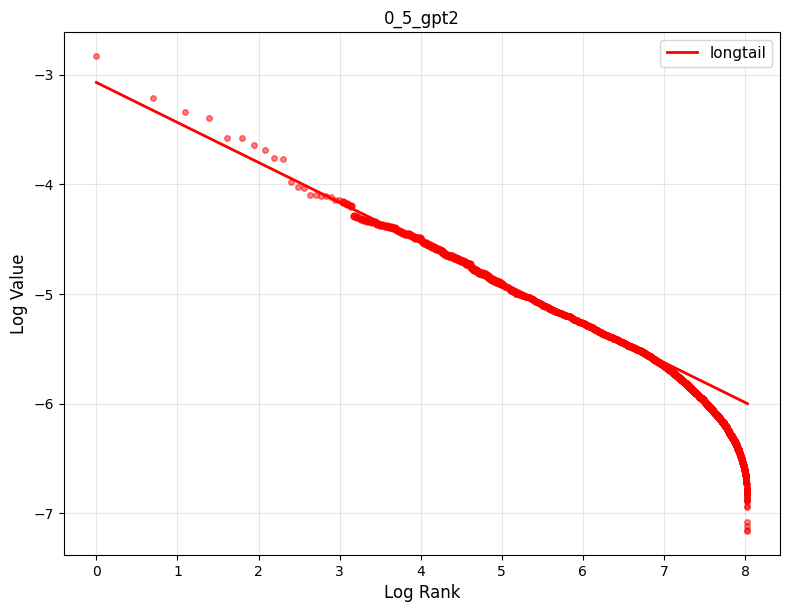

3072


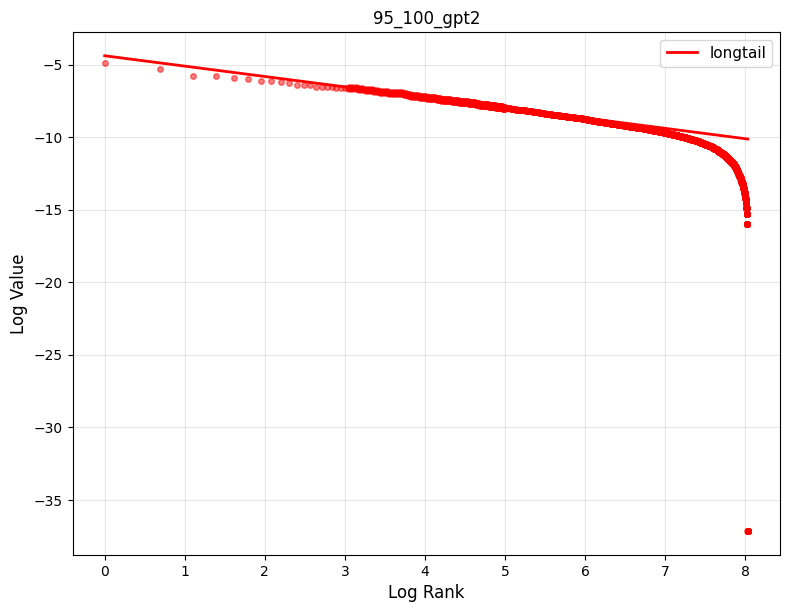

4096


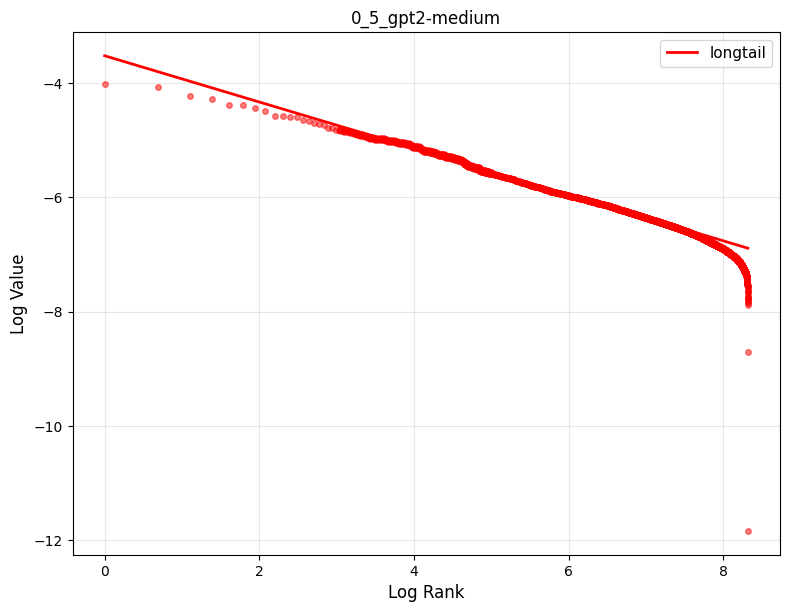

4096


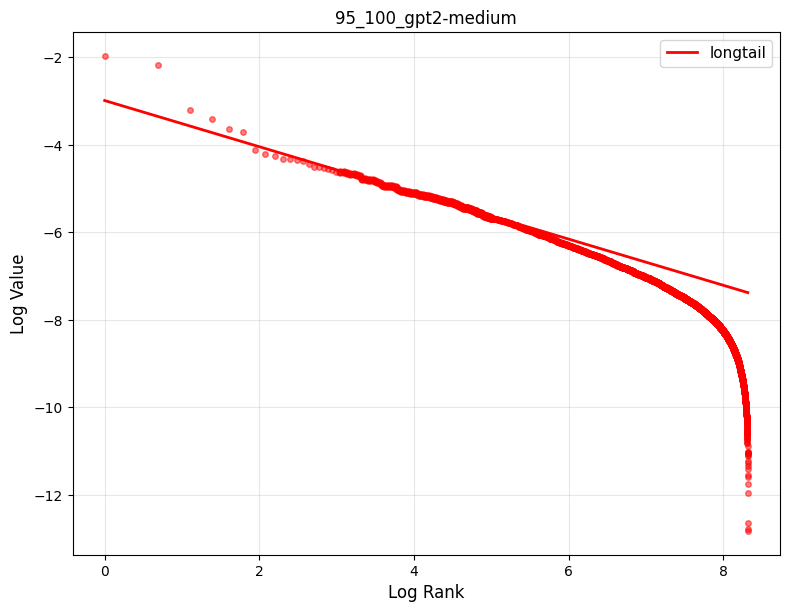

5120


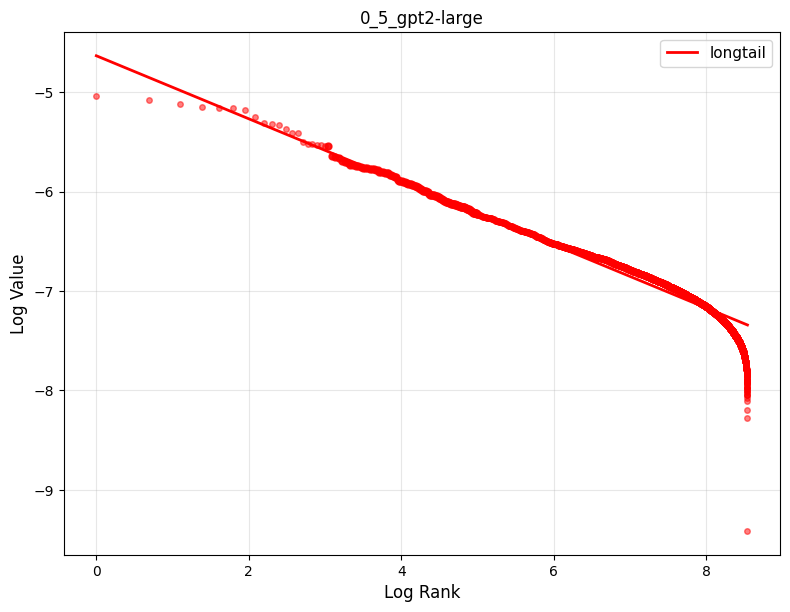

5120


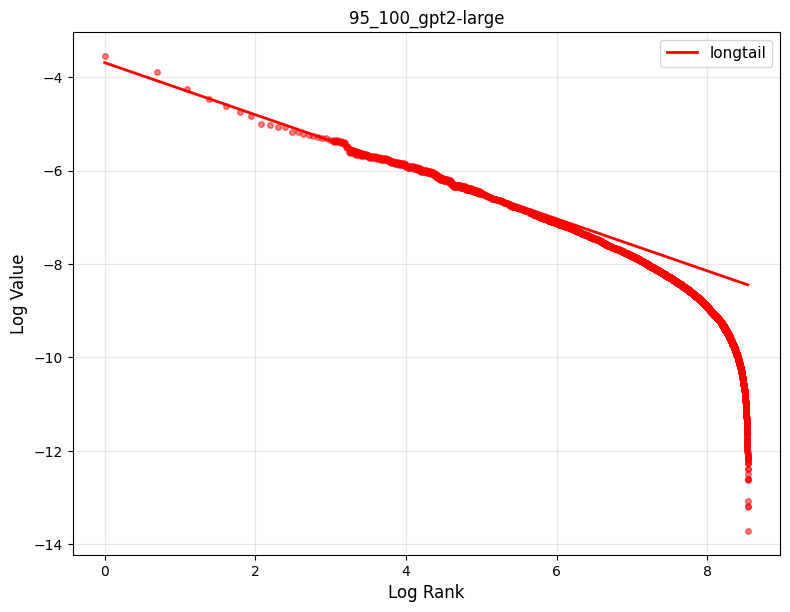

6400


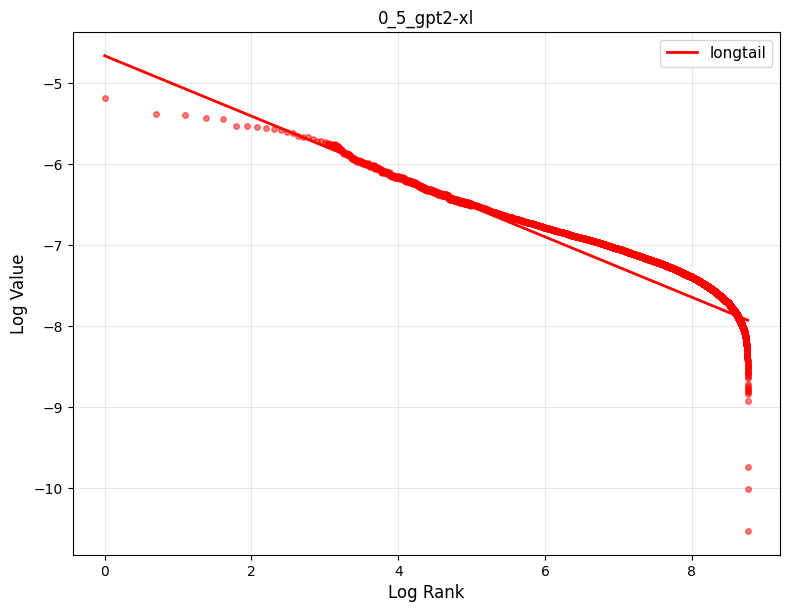

6400


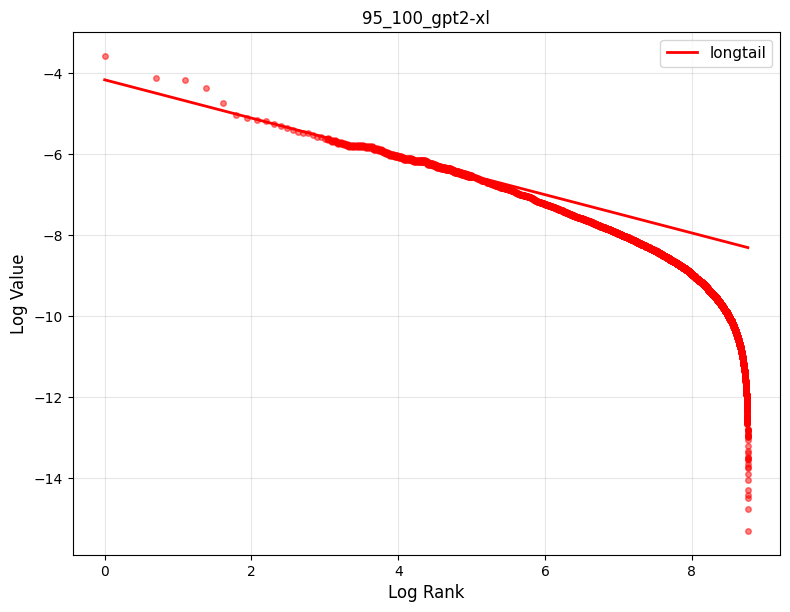

2048


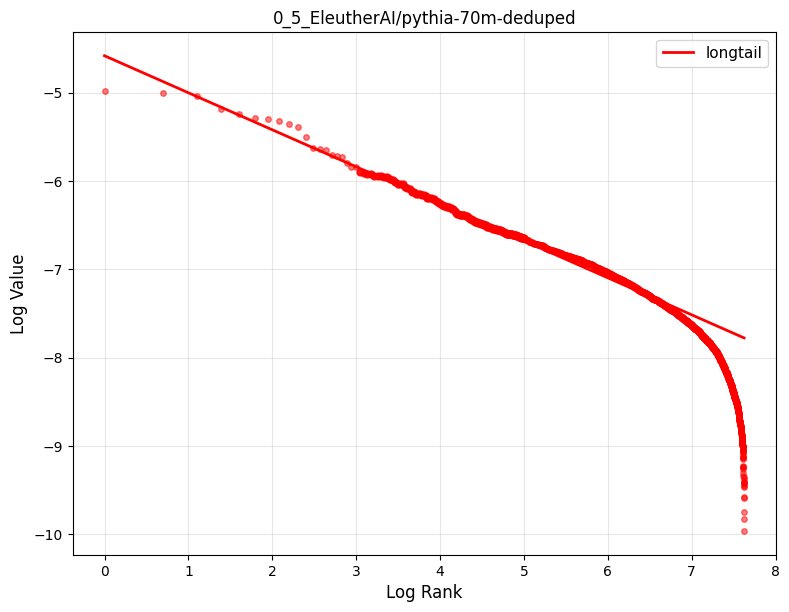

2048


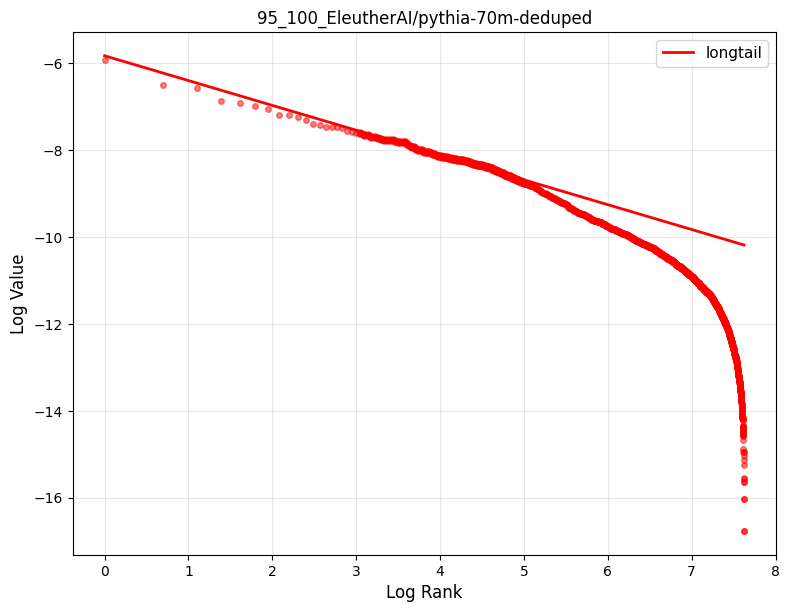

something wrong with 0
something wrong with 95
4096


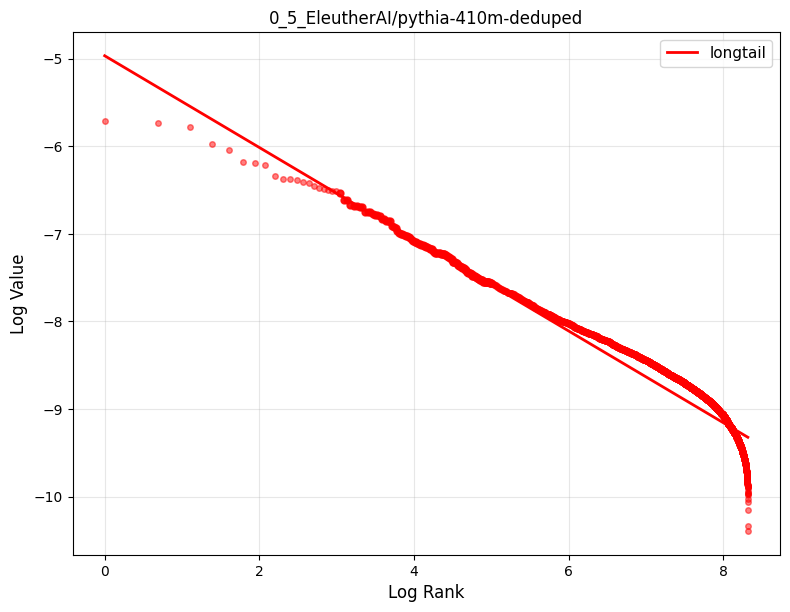

4089


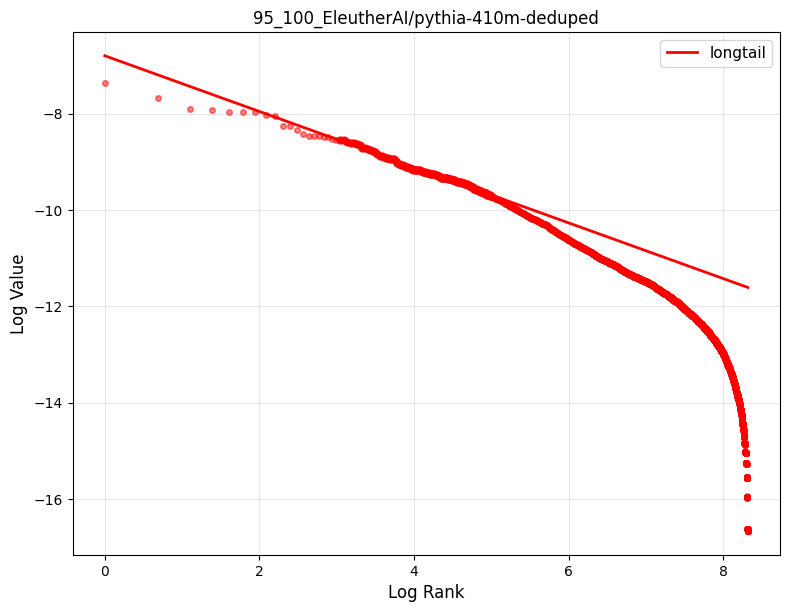

something wrong with 0
something wrong with 95
something wrong with 0
something wrong with 95
something wrong with 0
something wrong with 95
3072


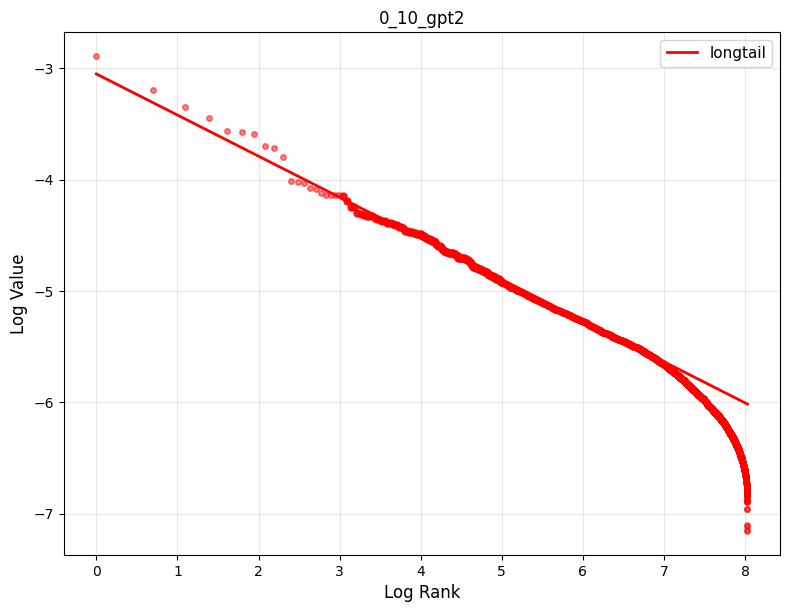

3072


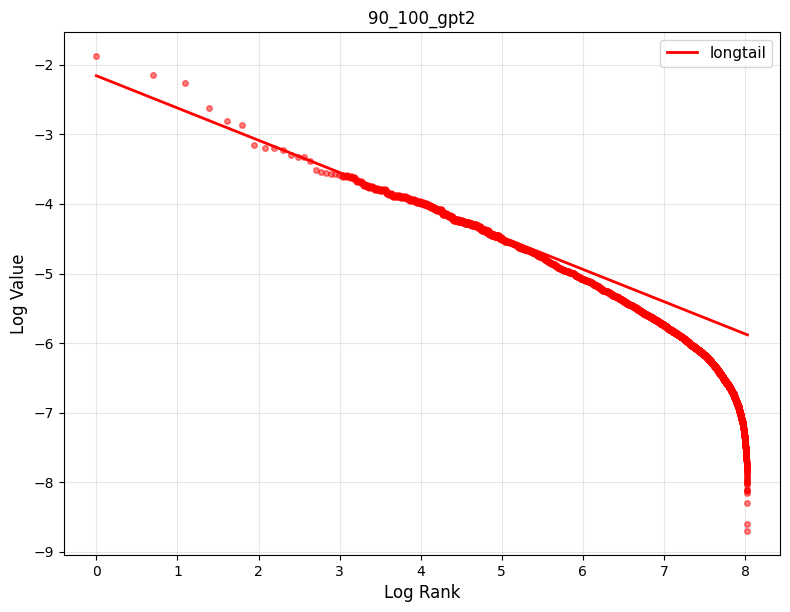

4096


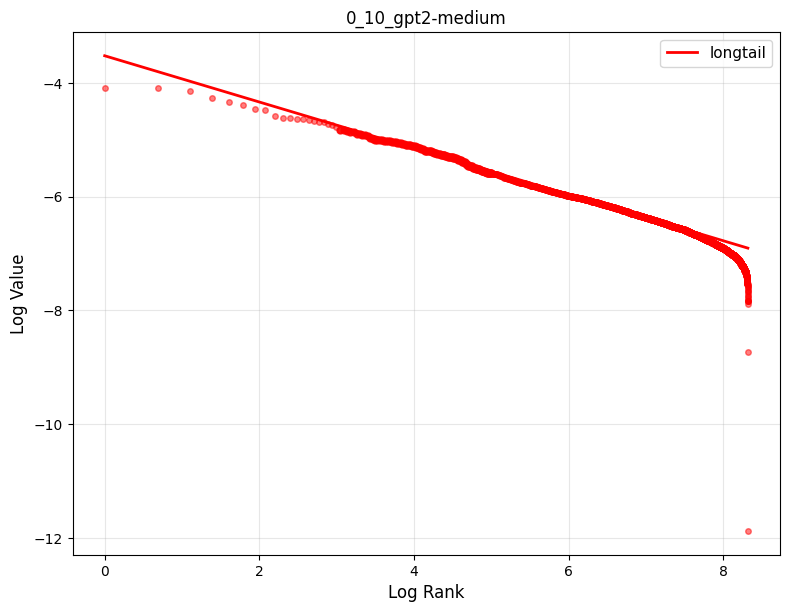

4096


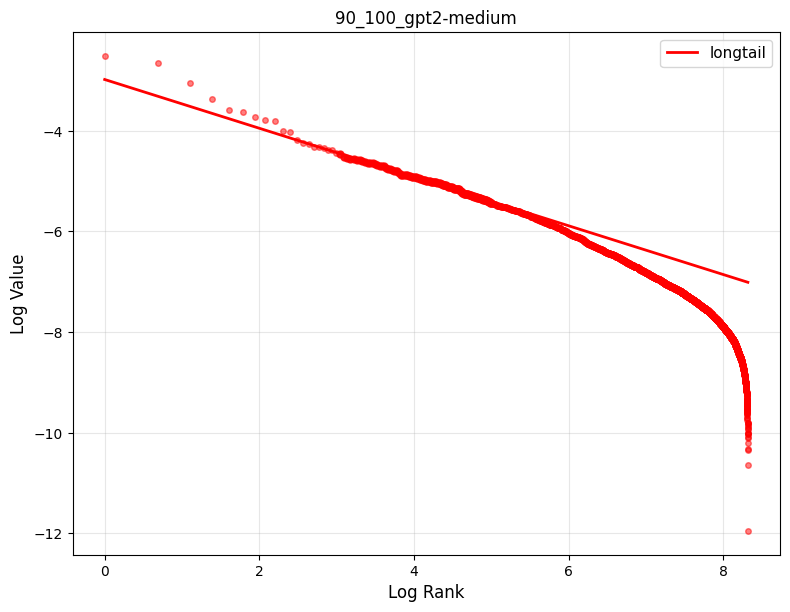

5120


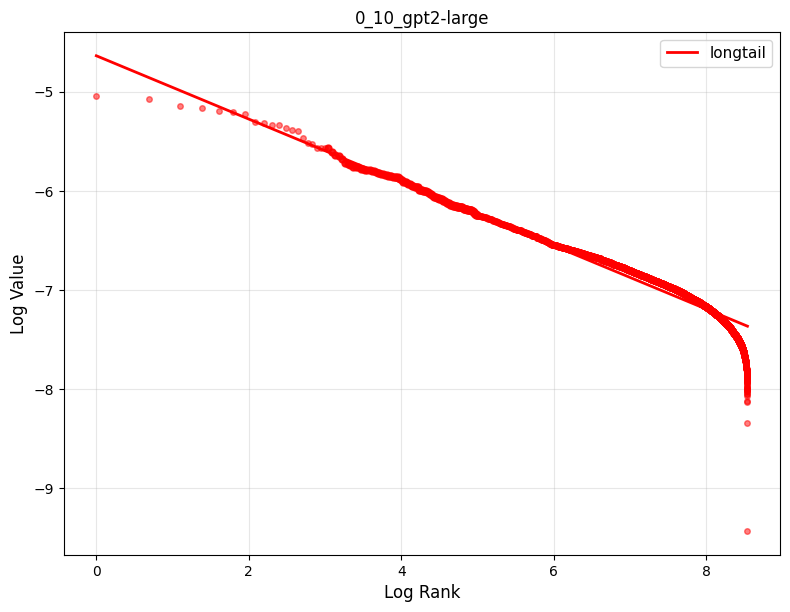

5120


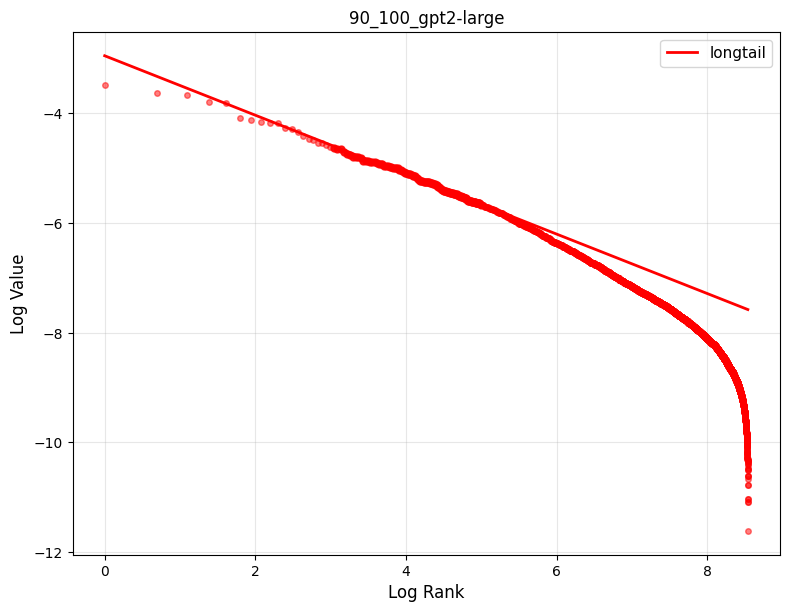

6400


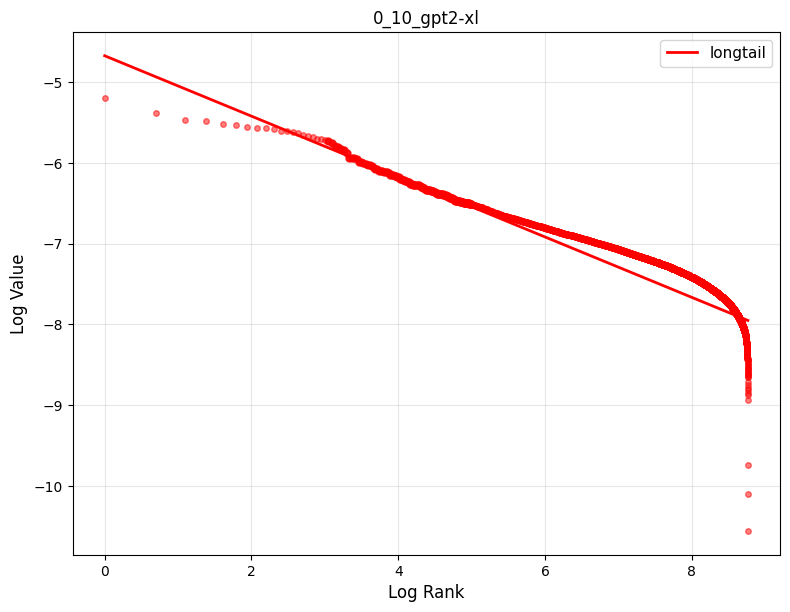

6400


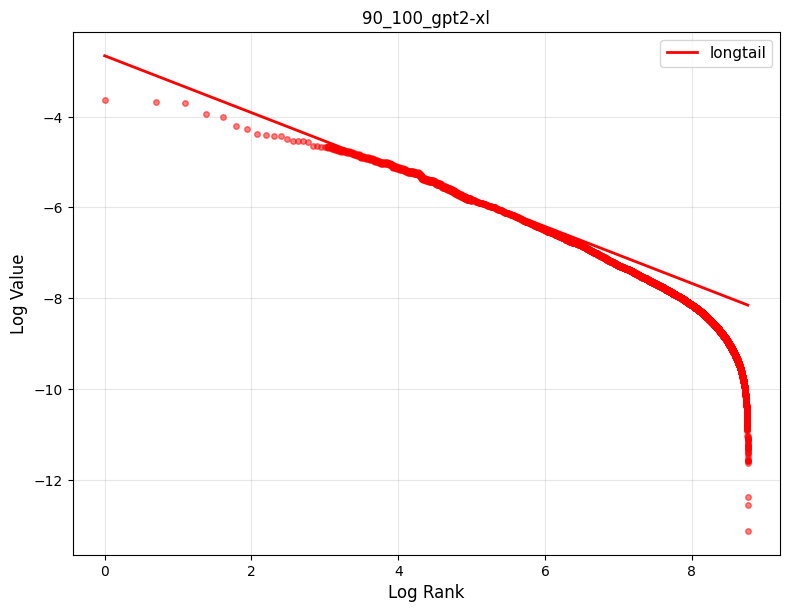

2048


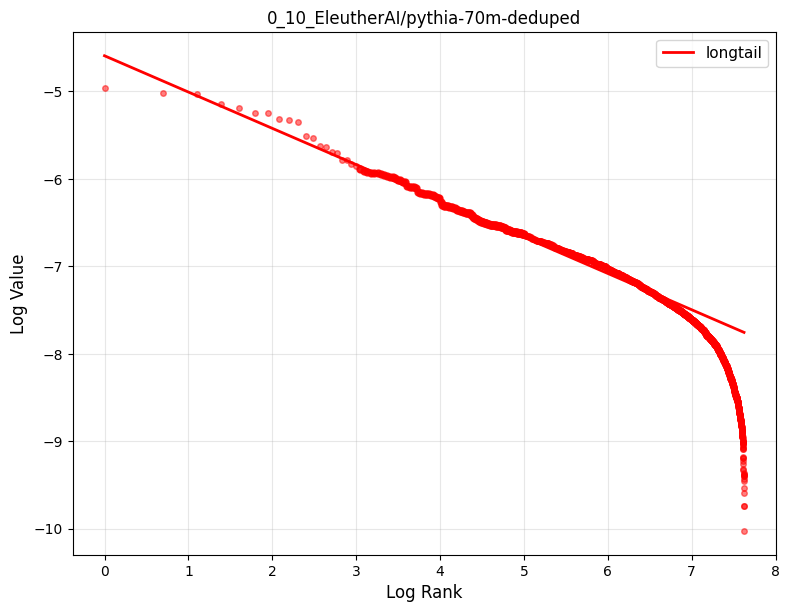

2048


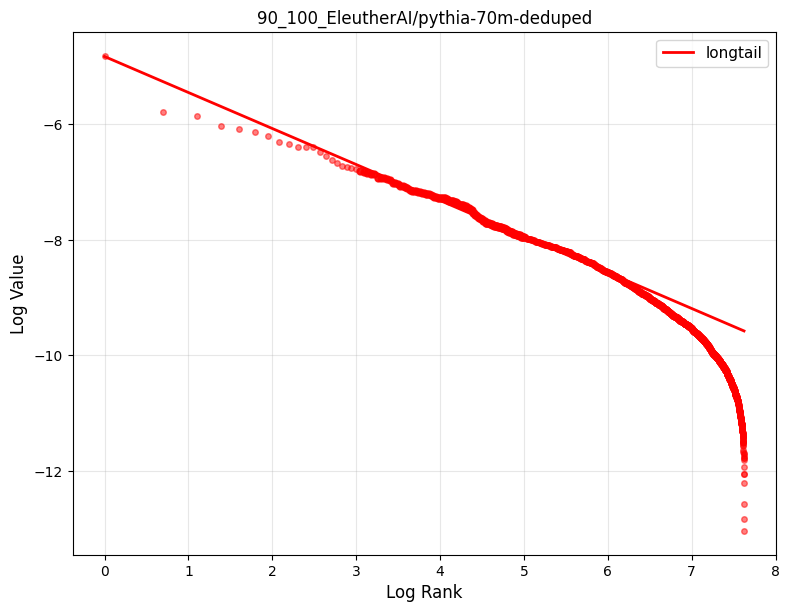

something wrong with 0
something wrong with 90
4096


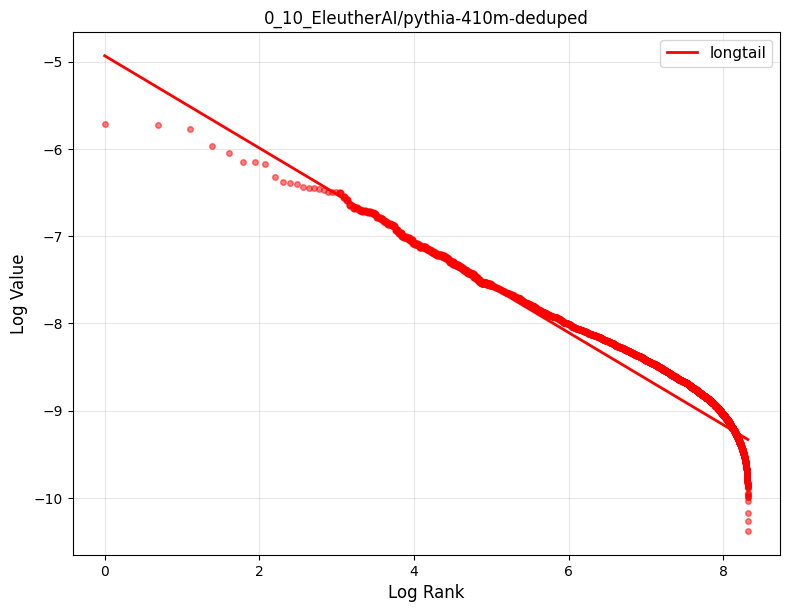

4096


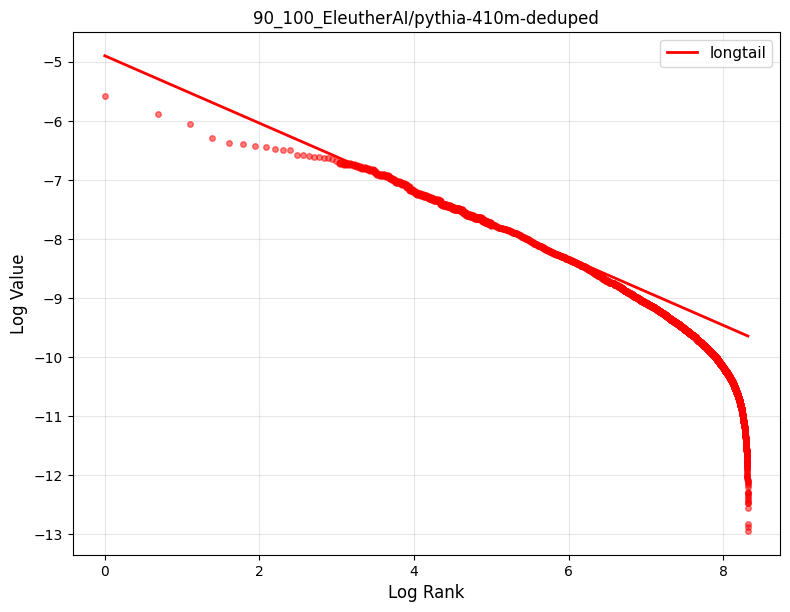

something wrong with 0
something wrong with 90
something wrong with 0
something wrong with 90
something wrong with 0
something wrong with 90
3072


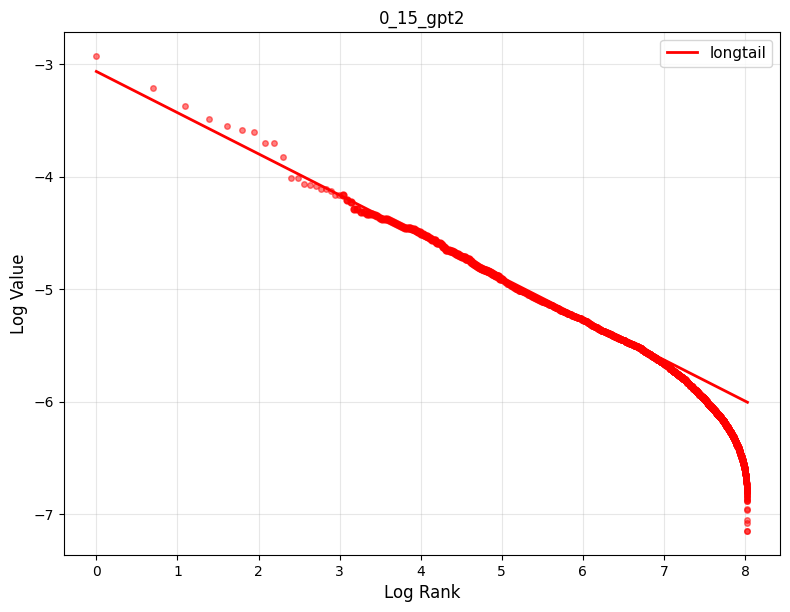

3072


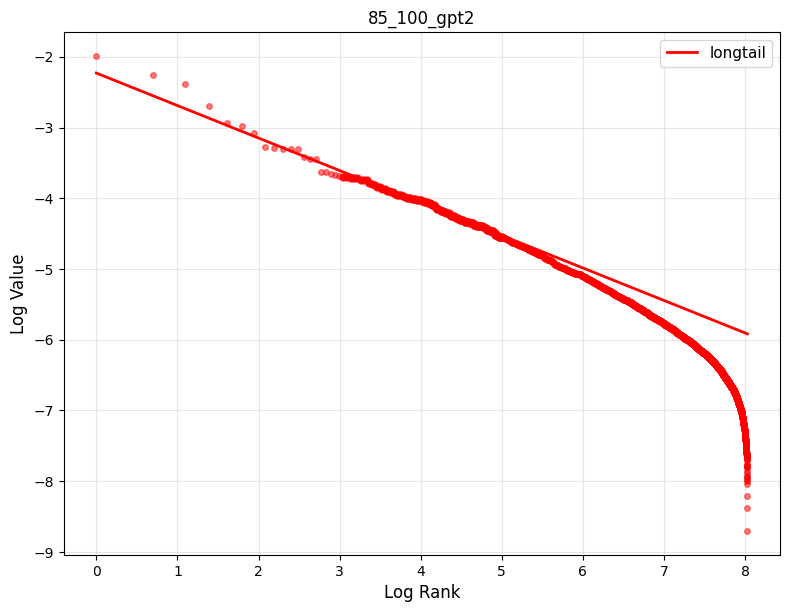

4096


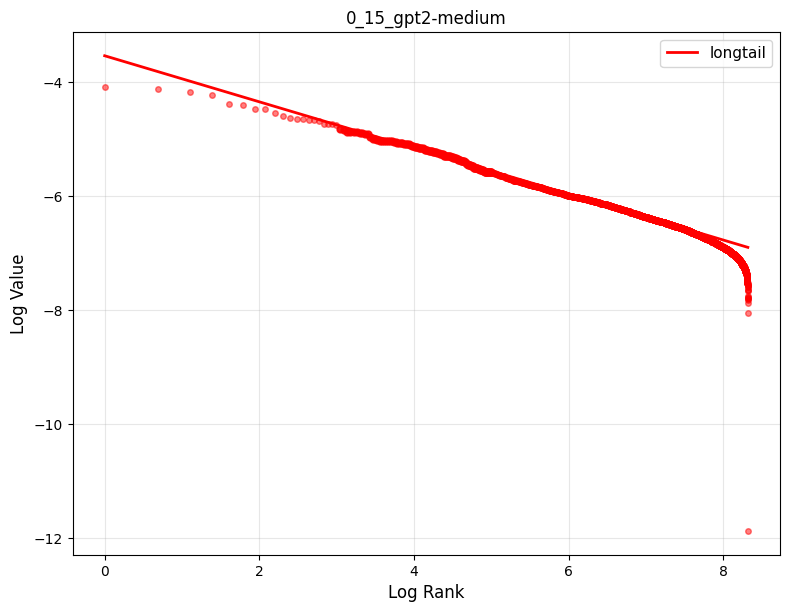

4096


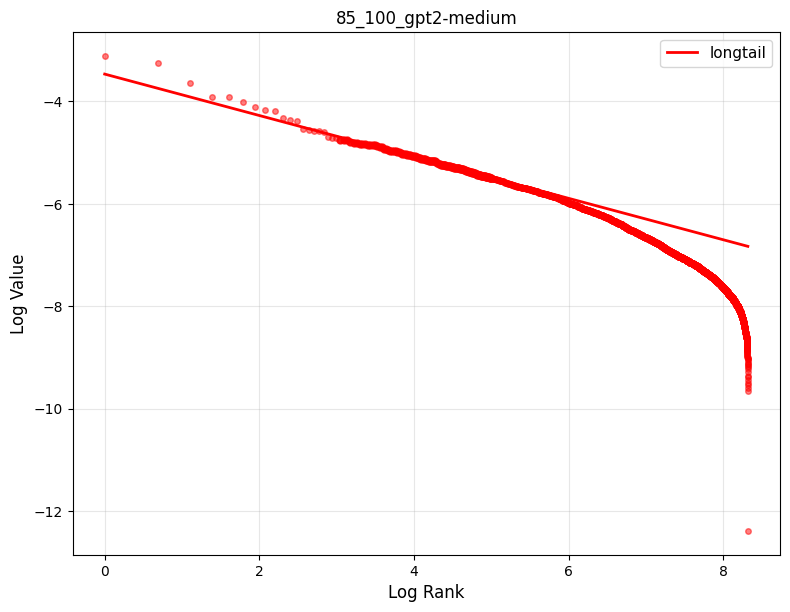

5120


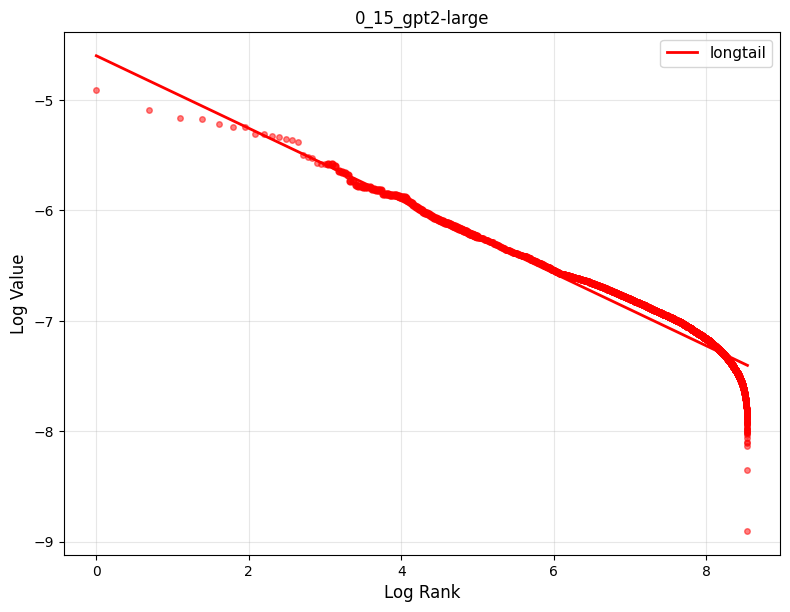

5120


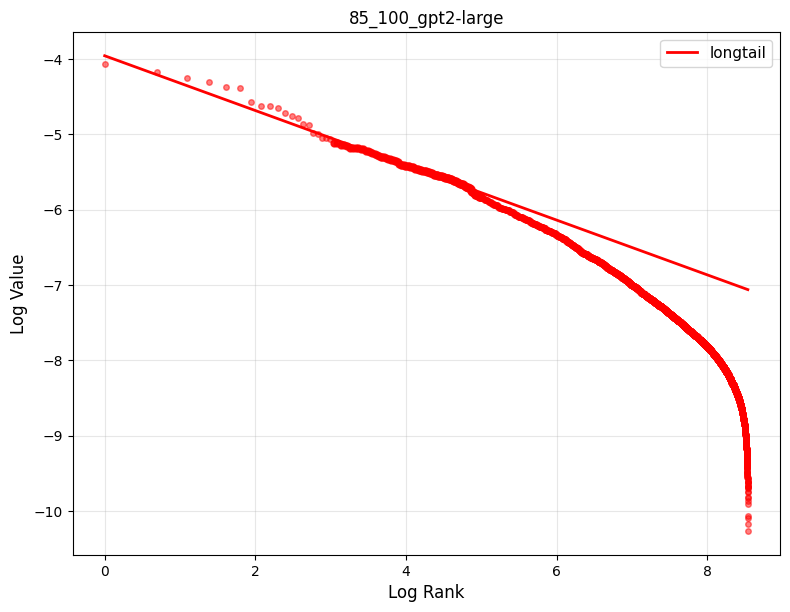

6400


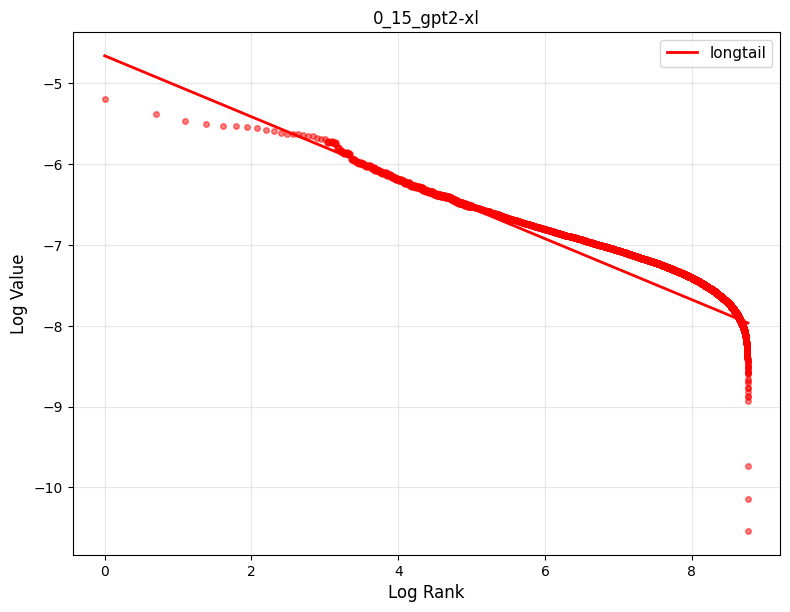

6400


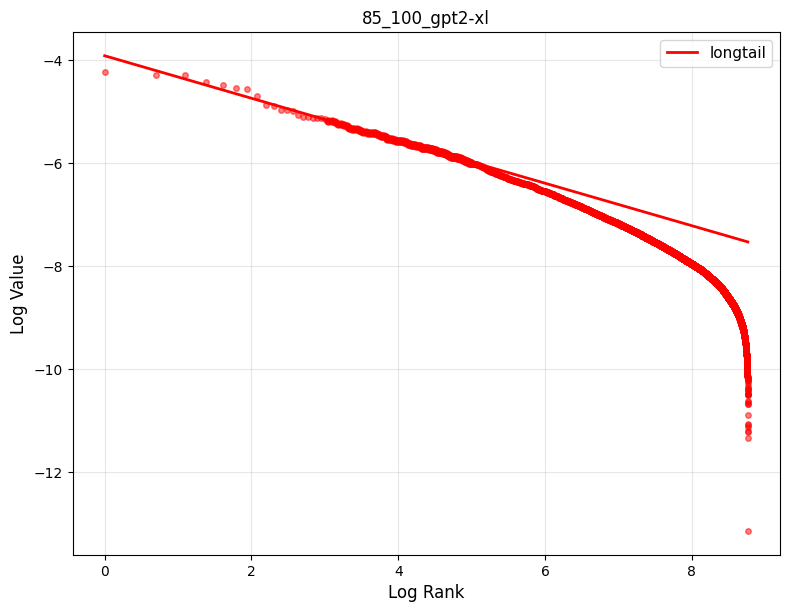

2048


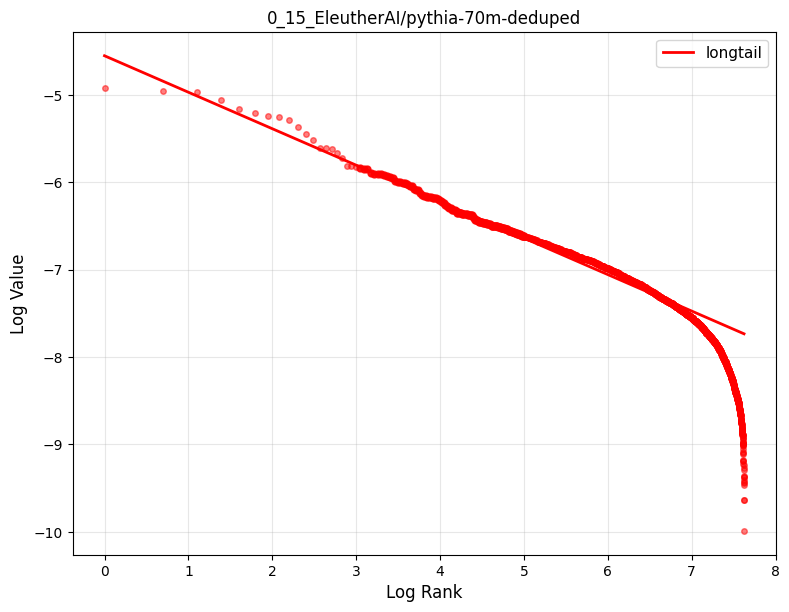

2048


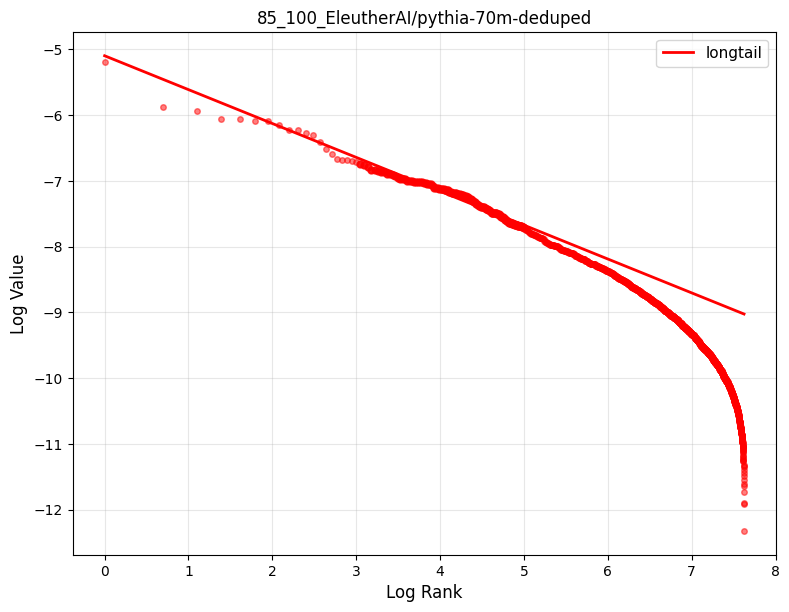

something wrong with 0
something wrong with 85
4096


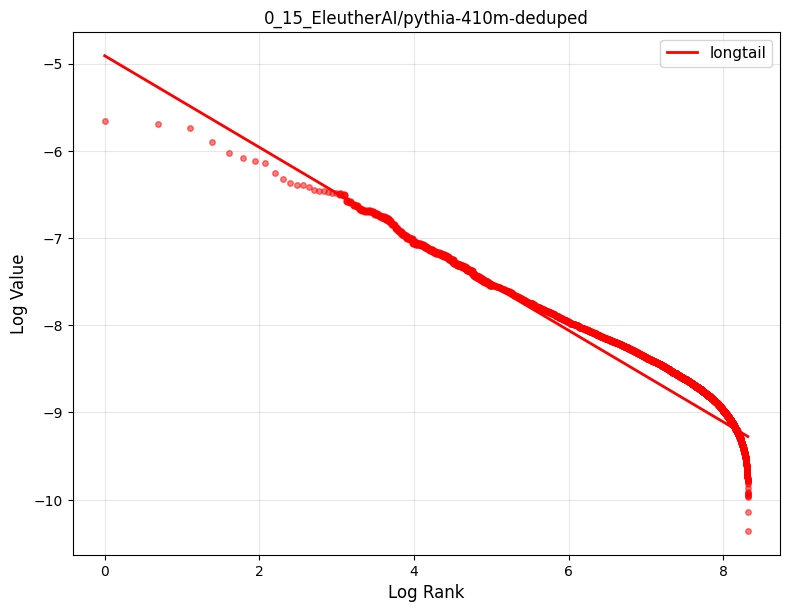

4096


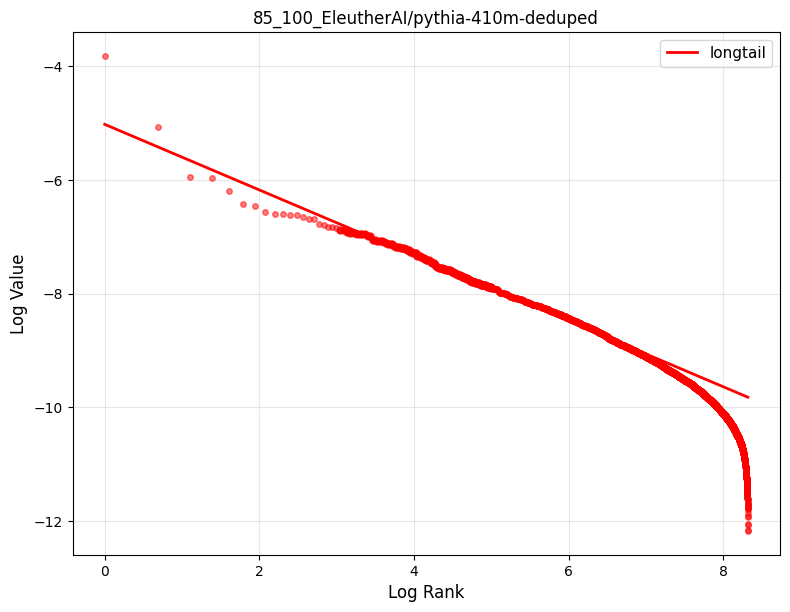

something wrong with 0
something wrong with 85
something wrong with 0
something wrong with 85
something wrong with 0
something wrong with 85
3072


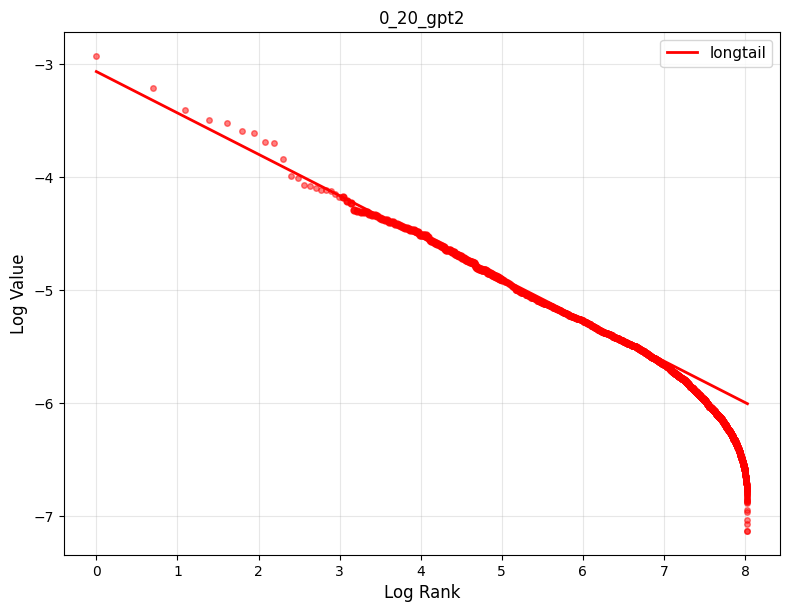

3072


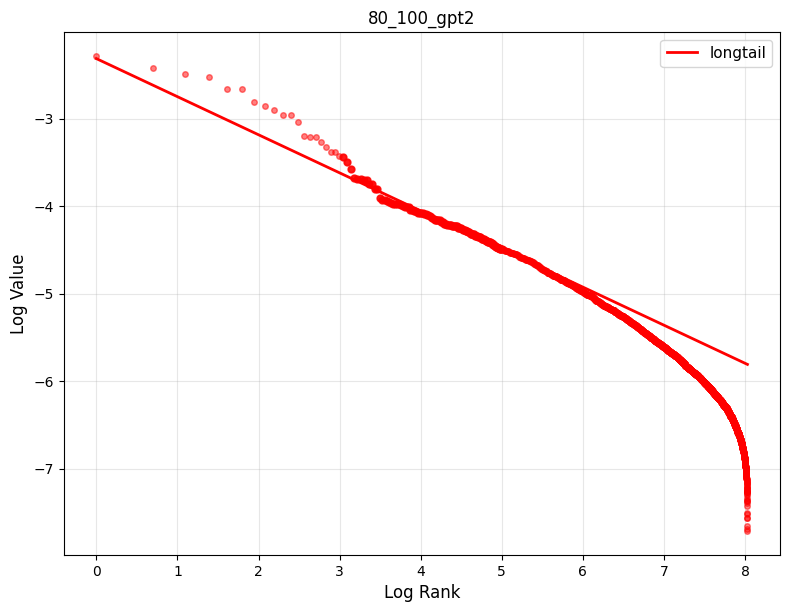

4096


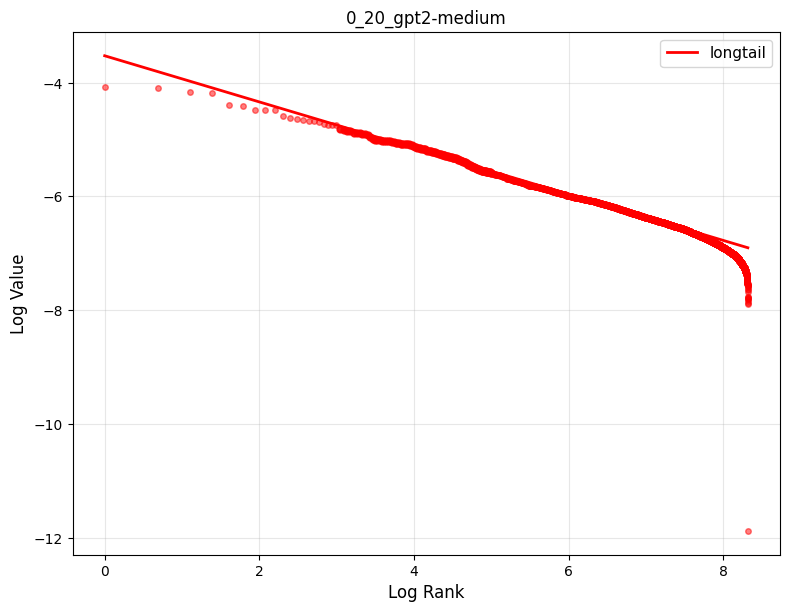

4096


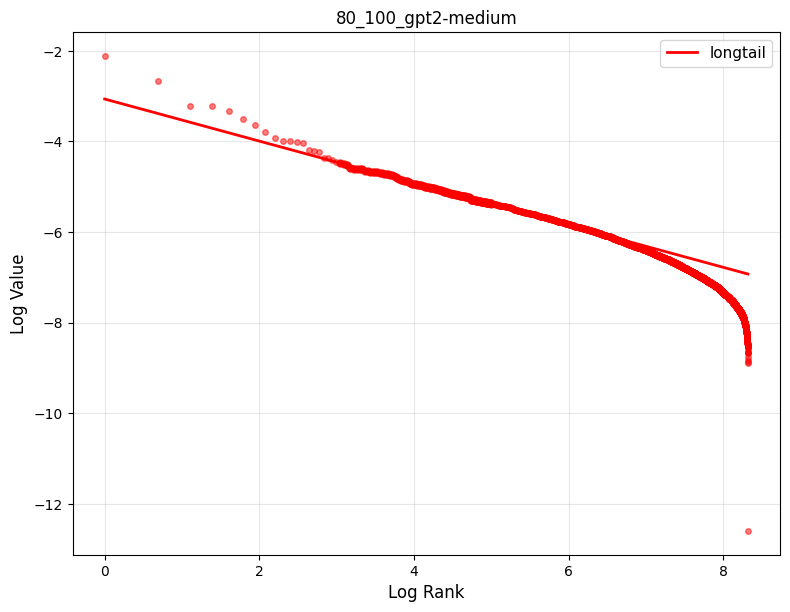

5120


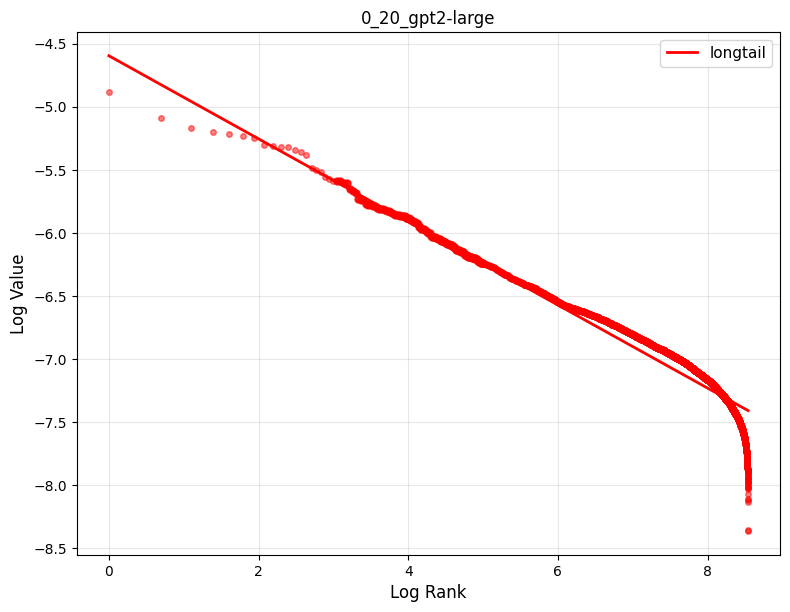

5120


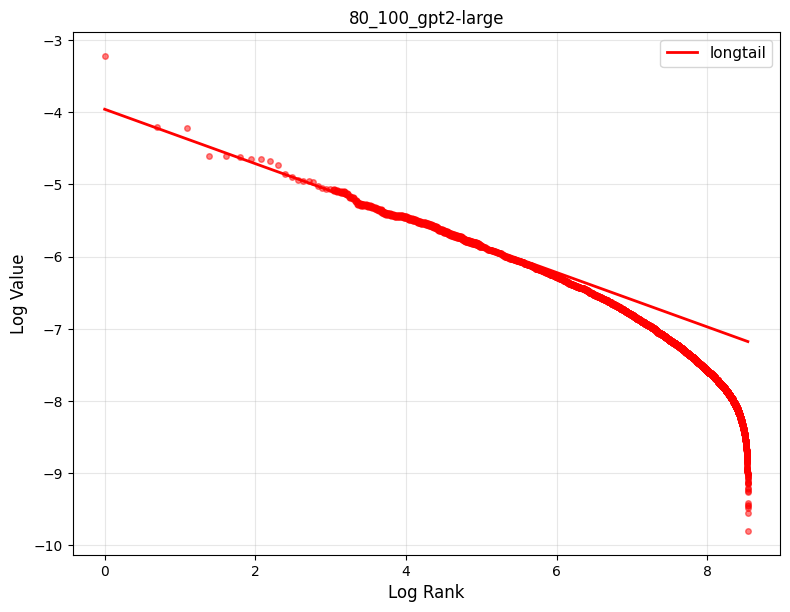

6400


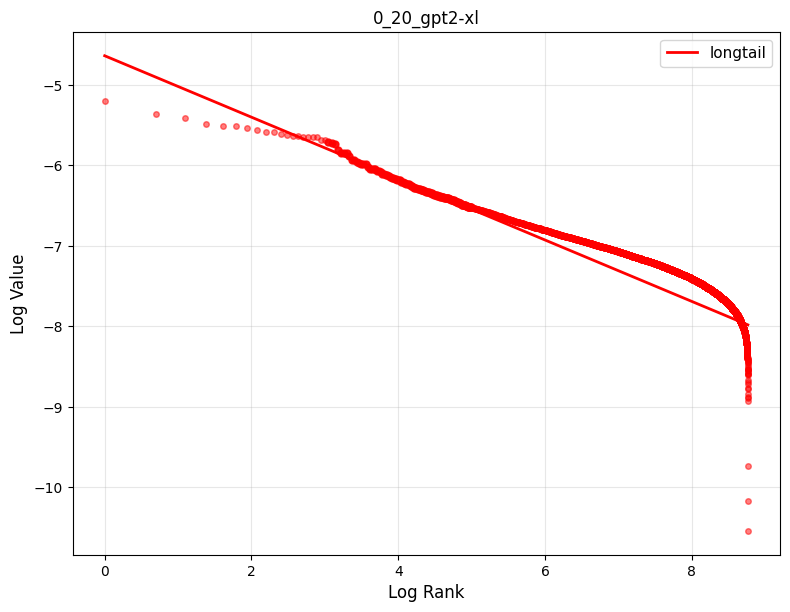

6400


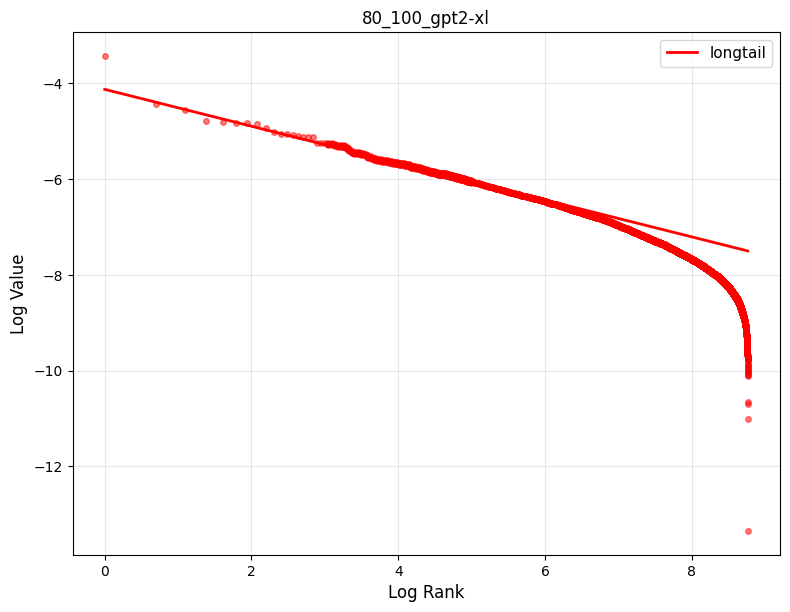

2048


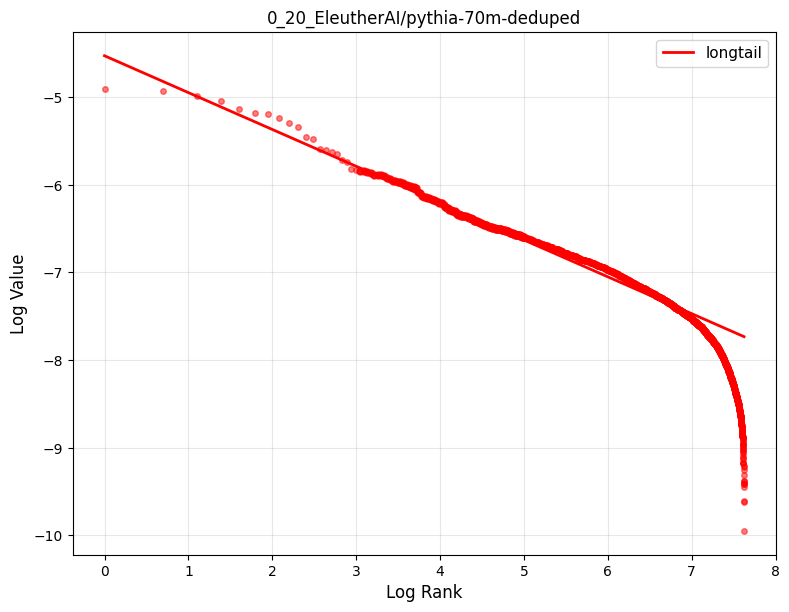

2048


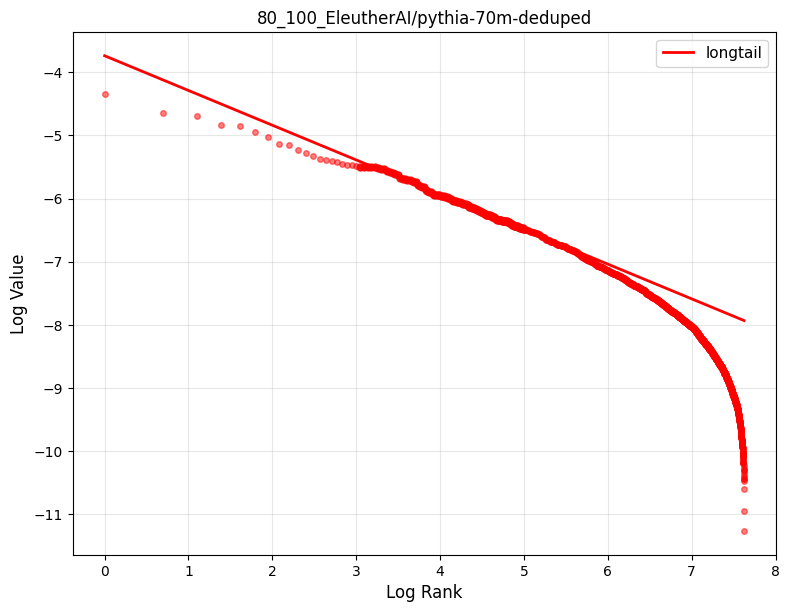

something wrong with 0
something wrong with 80
4096


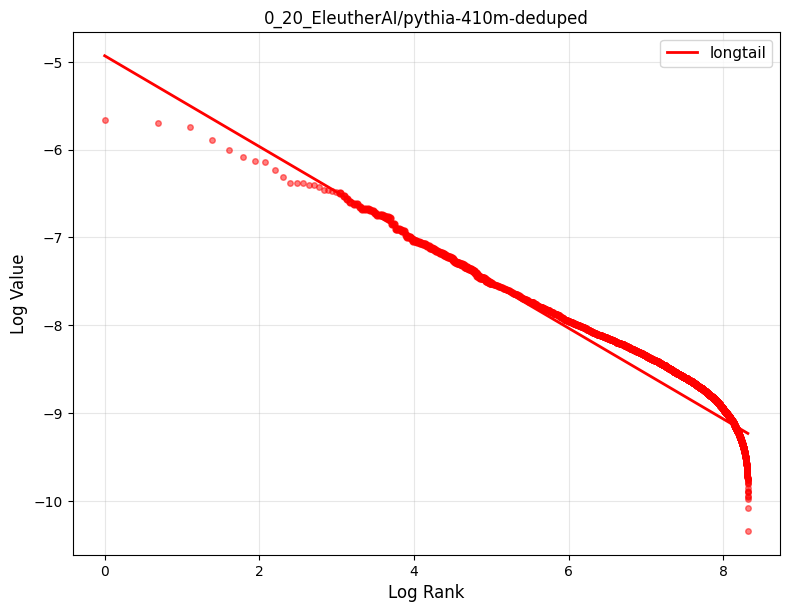

4096


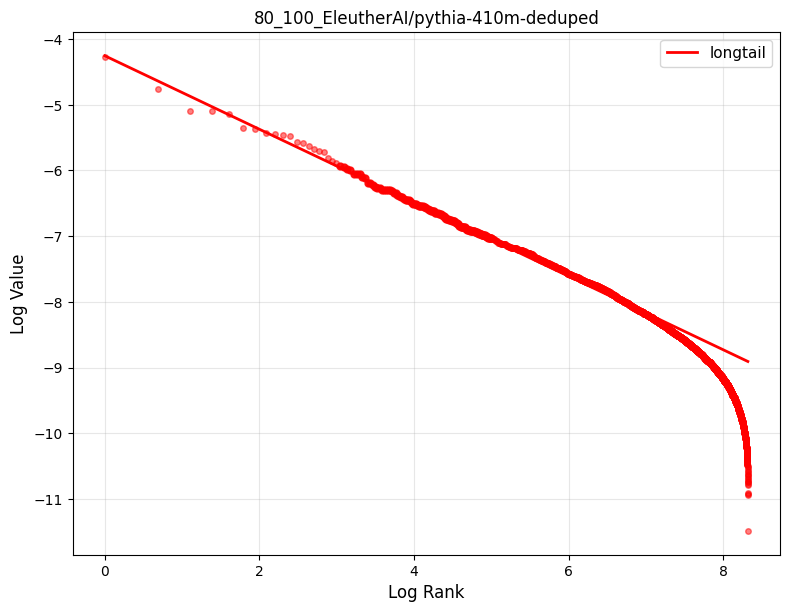

something wrong with 0
something wrong with 80
something wrong with 0
something wrong with 80
something wrong with 0
something wrong with 80
3072


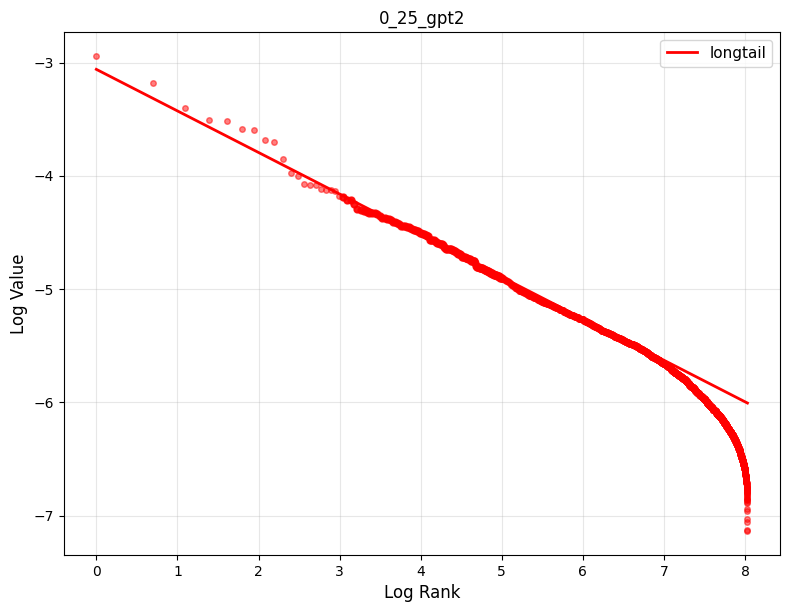

3072


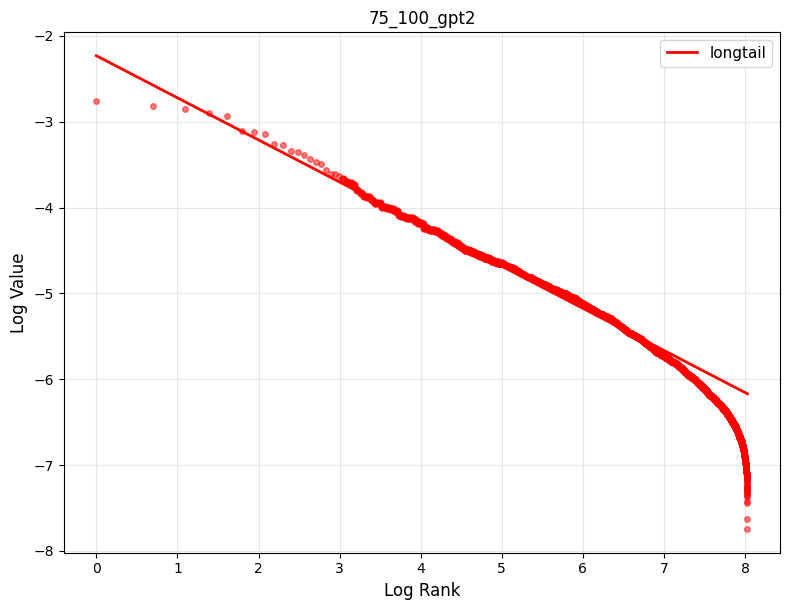

4096


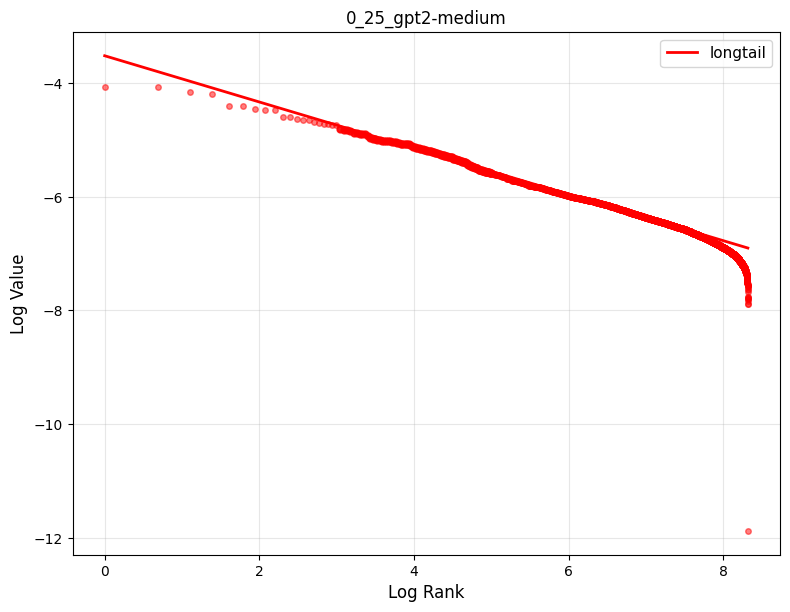

4096


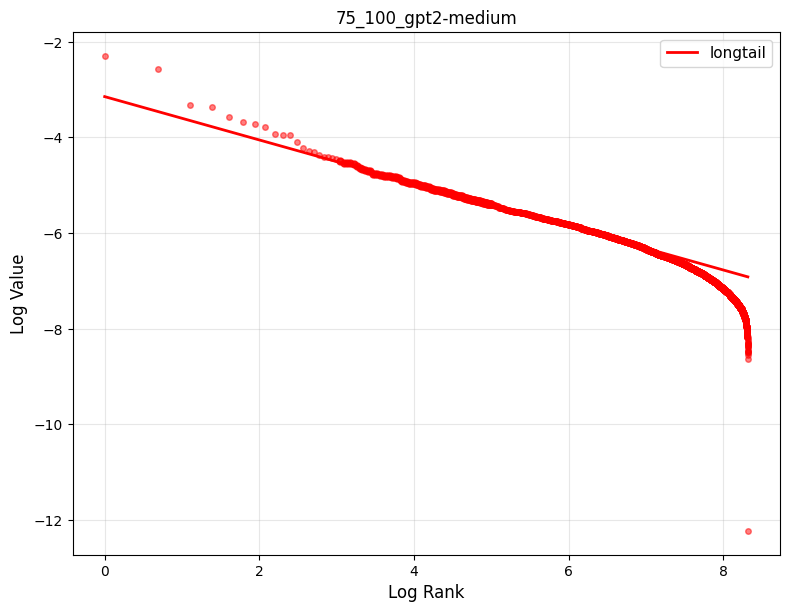

5120


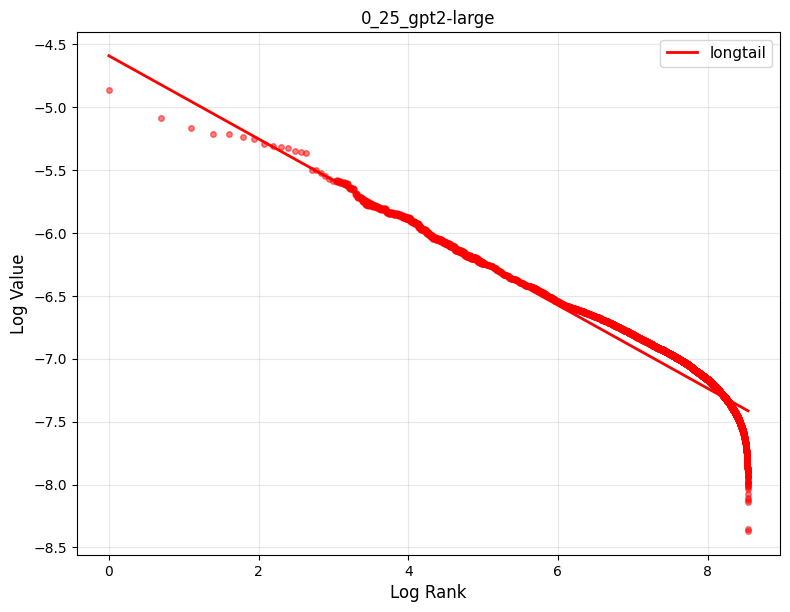

5120


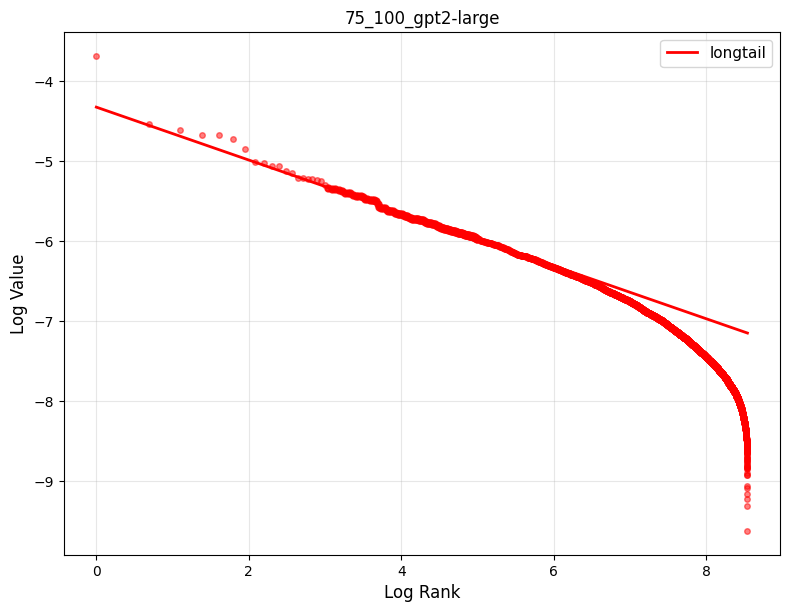

6400


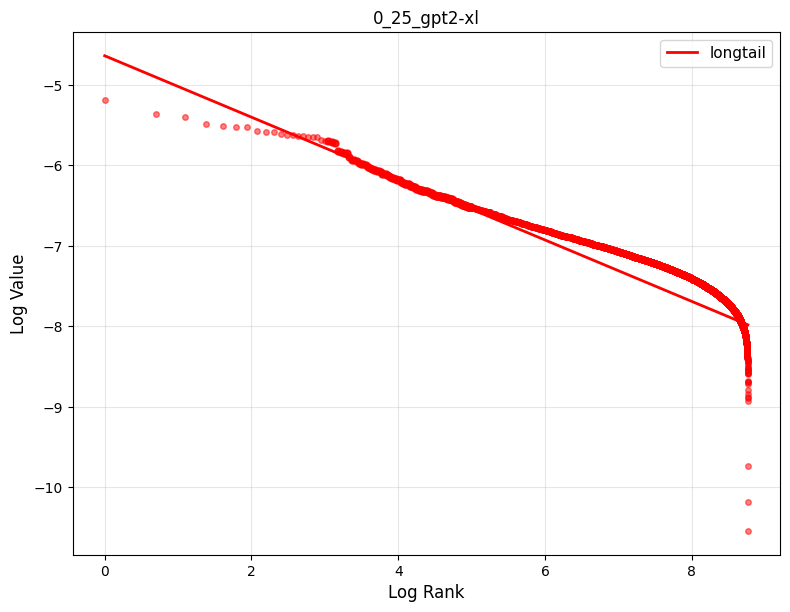

6400


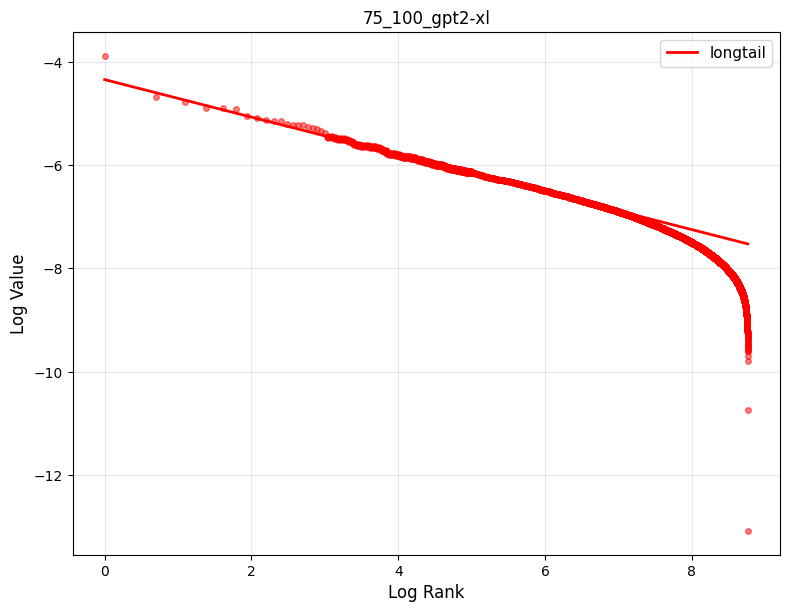

2048


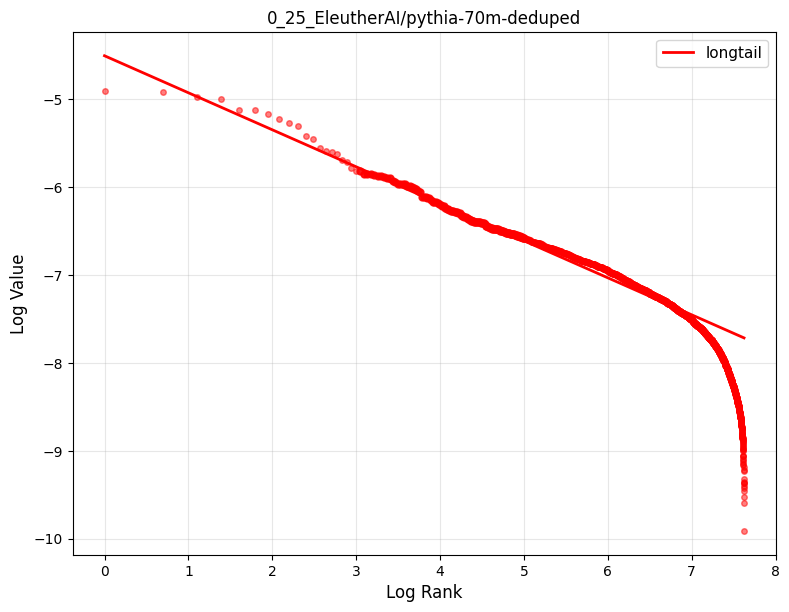

2048


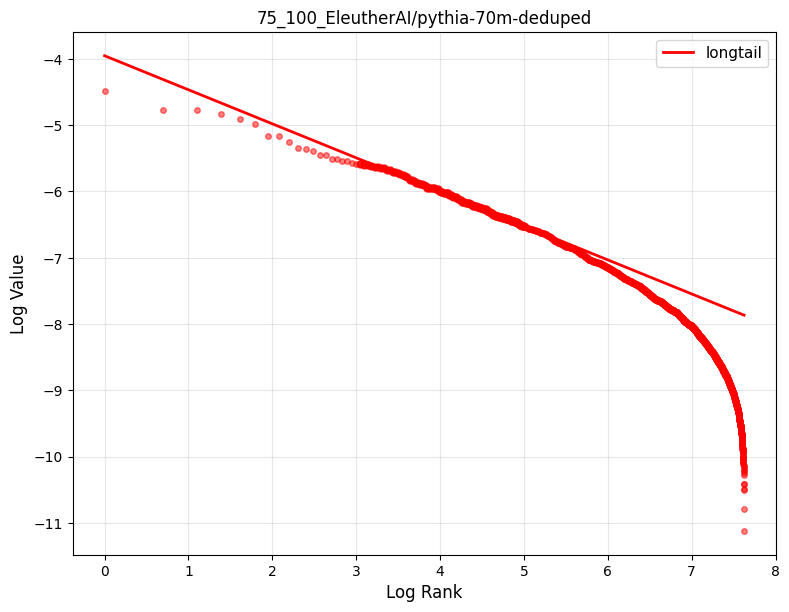

something wrong with 0
something wrong with 75
4096


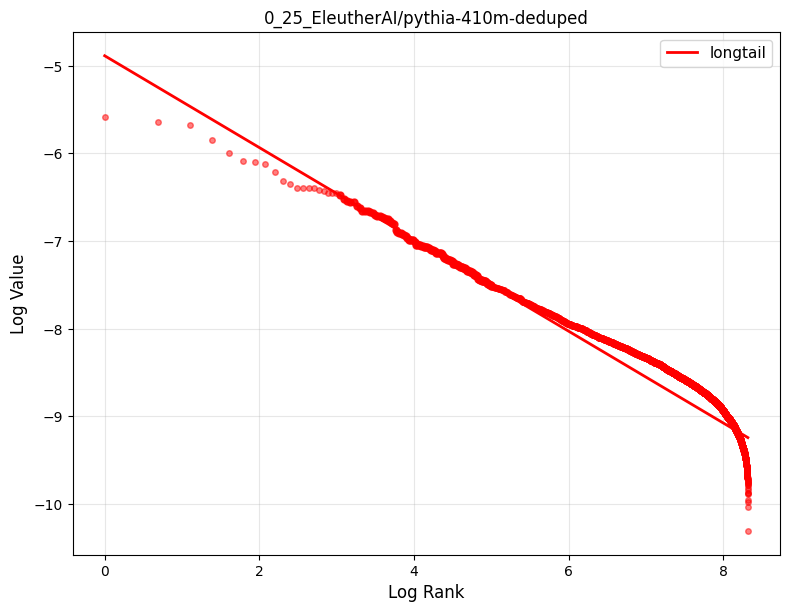

4096


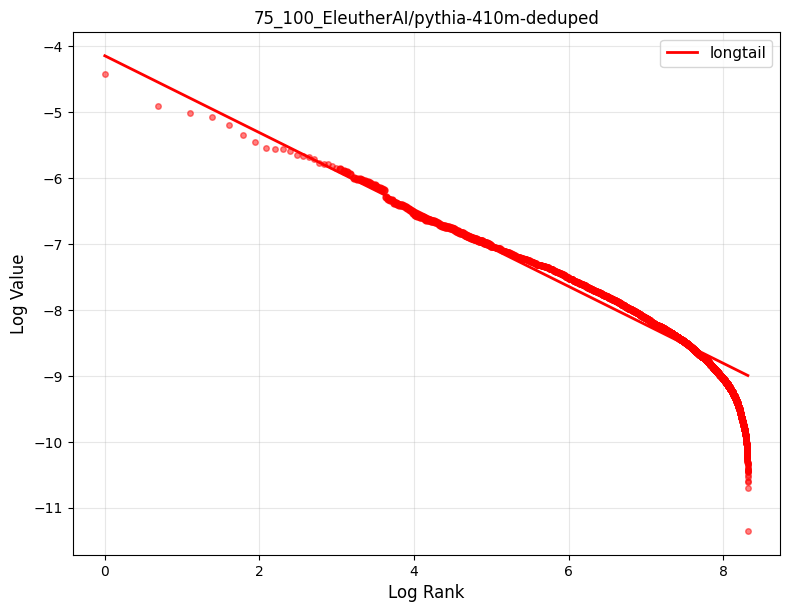

something wrong with 0
something wrong with 75
something wrong with 0
something wrong with 75
something wrong with 0
something wrong with 75
3072


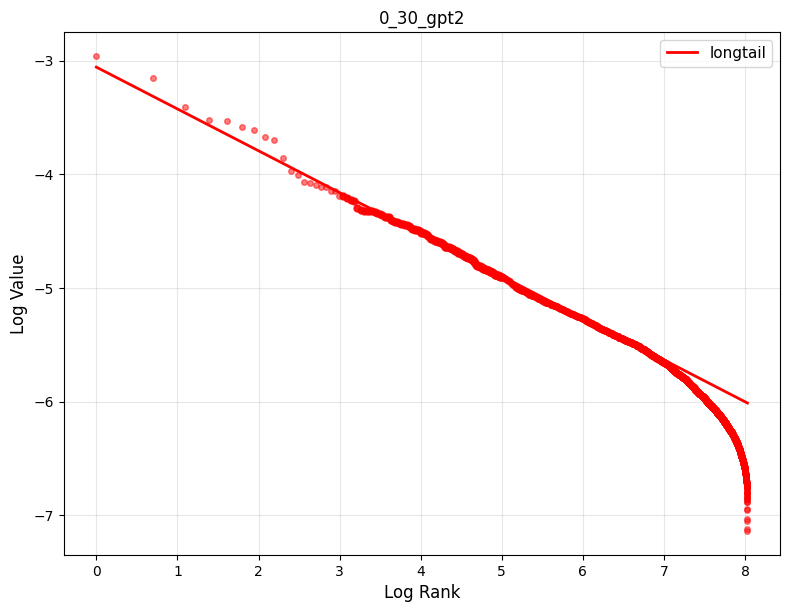

3072


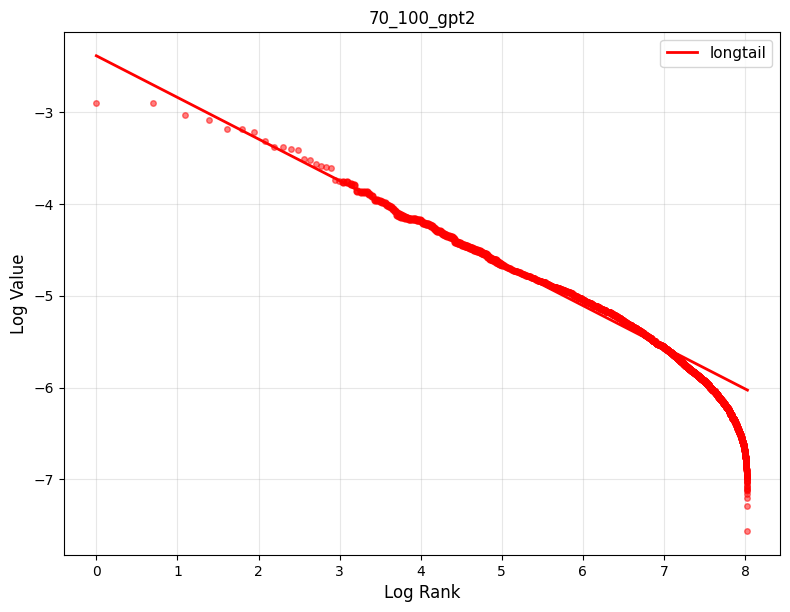

4096


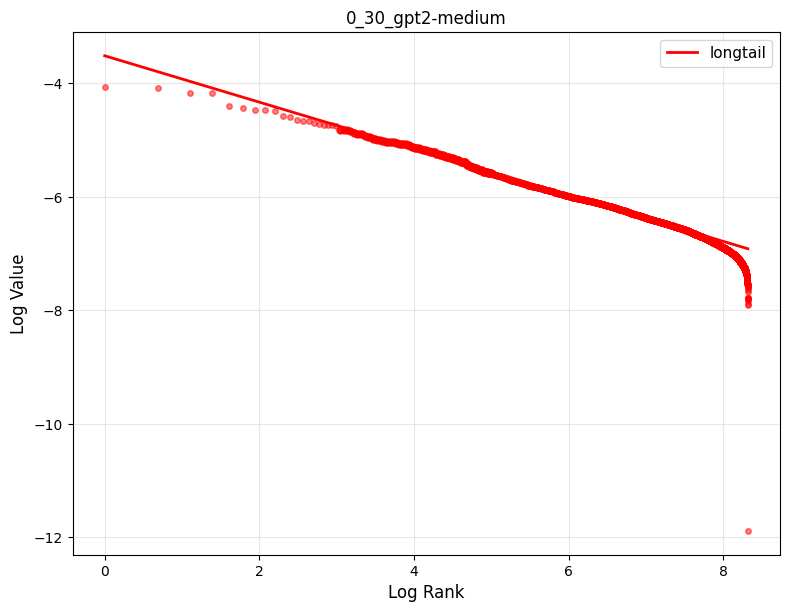

4096


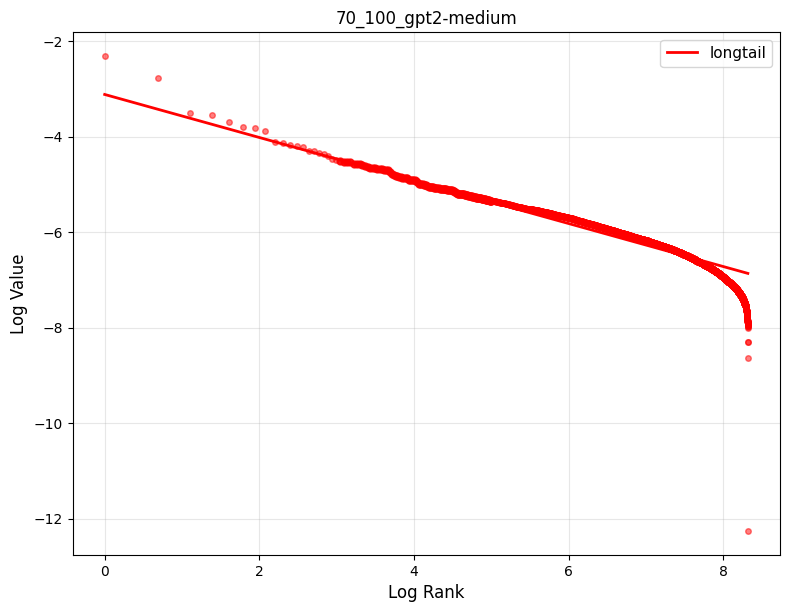

5120


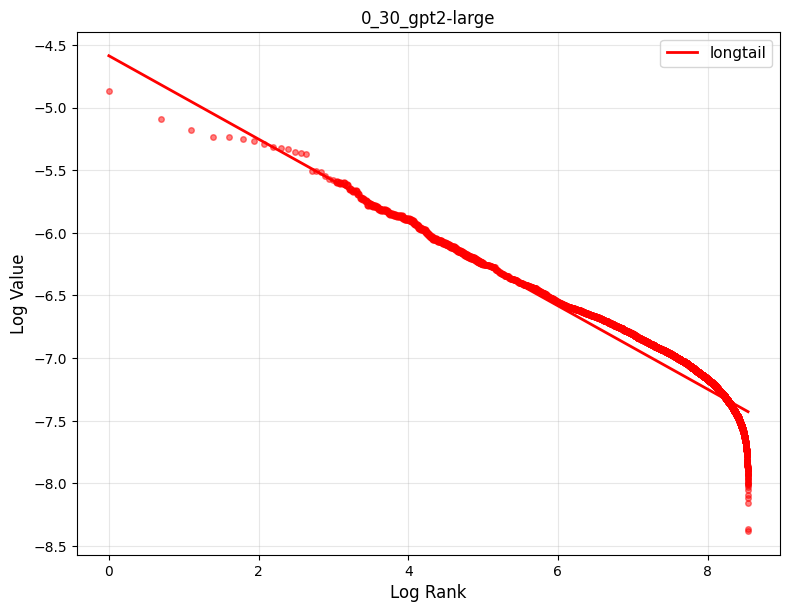

5120


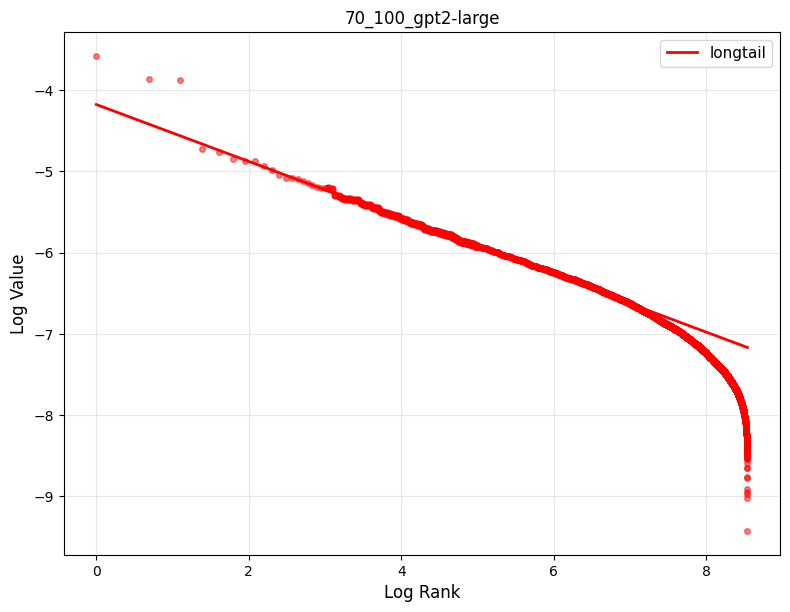

6400


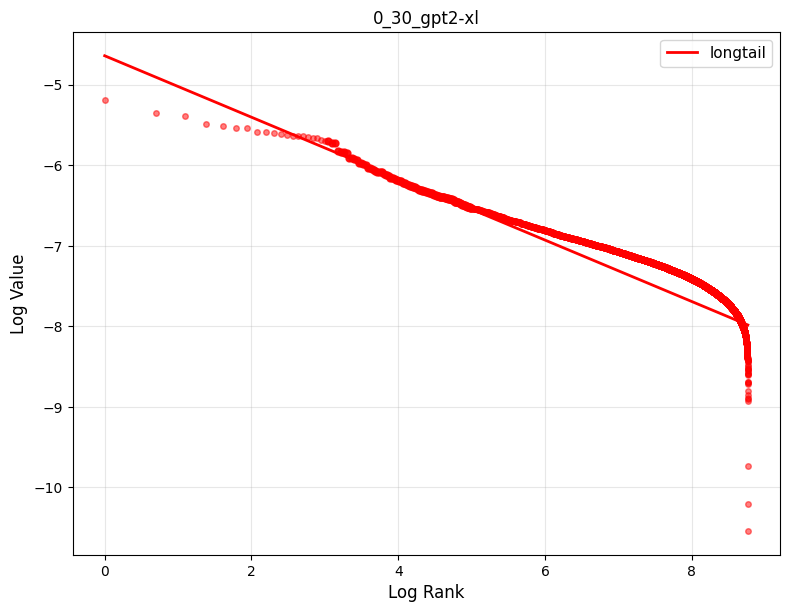

6400


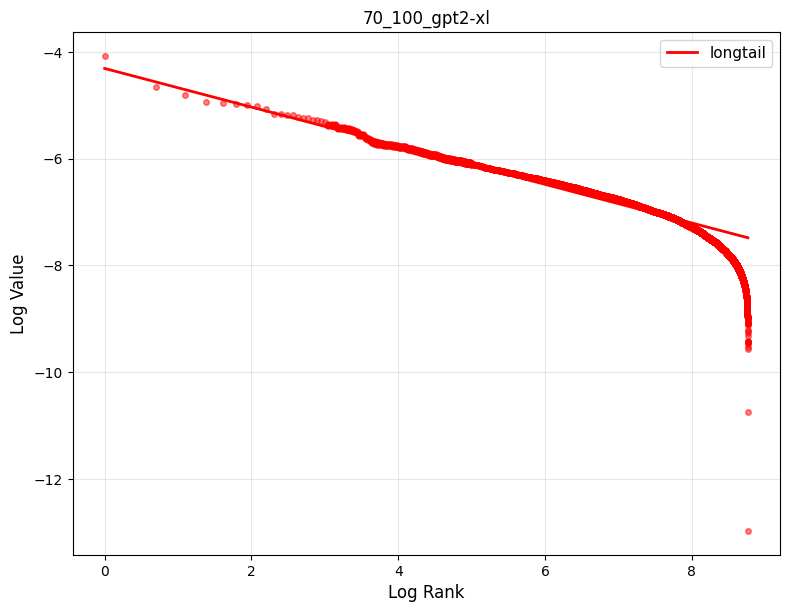

2048


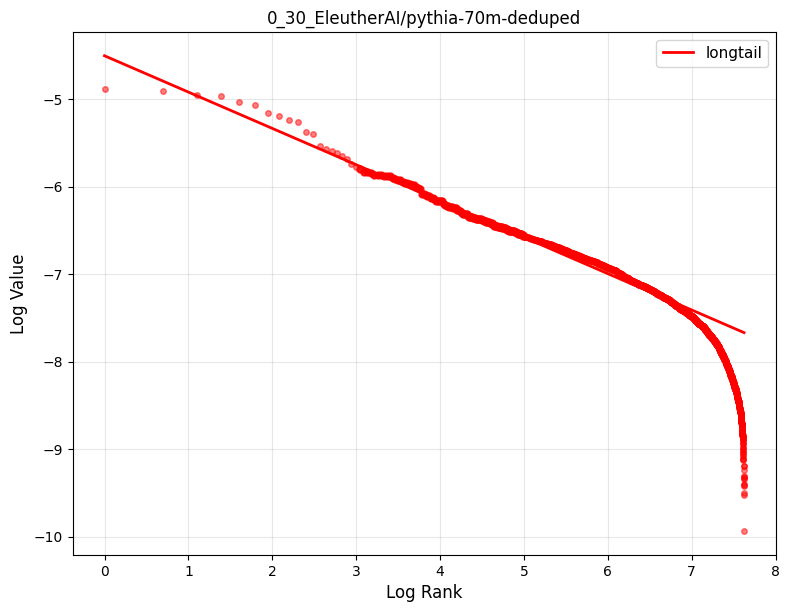

2048


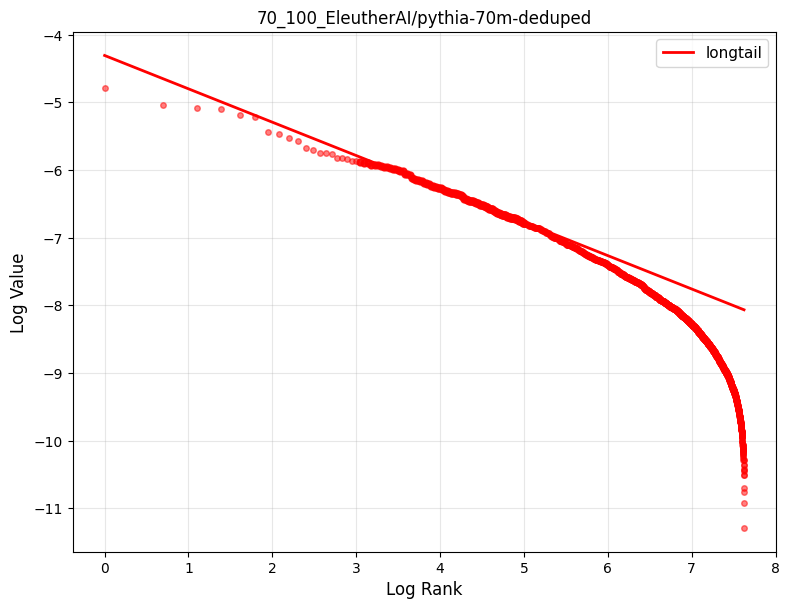

something wrong with 0
something wrong with 70
4096


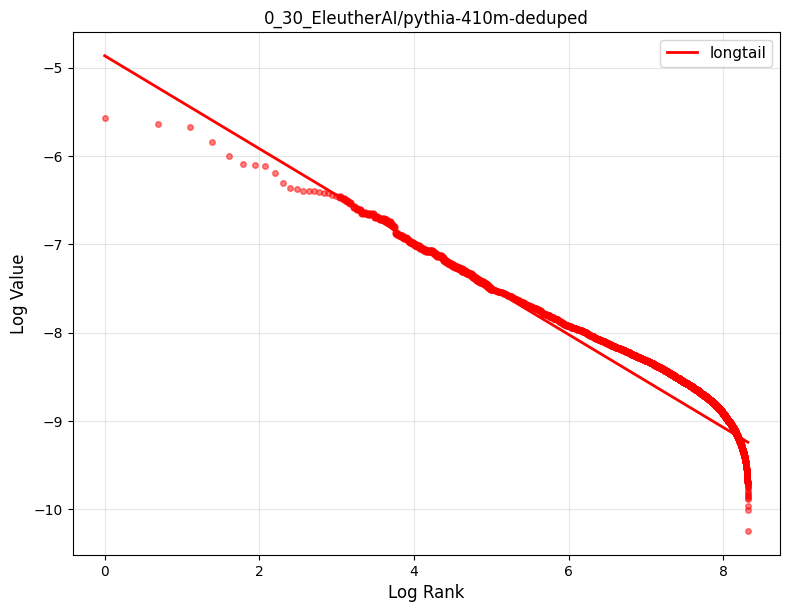

4096


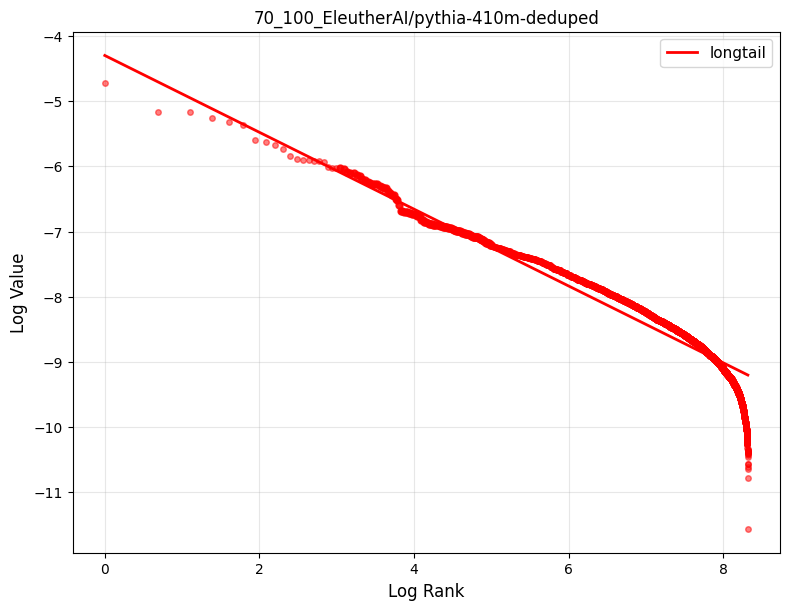

something wrong with 0
something wrong with 70
something wrong with 0
something wrong with 70
something wrong with 0
something wrong with 70
3072


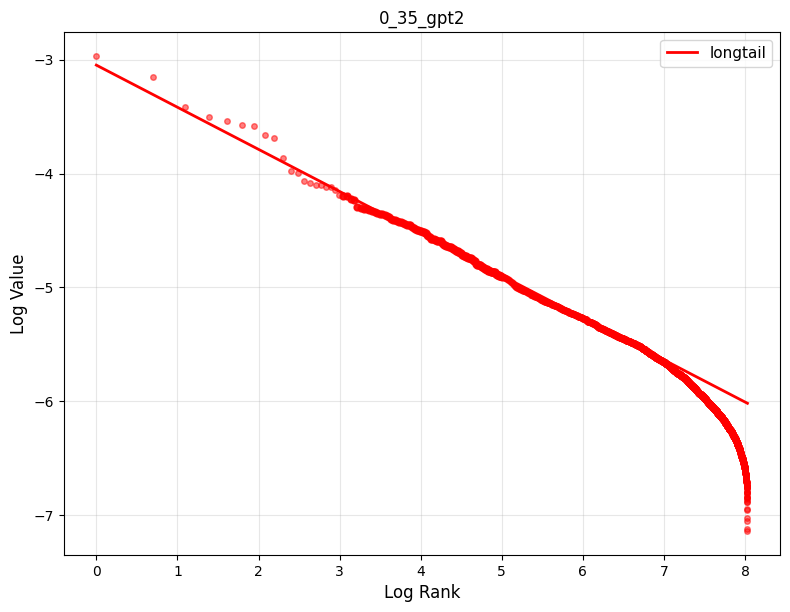

3072


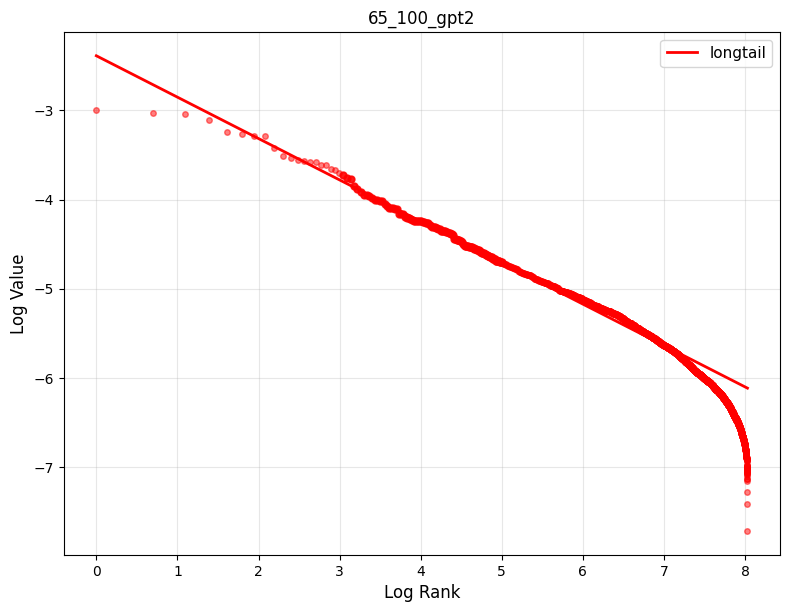

4096


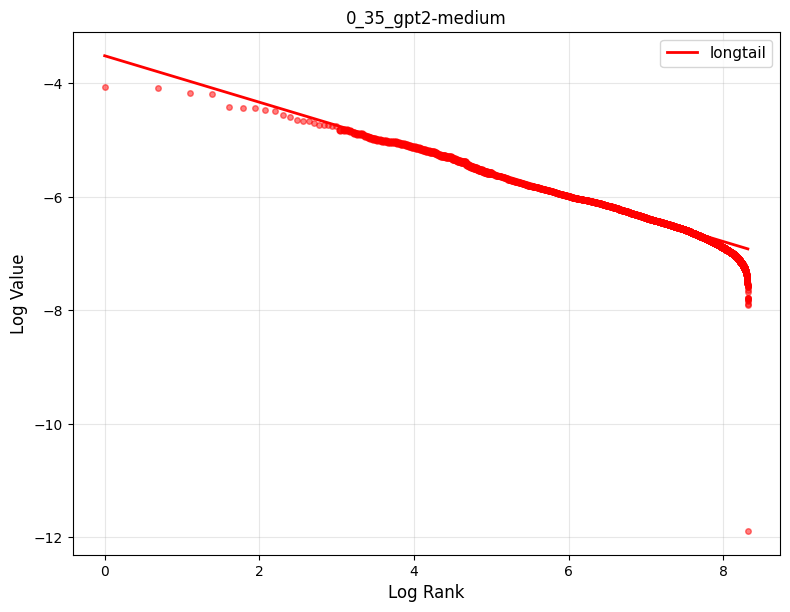

4096


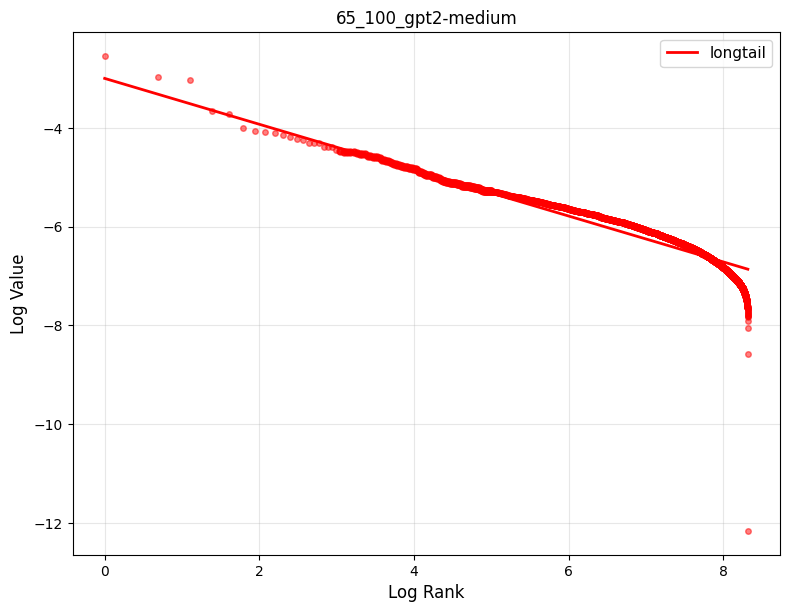

5120


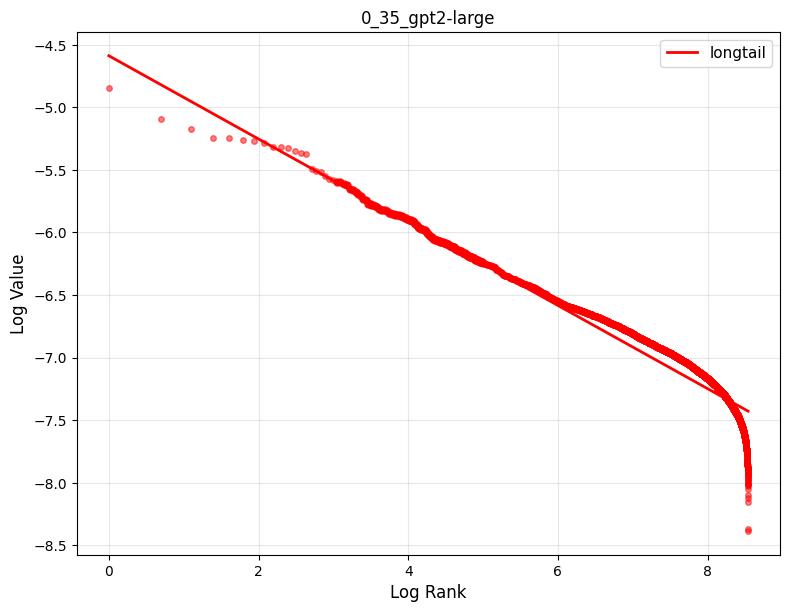

5120


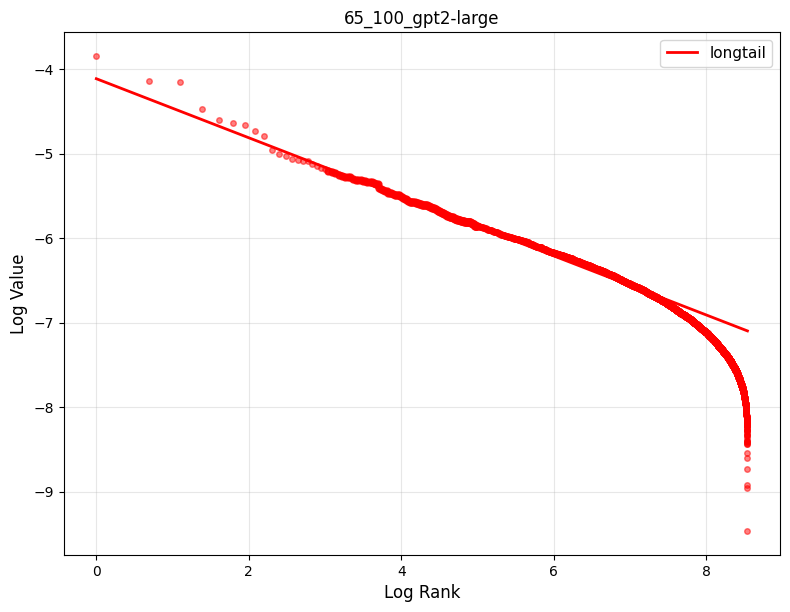

6400


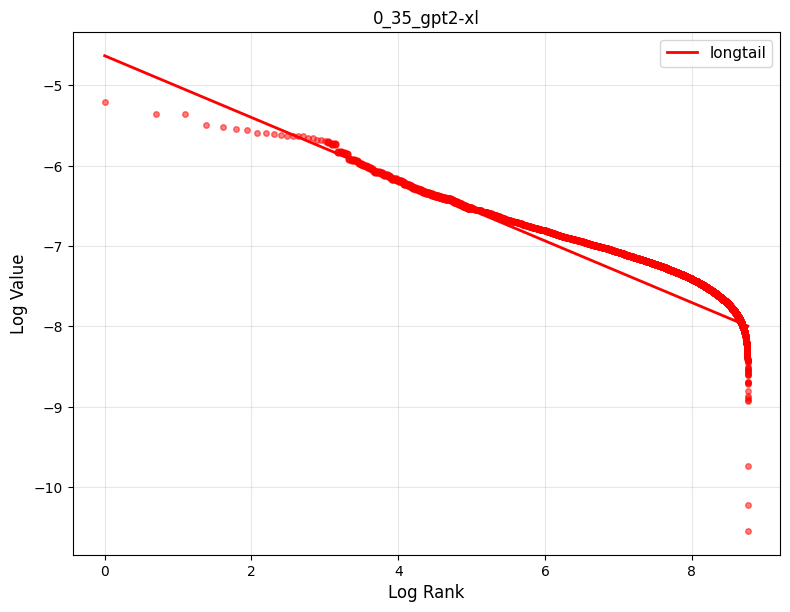

6400


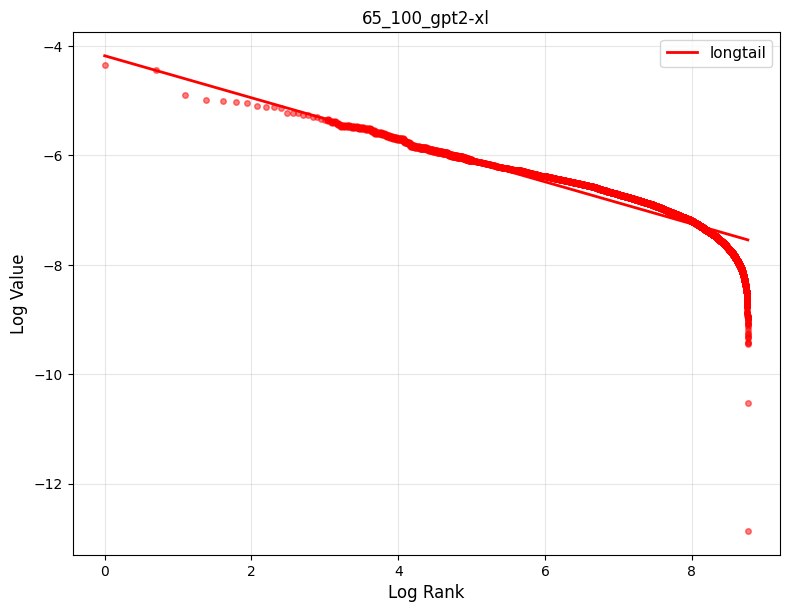

2048


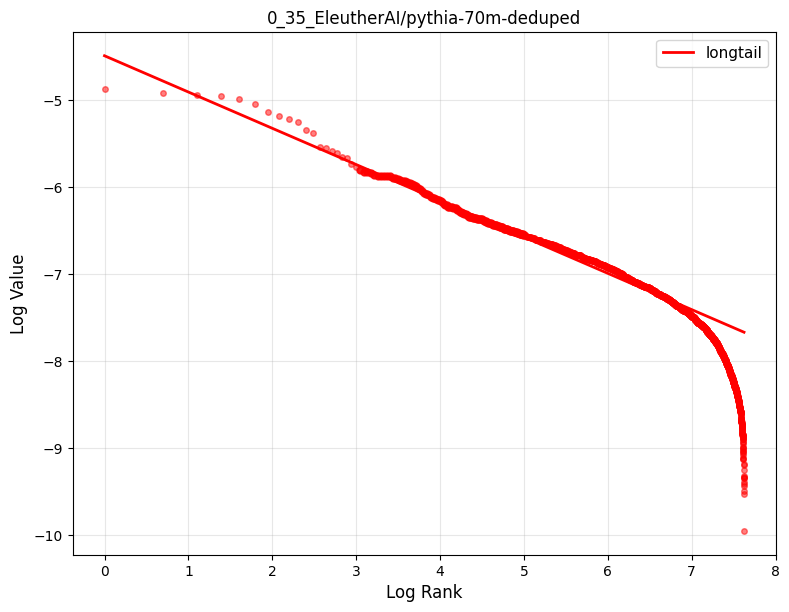

2048


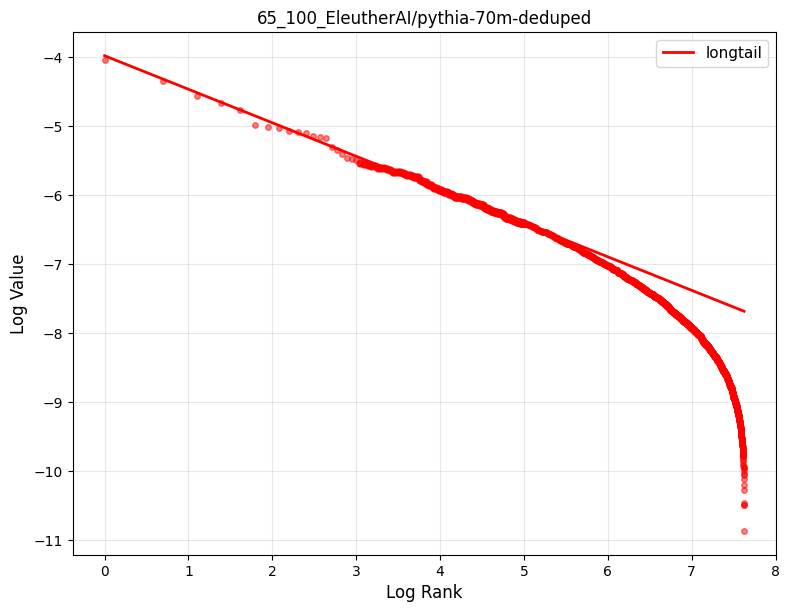

something wrong with 0
something wrong with 65
4096


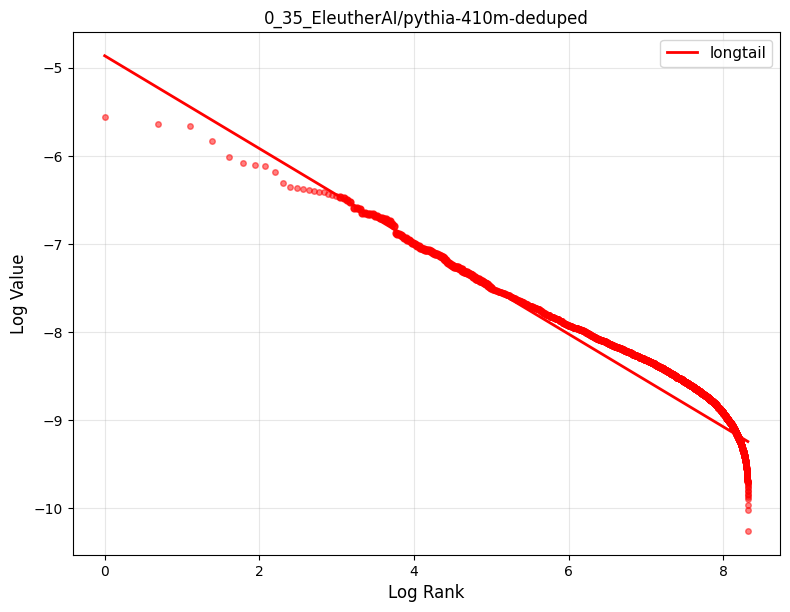

4096


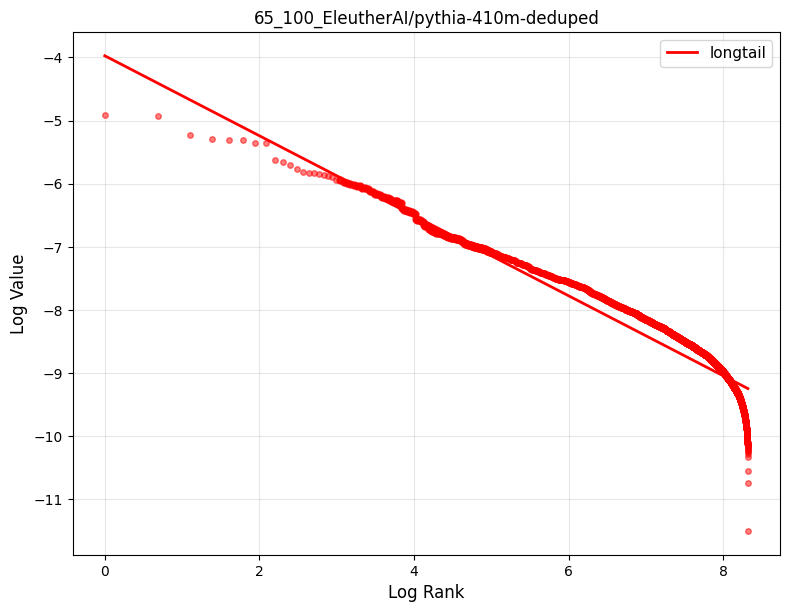

something wrong with 0
something wrong with 65
something wrong with 0
something wrong with 65
something wrong with 0
something wrong with 65
3072


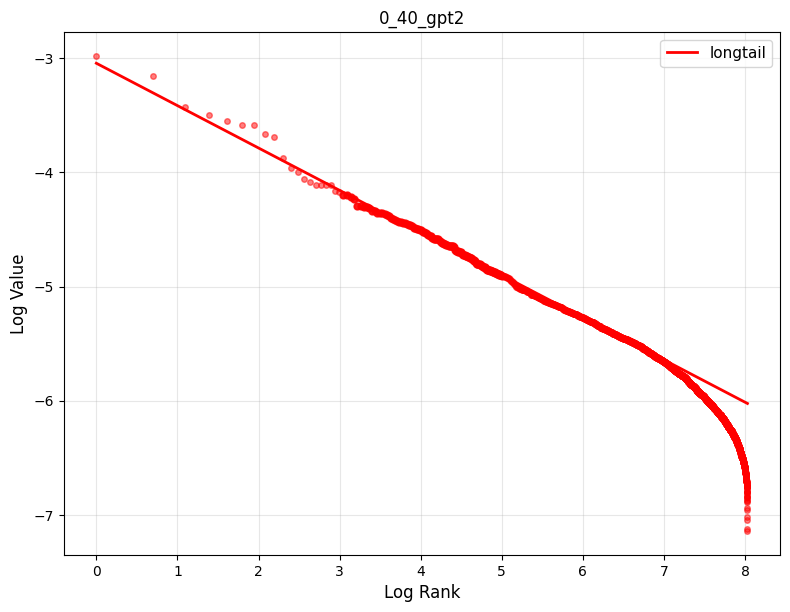

3072


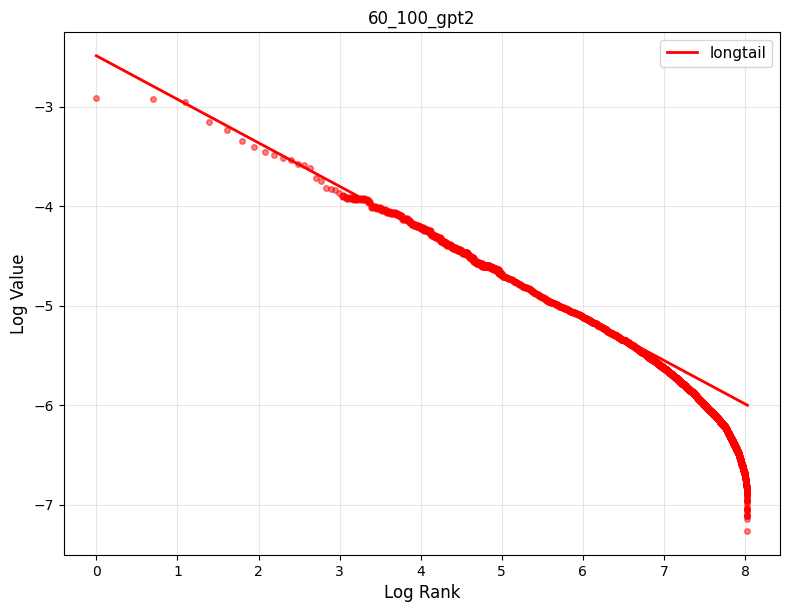

4096


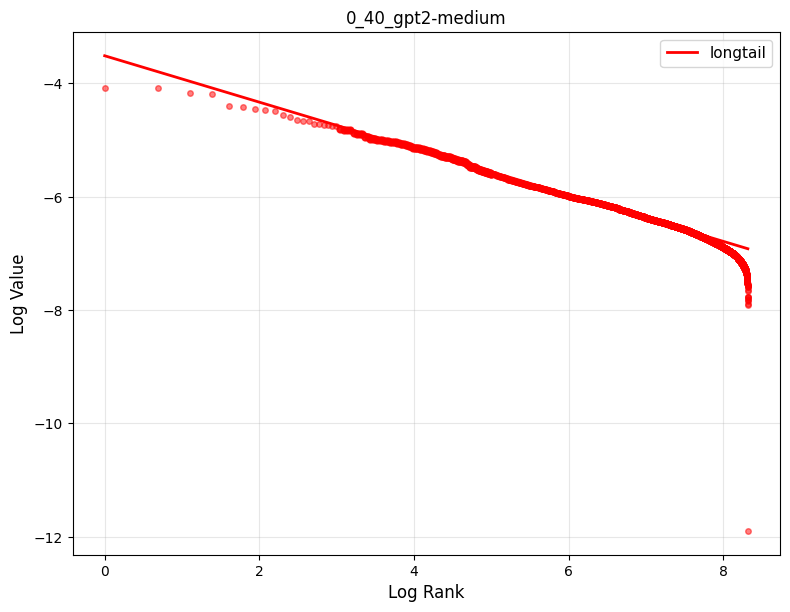

4096


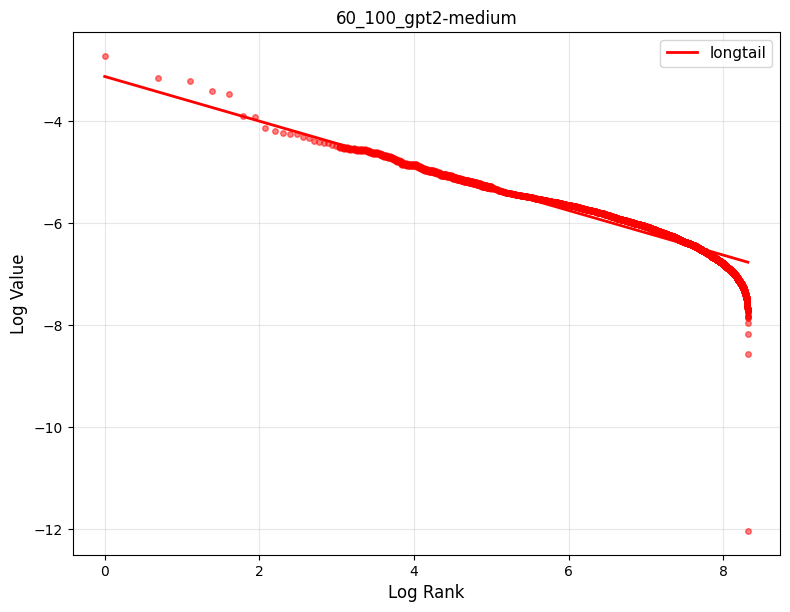

5120


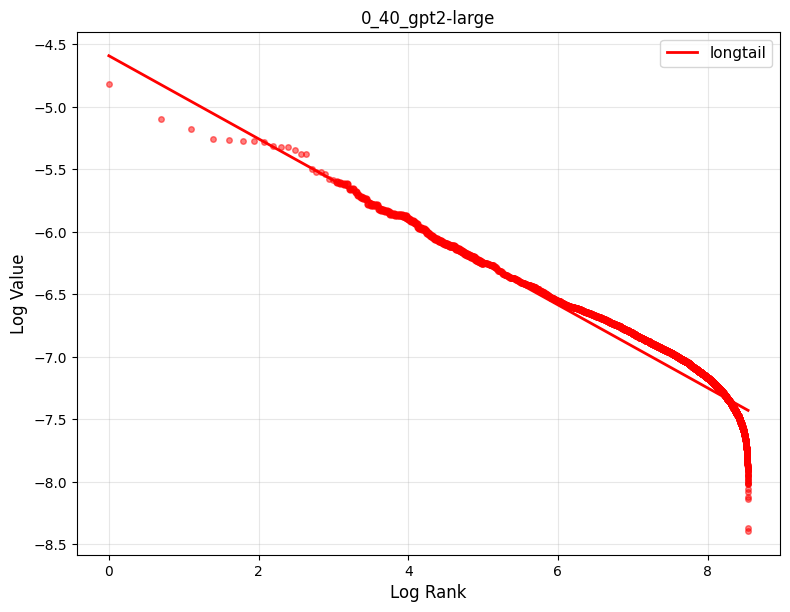

5120


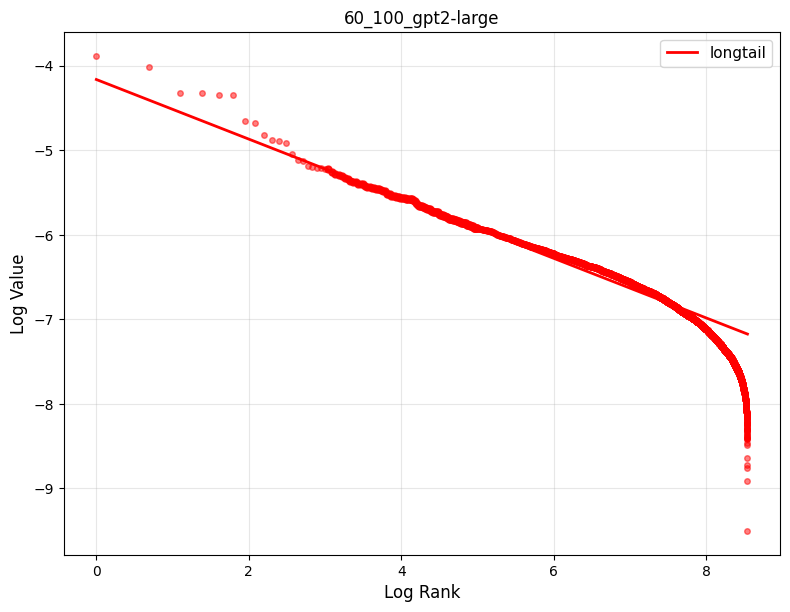

6400


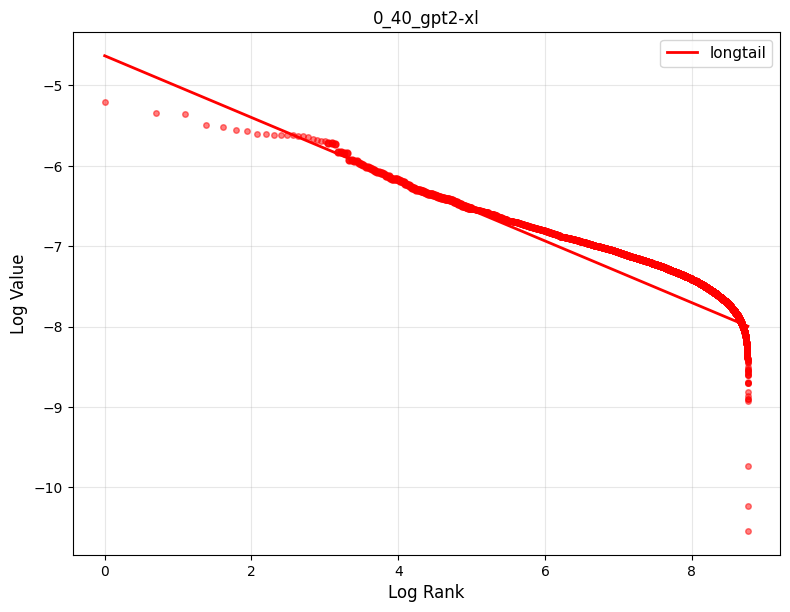

6400


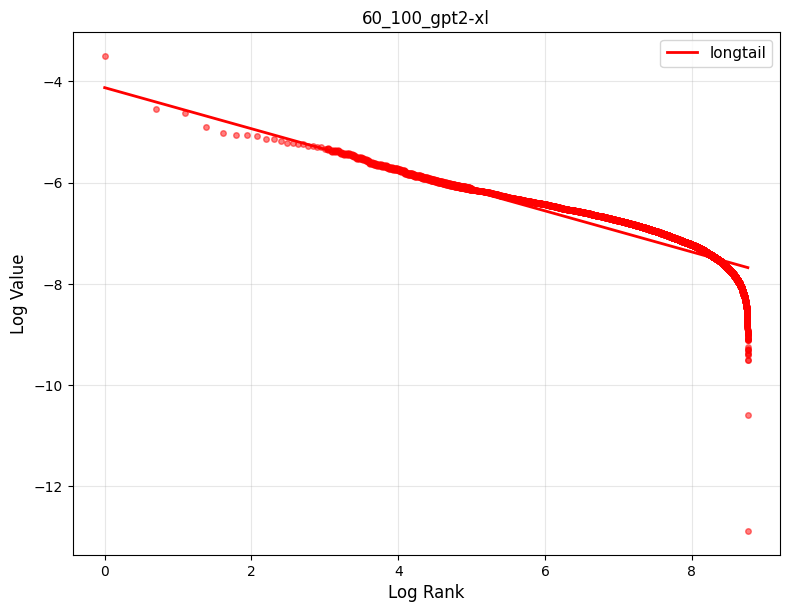

2048


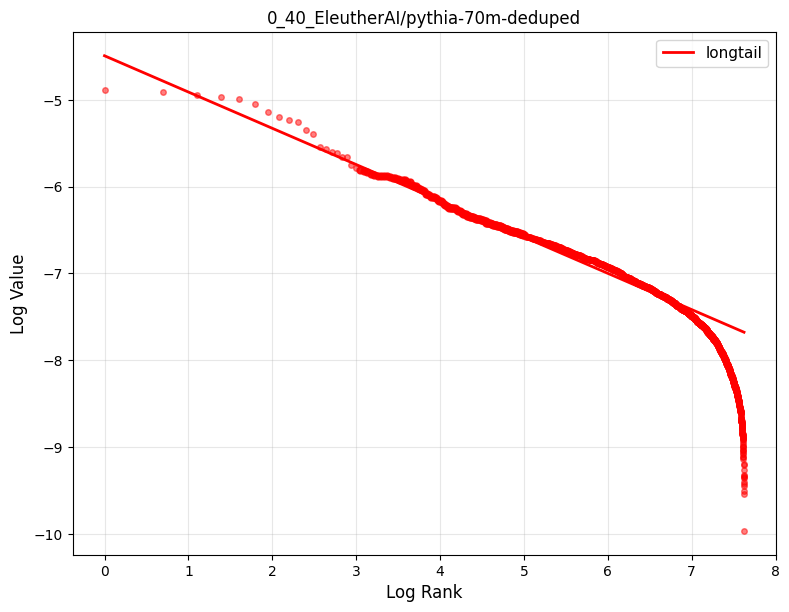

2048


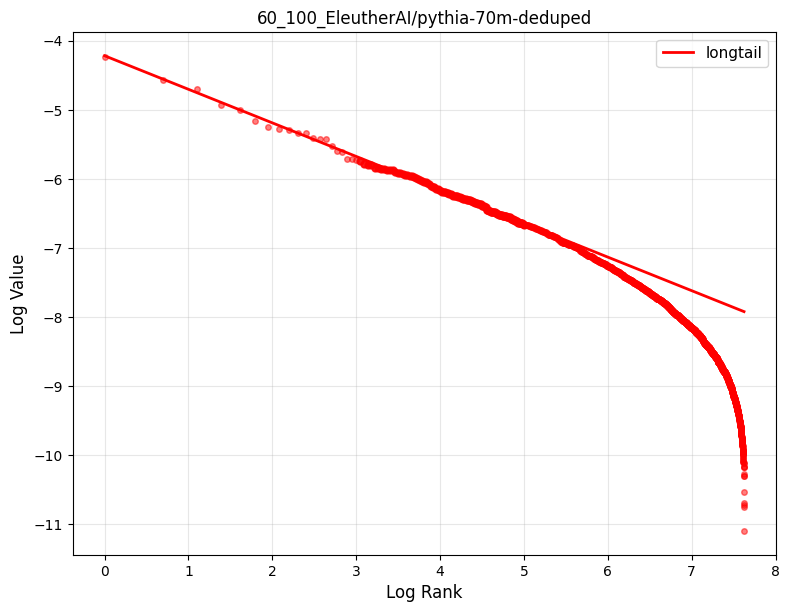

something wrong with 0
something wrong with 60
4096


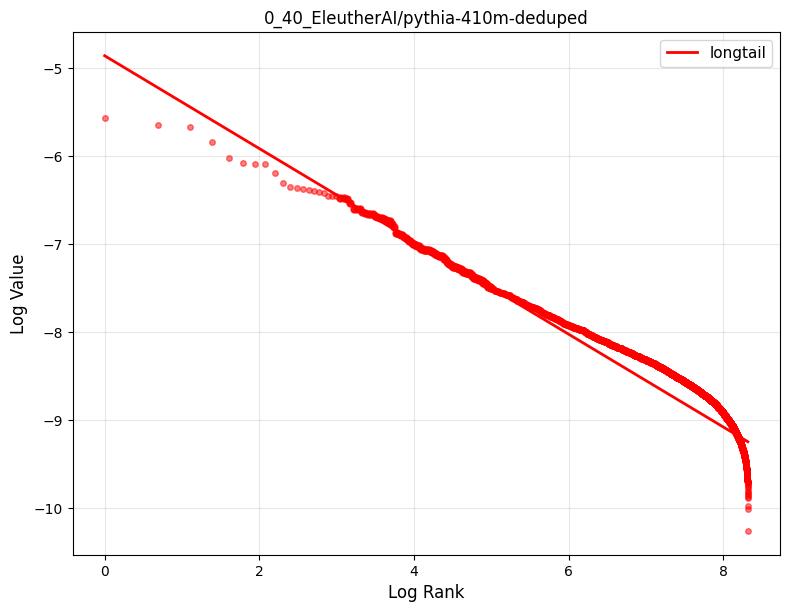

4096


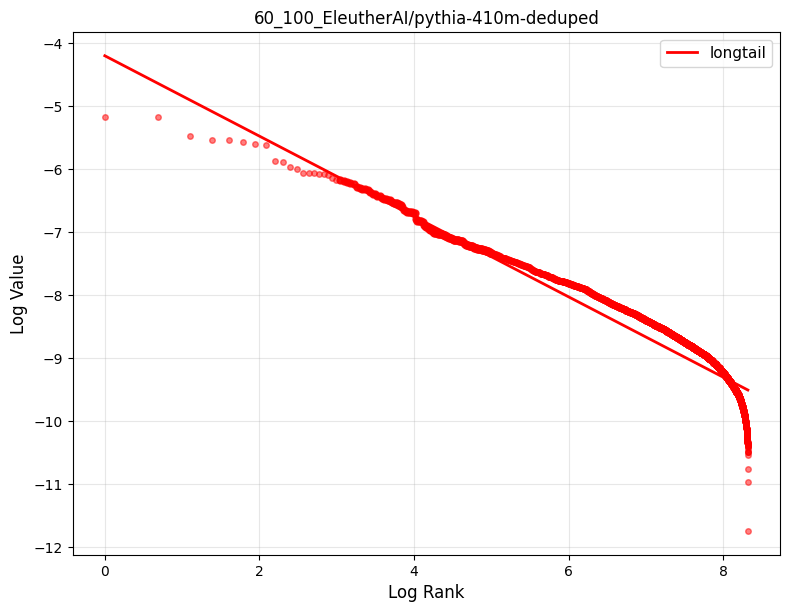

something wrong with 0
something wrong with 60
something wrong with 0
something wrong with 60
something wrong with 0
something wrong with 60
3072


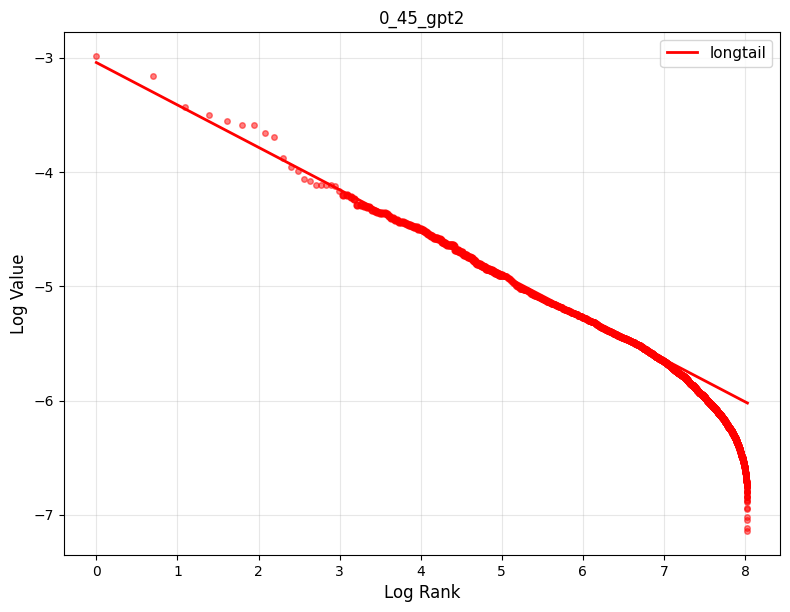

3072


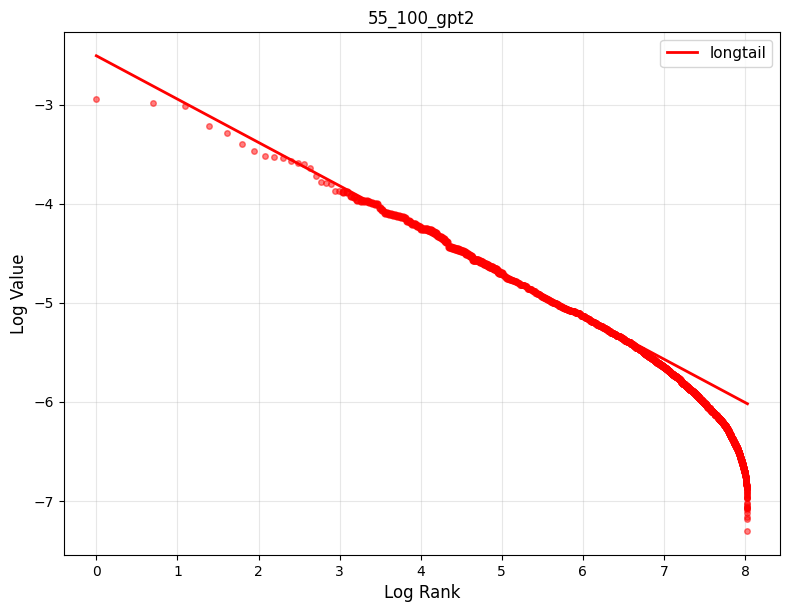

4096


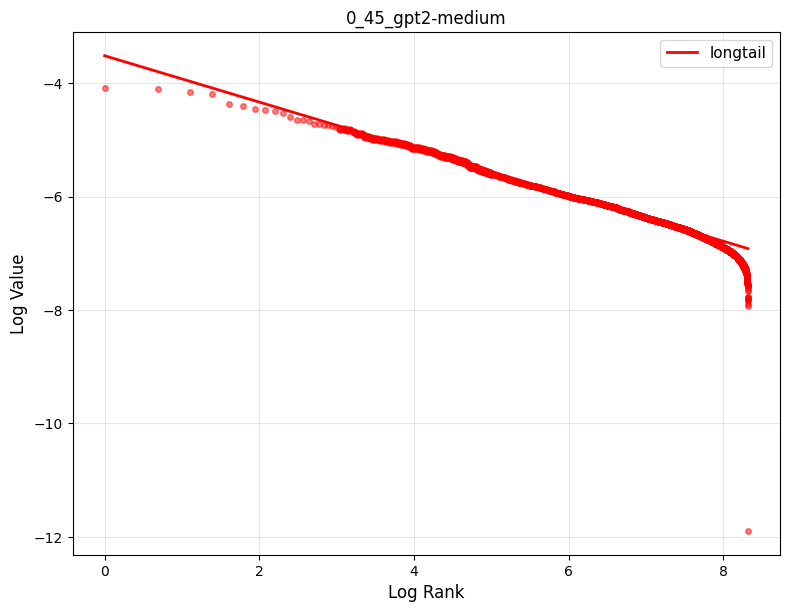

4096


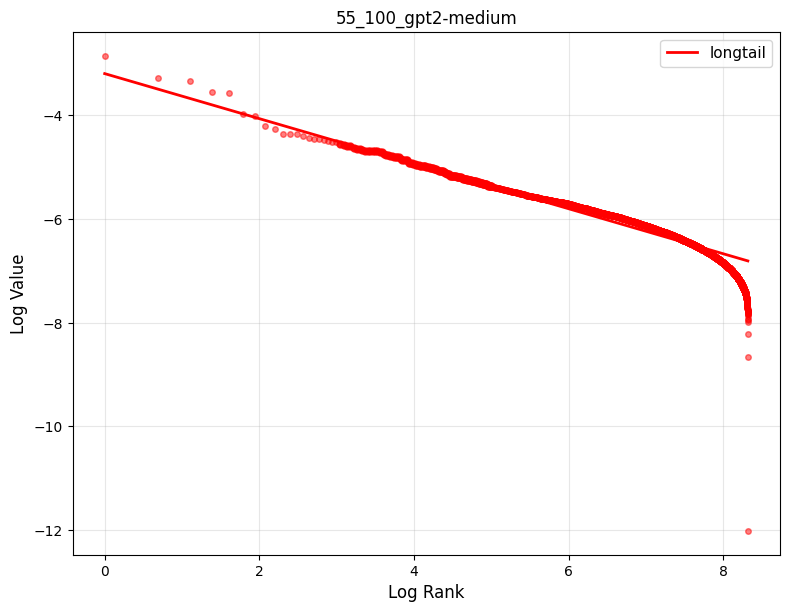

5120


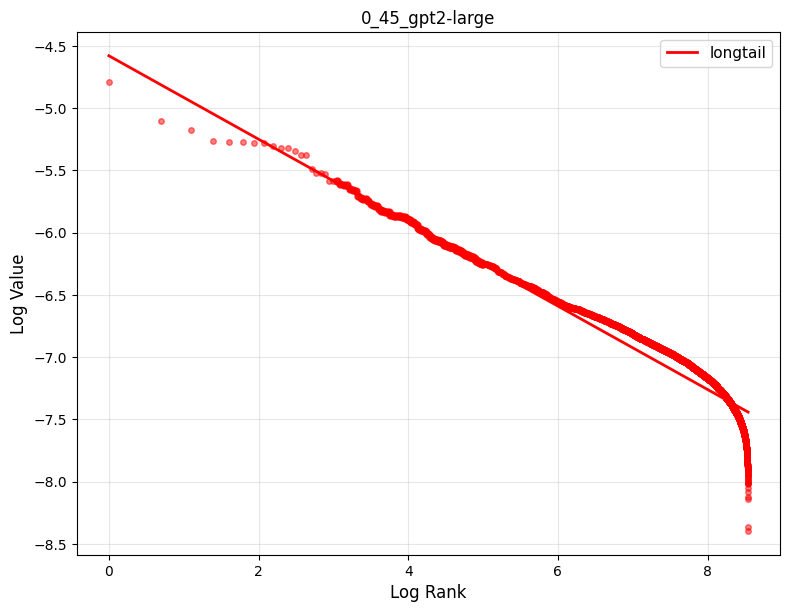

5120


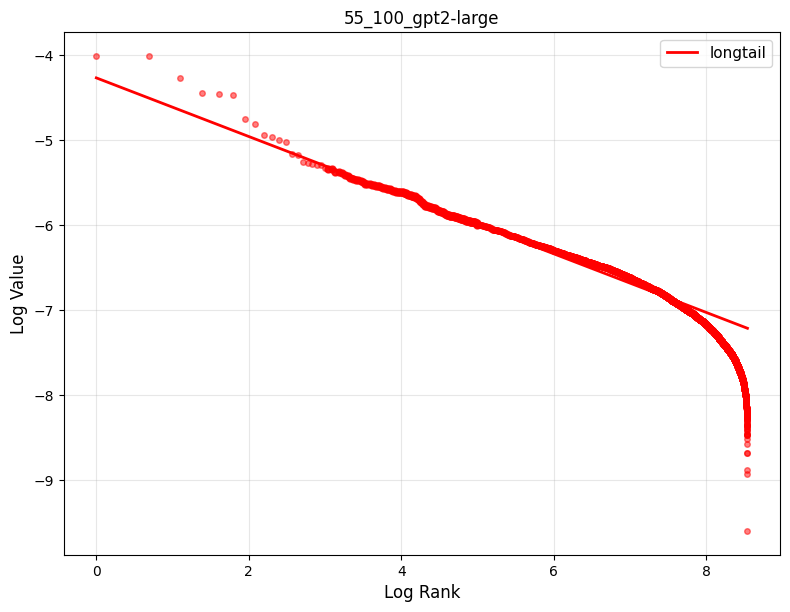

6400


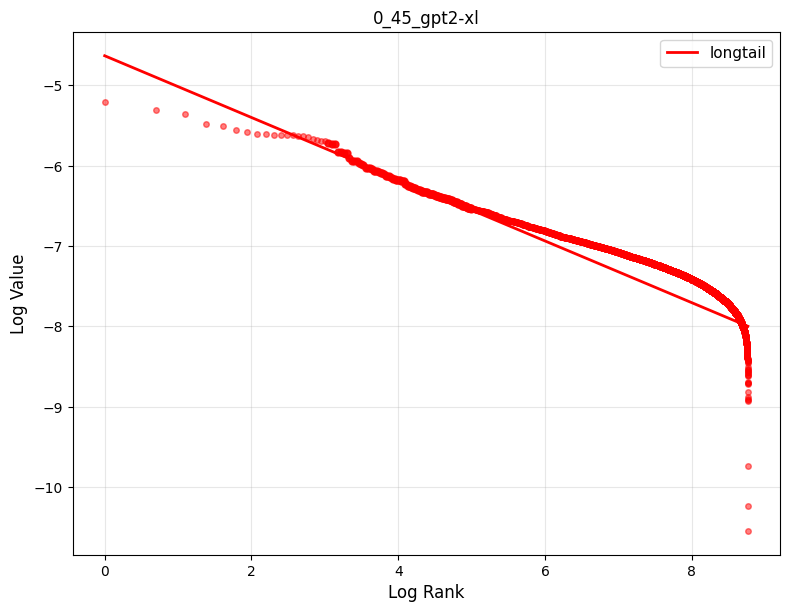

6400


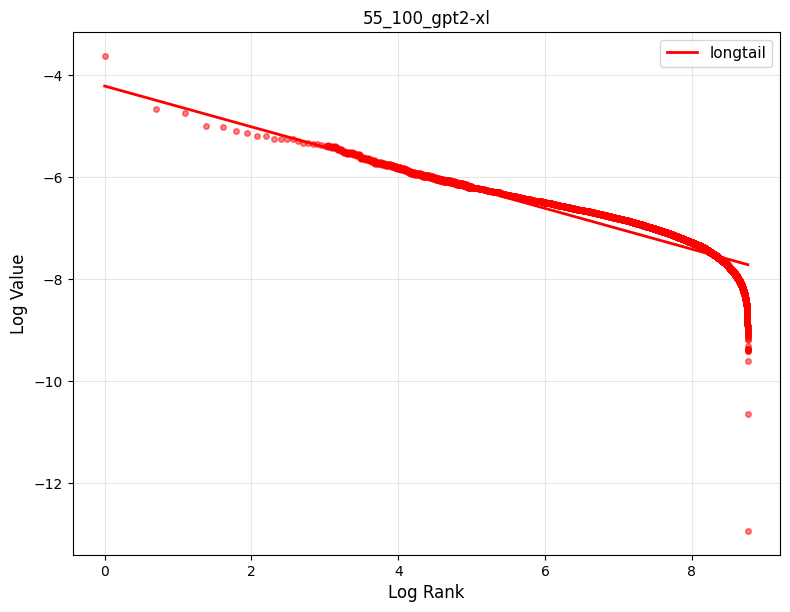

2048


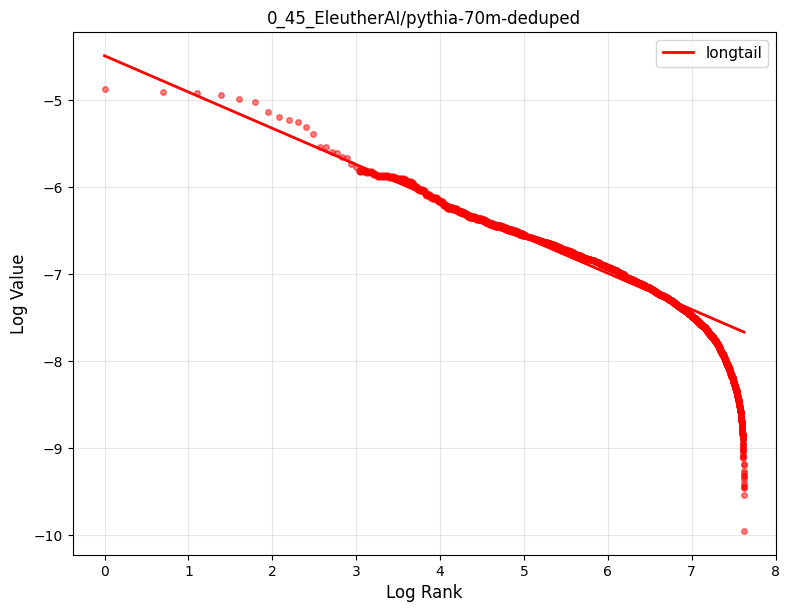

2048


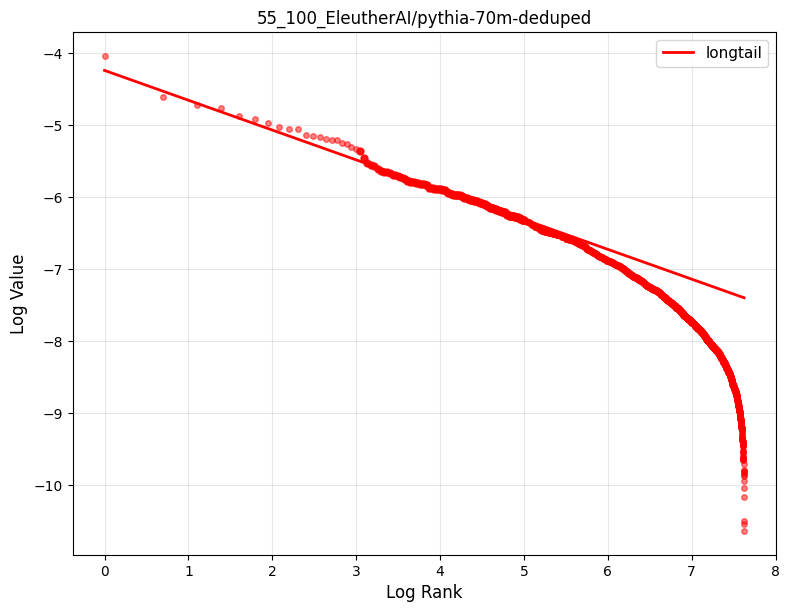

something wrong with 0
something wrong with 55
4096


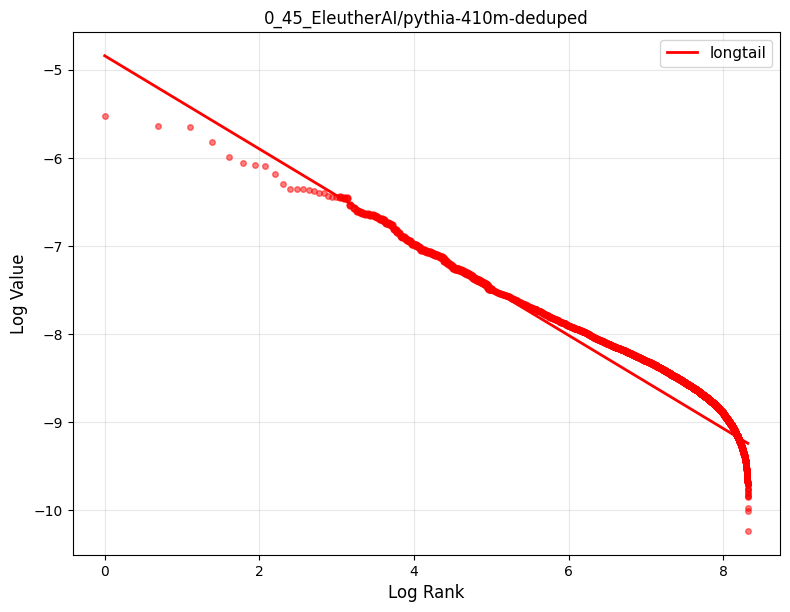

4096


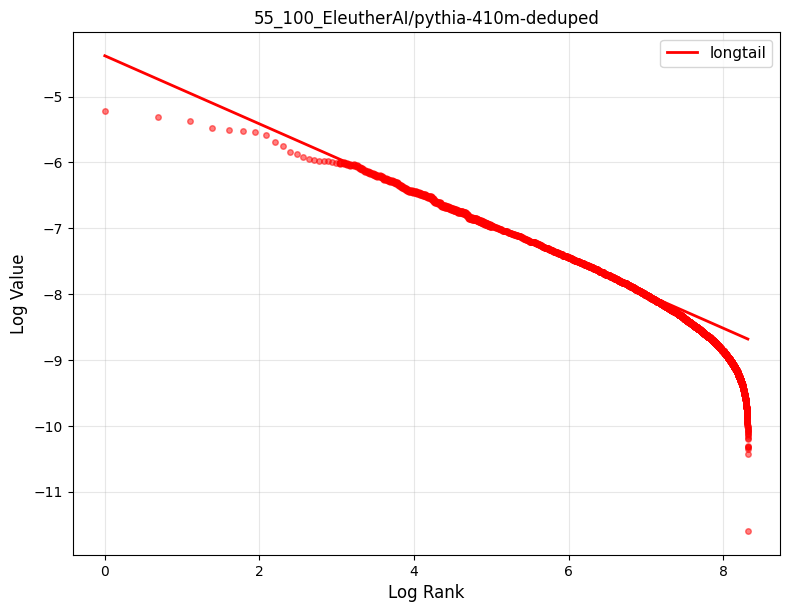

something wrong with 0
something wrong with 55
something wrong with 0
something wrong with 55
something wrong with 0
something wrong with 55
3072


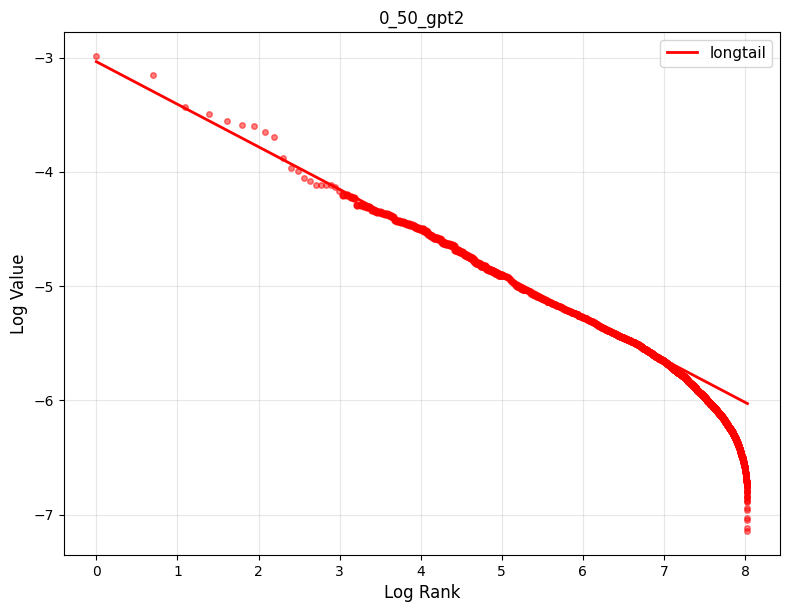

3072


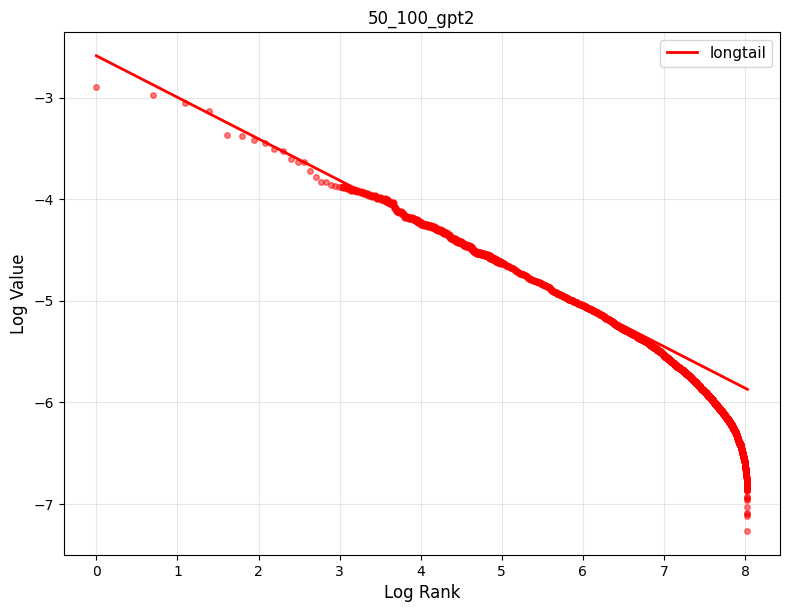

4096


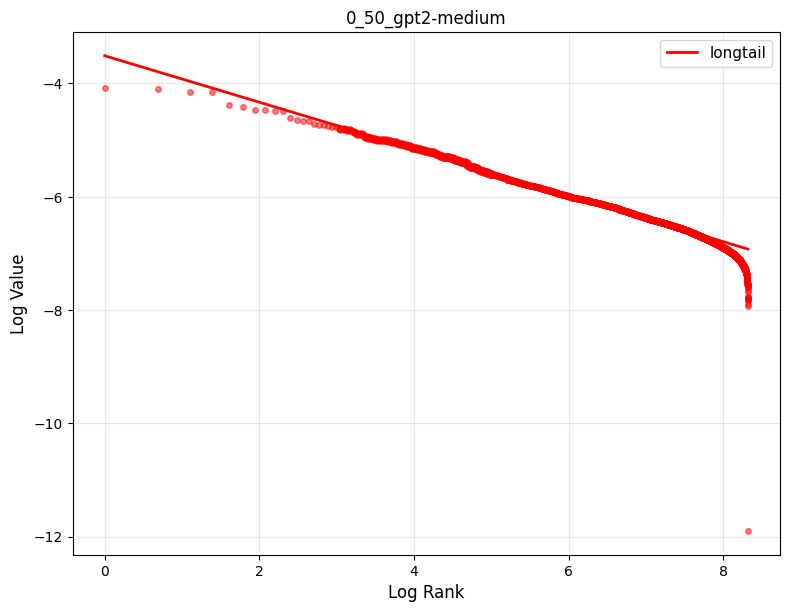

4096


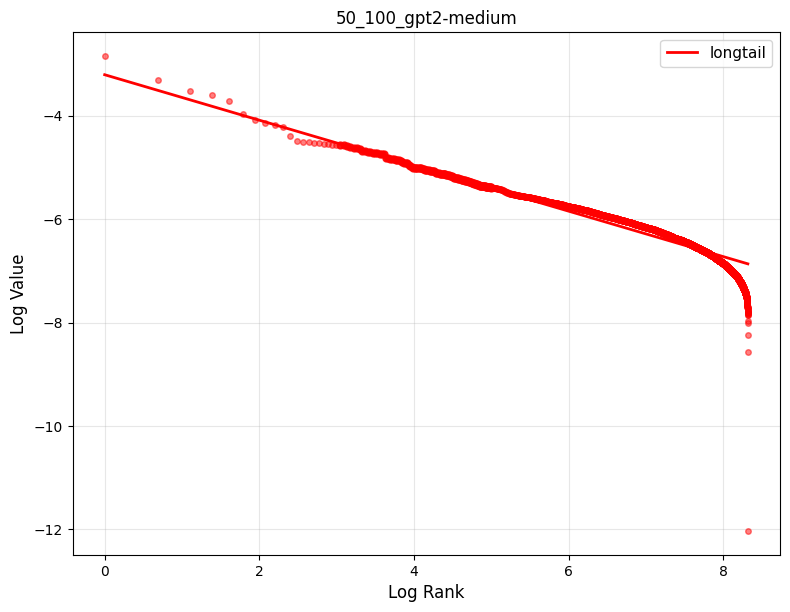

5120


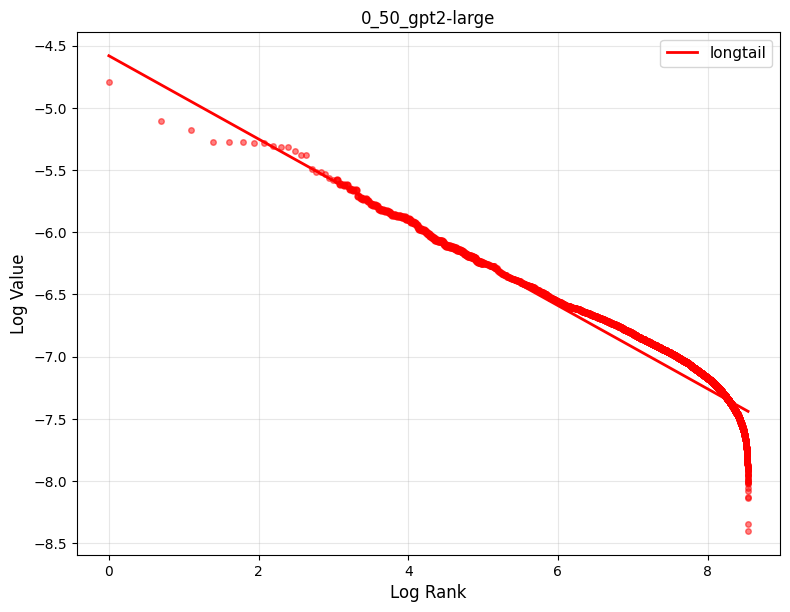

5120


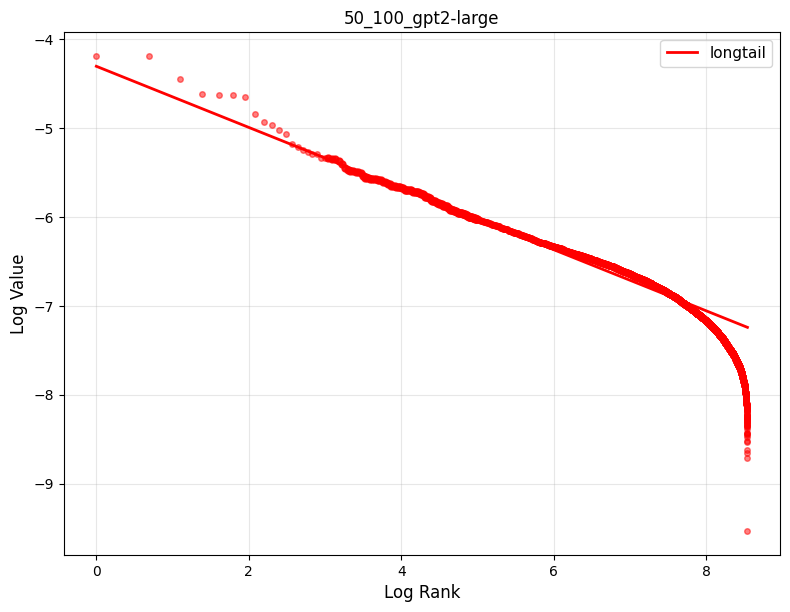

6400


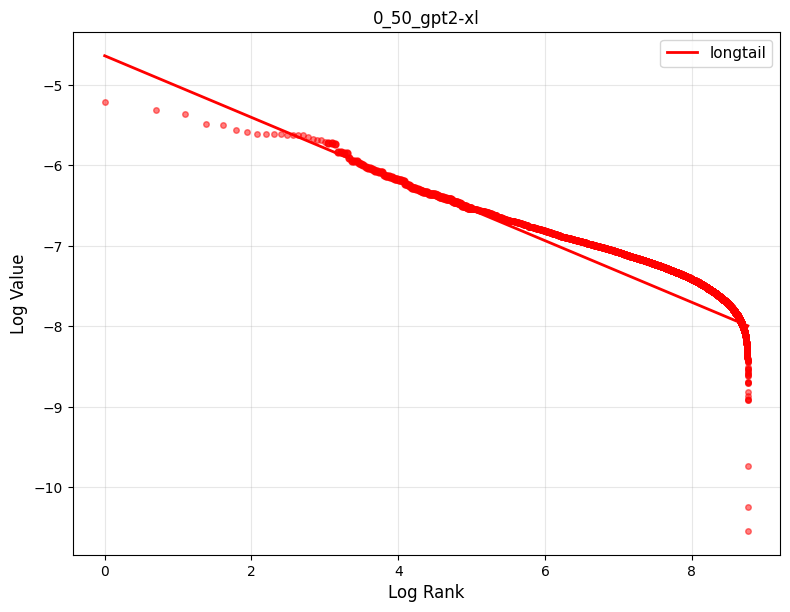

6400


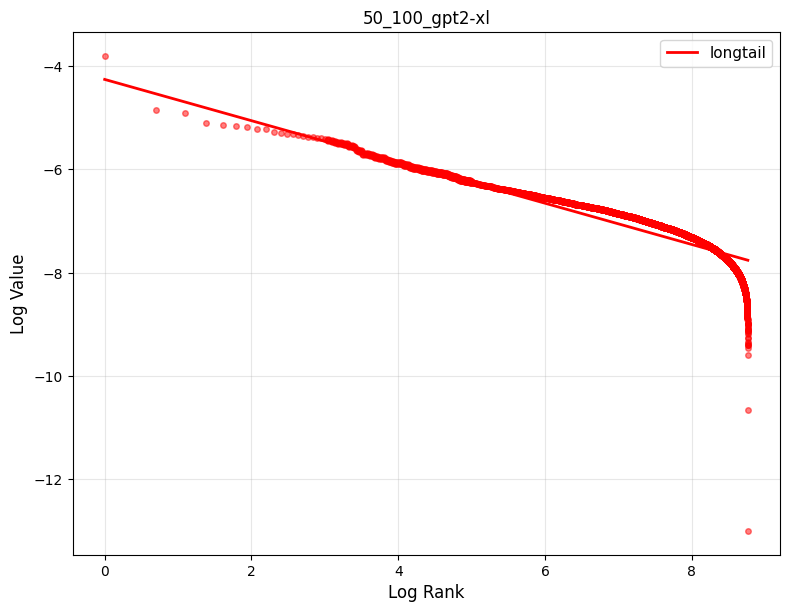

2048


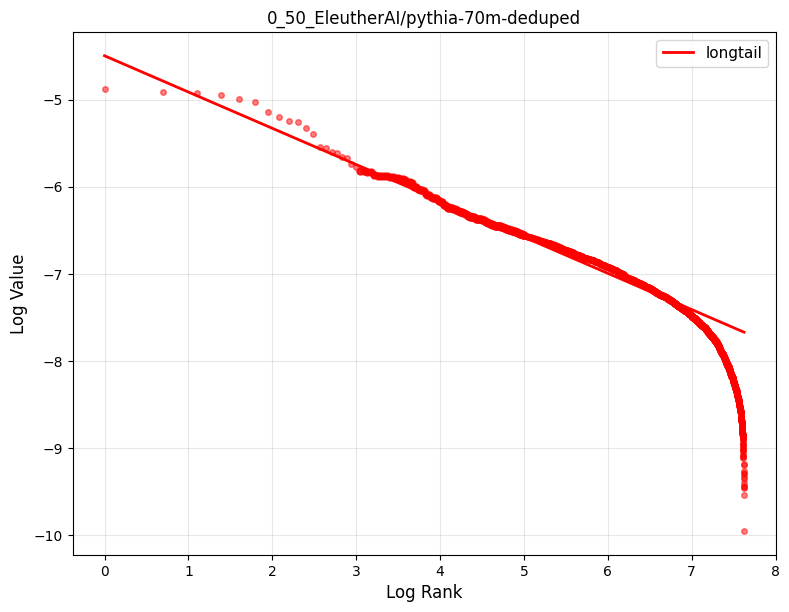

2048


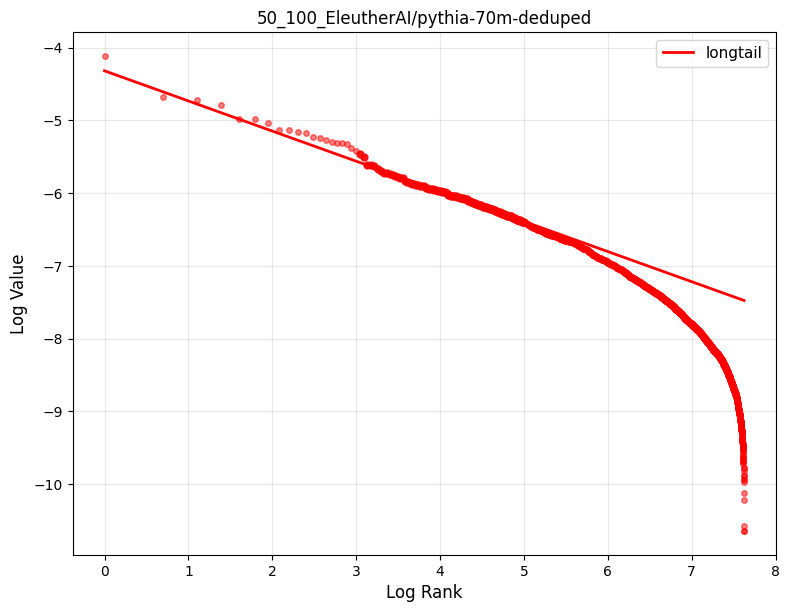

something wrong with 0
something wrong with 50
4096


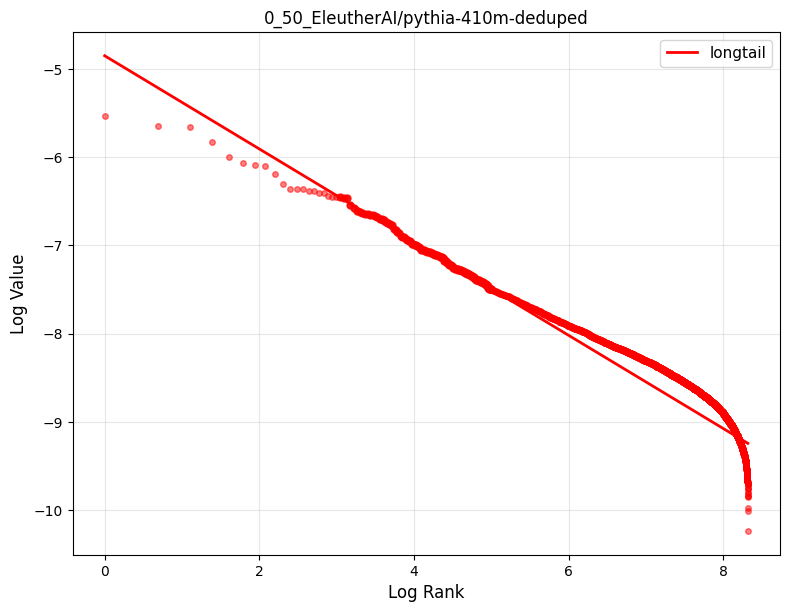

4096


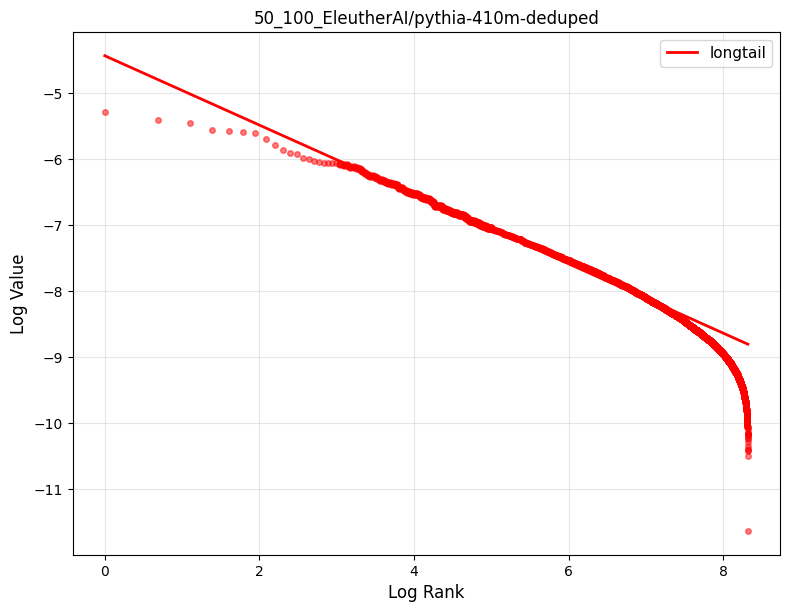

something wrong with 0
something wrong with 50
something wrong with 0
something wrong with 50
something wrong with 0
something wrong with 50


In [7]:
interval_lst = [5,10,15,20,25,30,35,40,45,50]

model_lst = [
    "gpt2",
    "gpt2-medium",
    "gpt2-large",
    "gpt2-xl",
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1B-deduped",
    "EleutherAI/pythia-1.4B-deduped",
    "EleutherAI/pythia-2.8B-deduped",
]

for interval in interval_lst:
    for model in model_lst:
        try:
            plot_all(interval,model,y_col = "abs_delta_loss_post_ablation",linear_region=(3, 5))
        except:
            print(f"Have not got results of {interval}: {model}")



3227


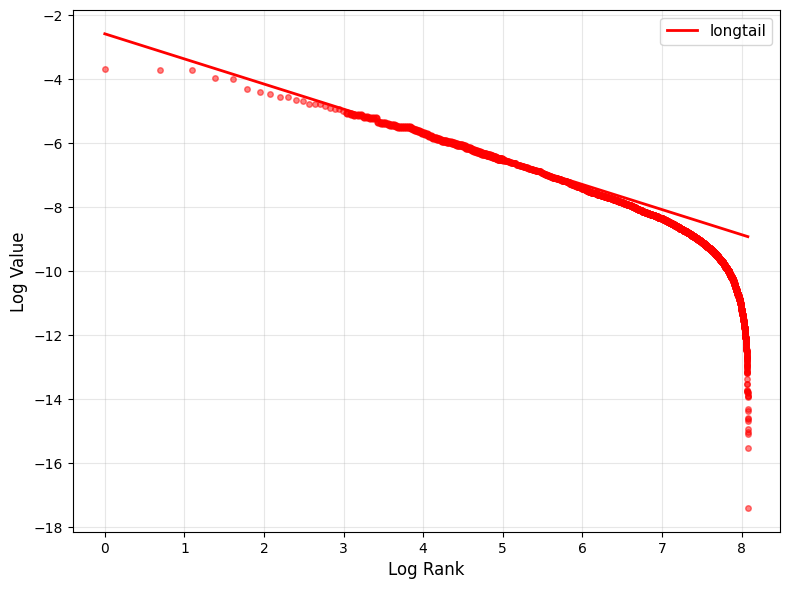

In [ ]:
min_pct = 90
max_pct = 100
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3241


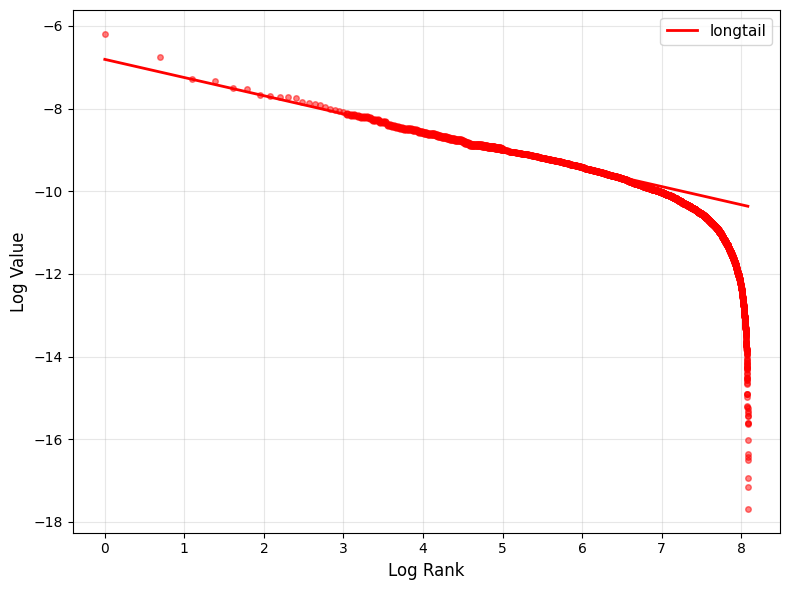

In [6]:
min_pct = 0
max_pct = 10
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3247


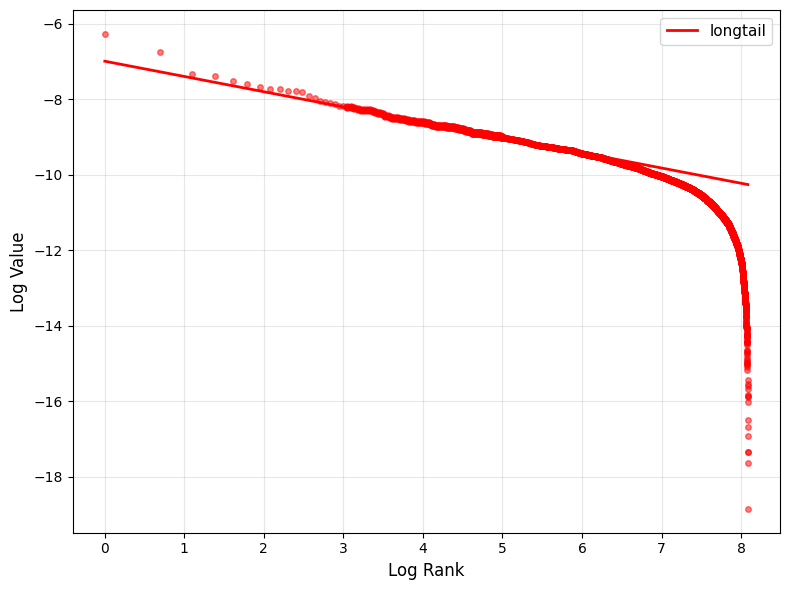

In [7]:
min_pct = 0
max_pct = 15
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3209


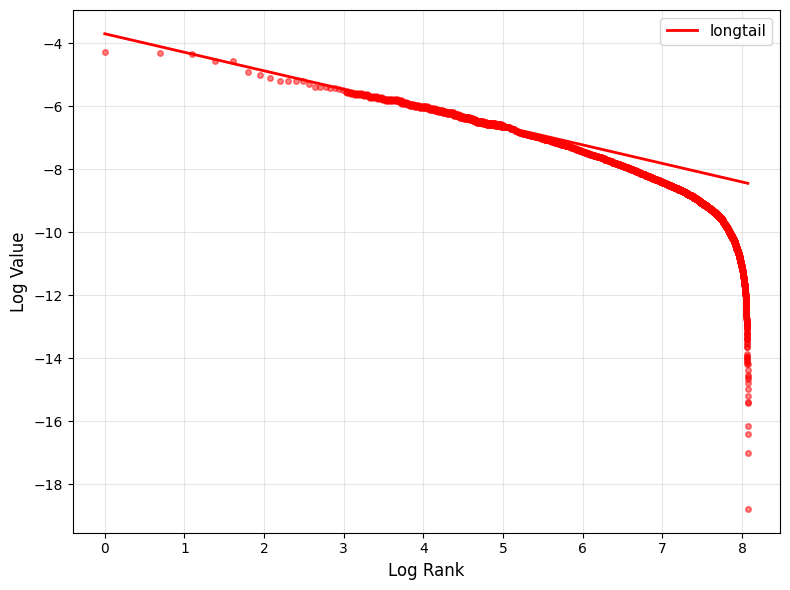

In [11]:
min_pct = 85
max_pct = 100
model = "gpt2-xl"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


1899


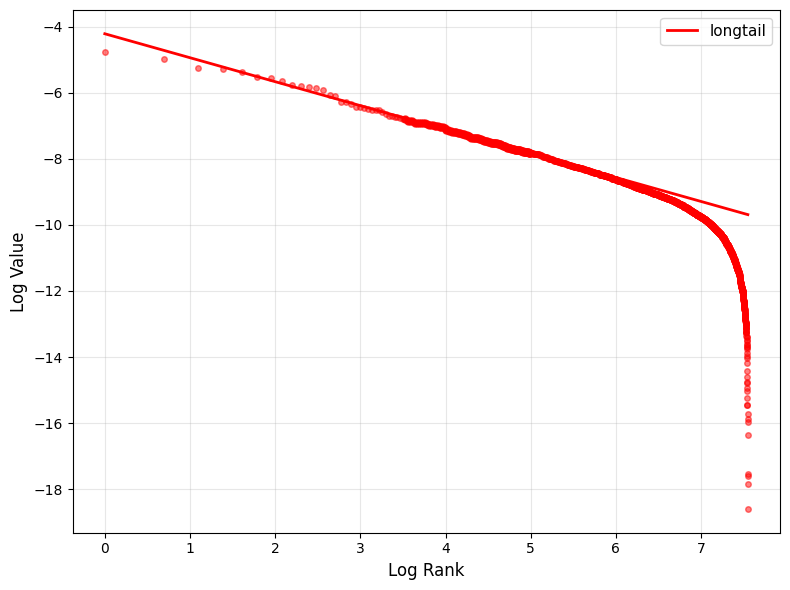

In [14]:
min_pct = 0
max_pct = 10
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3.5, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


4550


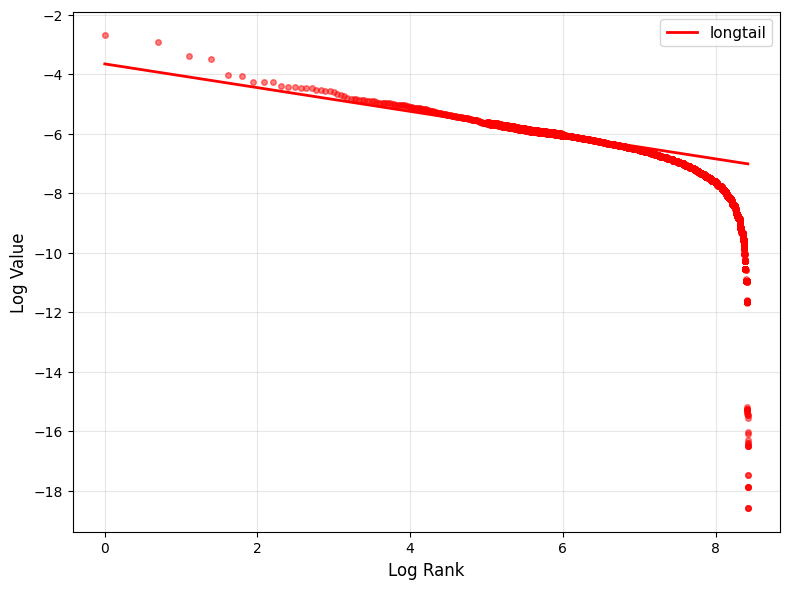

In [17]:
min_pct = 90
max_pct = 100
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(5, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


1751


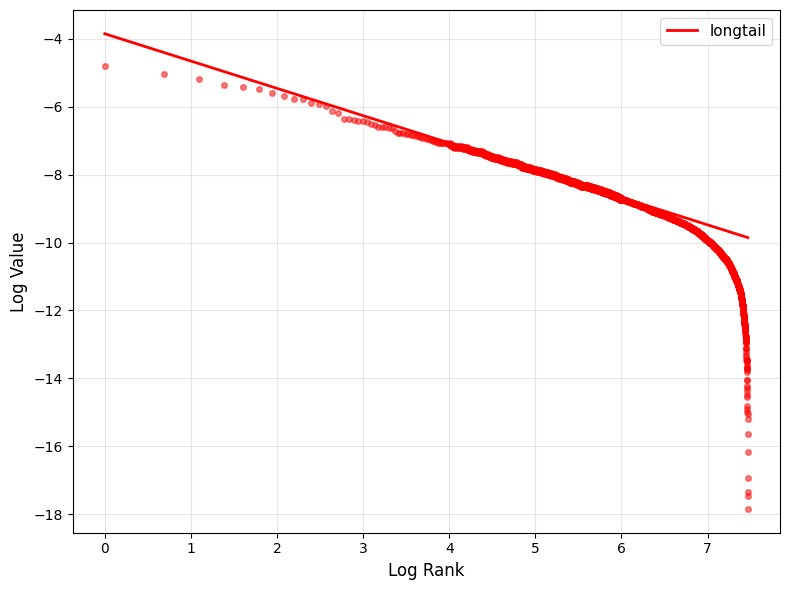

In [21]:
min_pct = 0
max_pct = 15
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


3203


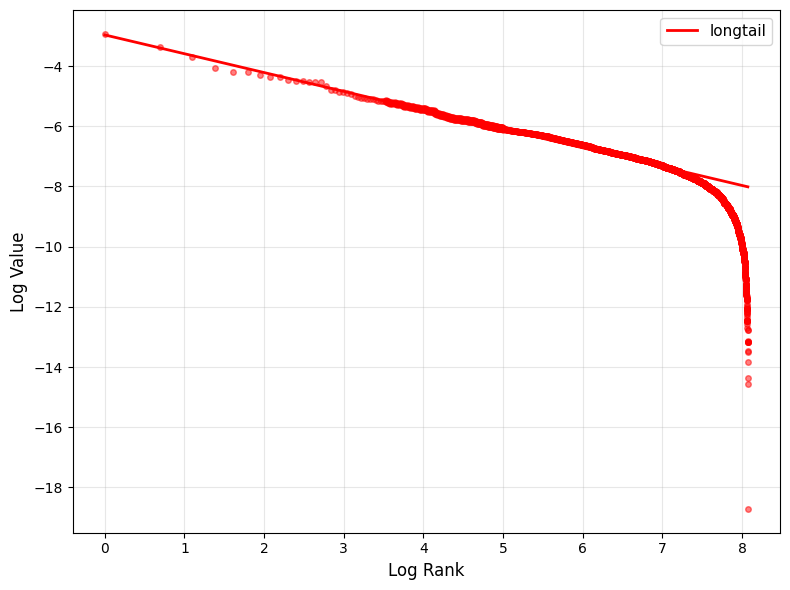

In [22]:
min_pct = 85
max_pct = 100
model = "EleutherAI/pythia-1B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(3.5, 5)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


4001


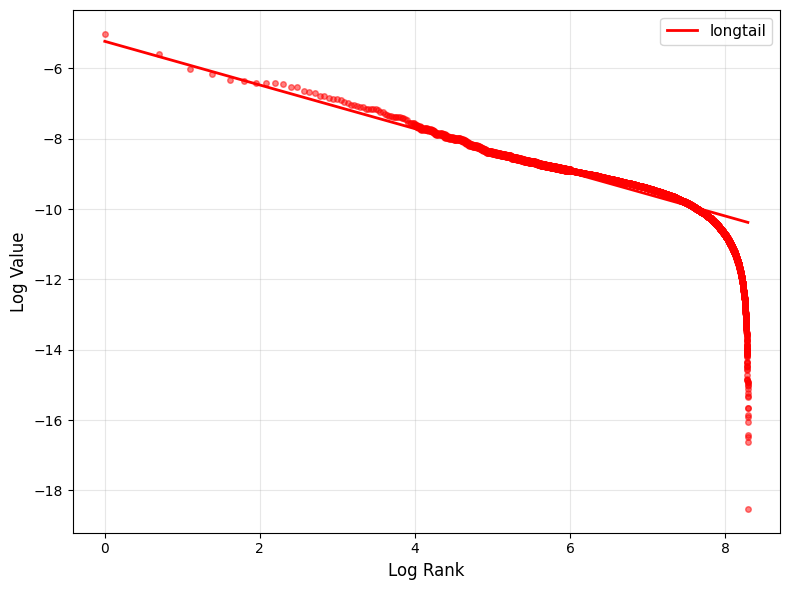

In [24]:
min_pct = 0
max_pct = 10
model = "EleutherAI/pythia-2.8B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


6935


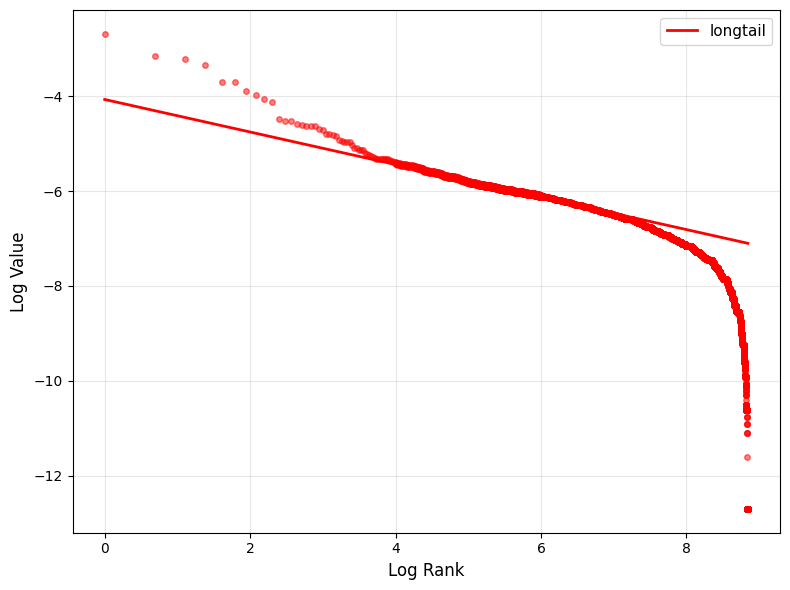

In [25]:
min_pct = 90
max_pct = 100
model = "EleutherAI/pythia-2.8B-deduped"

file_path = (ROOT_dir/f"{min_pct}_{max_pct}/{model}/prob/boost/500_all.csv")
y_col = "delta_loss_post"
linear_region=(4, 6)

log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail = load_data(file_path,y_col=y_col,linear_region=linear_region)
print(len(log_vals_longtail))
plt.figure(figsize=(8, 6))

# Longtail_50 — use red
plot_zipf_distribution(
    log_ranks_longtail, log_vals_longtail, zipf_line_longtail, coeffs_longtail,
    label="longtail", color="red", linear_region=linear_region
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
